# Functions

In [19]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig
from scipy import signal
from sklearn.utils import resample

# Include all the helper functions from before
def apply_lowpass_filter(data: np.ndarray, 
                        fs: float, 
                        cutoff: float = 8.0,
                        order: int = 4) -> np.ndarray:
    """Apply zero-lag Butterworth low-pass filter to data."""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    
    filtered_data = np.zeros_like(data)
    for ax in range(data.shape[1]):
        filtered_data[:, ax] = signal.filtfilt(b, a, data[:, ax])
    
    return filtered_data


def compute_floquet_from_events(com_da: xr.DataArray,
                                events_df: pd.DataFrame,
                                channel: str = "COM",
                                axes: list = ["x", "y", "z"],
                                normalization_points: int = 101,
                                rcond: float = 1e-6,
                                phase_dependent: bool = False,
                                plot_spectrum: bool = False,
                                use_same_side: bool = True,
                                force_side: str = None,
                                trim_cycles: int = 5,
                                bootstrap_n: int = 100,
                                bootstrap_ci: float = 95.0,
                                lowpass_cutoff: float = 8.0,
                                min_cycles_required: int = 150,
                                return_all_eigenvalues: bool = False) -> dict:
    """
    Compute Floquet multipliers with optional forced side selection.
    
    Additional Parameters:
    ---------------------
    force_side : str or None
        If provided ('Left' or 'Right'), forces analysis of that specific side
    return_all_eigenvalues : bool
        If True, returns all eigenvalues, not just the maximum
    """
    # Extract all Foot Strike times & contexts
    df_fs = events_df[events_df['label'] == 'Foot Strike'].copy()
    df_fs = df_fs[['time','context']].sort_values('time')
    strike_times = df_fs['time'].values
    strike_context = df_fs['context'].values
    
    # Determine which strikes to use based on same-side setting
    if use_same_side:
        left_indices = np.where(strike_context == 'Left')[0]
        right_indices = np.where(strike_context == 'Right')[0]
        
        if force_side is not None:
            # Use the forced side
            side_used = force_side
            use_indices = left_indices if force_side == 'Left' else right_indices
        else:
            # Auto-select the side with more strikes
            if len(left_indices) >= len(right_indices):
                use_indices = left_indices
                side_used = 'Left'
            else:
                use_indices = right_indices
                side_used = 'Right'
        
        # Create stride segments from same-side strikes
        stride_starts = use_indices[:-1]
        stride_ends = use_indices[1:]
        print(f"Using {side_used}-to-{side_used} strides: {len(stride_starts)} strides")
    else:
        # Use all consecutive strikes (original behavior)
        stride_starts = np.arange(len(strike_times) - 1)
        stride_ends = stride_starts + 1
        print(f"Using all consecutive strikes: {len(stride_starts)} strides")
    
    # Build raw segments
    raw_segs = []
    raw_ts = []
    raw_contexts = []
    
    for i, (start_idx, end_idx) in enumerate(zip(stride_starts, stride_ends)):
        t0 = strike_times[start_idx]
        t1 = strike_times[end_idx]
        
        seg = (com_da
               .sel(channel=channel, axis=axes)
               .sel(time=slice(t0, t1))
               .transpose('time', 'axis'))
        t = seg.time.values
        
        if t.size < 10:  # Skip very short segments
            continue
            
        raw_segs.append(seg.values)
        raw_ts.append(t)
        raw_contexts.append(strike_context[start_idx])
    
    n_cycles = len(raw_segs)
    n_axes = len(axes)
    state_dim = 2 * n_axes
    
    # Check if we have enough cycles
    if n_cycles < min_cycles_required:
        print(f"WARNING: Only {n_cycles} cycles available, recommended minimum is {min_cycles_required}")
    
    if n_cycles < state_dim + 1 + 2*trim_cycles:
        raise ValueError(f"Need ≥{state_dim + 1 + 2*trim_cycles} valid strides, got {n_cycles}")
    
    # Apply low-pass filter to each segment before normalization
    filtered_segs = []
    for i, (seg_vals, t) in enumerate(zip(raw_segs, raw_ts)):
        fs = 1.0 / np.mean(np.diff(t))
        filtered_seg = apply_lowpass_filter(seg_vals, fs, lowpass_cutoff)
        filtered_segs.append(filtered_seg)
    
    # Time-normalize each cycle
    M = normalization_points
    norm_t = np.linspace(0, 1, M)
    com_norm = np.zeros((n_cycles, M, n_axes), dtype=float)
    
    for i, (seg_vals, t) in enumerate(zip(filtered_segs, raw_ts)):
        t_norm = (t - t[0]) / (t[-1] - t[0])
        for ax in range(n_axes):
            com_norm[i, :, ax] = np.interp(norm_t, t_norm, seg_vals[:, ax])
    
    dt = 1.0 / (M - 1)
    
    # Trim first and last cycles
    if trim_cycles > 0:
        com_norm = com_norm[trim_cycles:-trim_cycles]
        raw_contexts = raw_contexts[trim_cycles:-trim_cycles]
        n_cycles_trimmed = n_cycles - 2*trim_cycles
        print(f"Trimmed {trim_cycles} cycles from start/end, using {n_cycles_trimmed} cycles")
    else:
        n_cycles_trimmed = n_cycles
    
    # Central-difference velocity
    vel_norm = np.zeros_like(com_norm)
    vel_norm[:, 1:-1, :] = (com_norm[:, 2:, :] - com_norm[:, :-2, :]) / (2 * dt)
    vel_norm[:, 0, :]     = (com_norm[:, 1, :] - com_norm[:, 0, :])   / dt
    vel_norm[:, -1, :]    = (com_norm[:, -1, :] - com_norm[:, -2, :]) / dt
    
    # Jacobian & eigenvalue helper with bootstrap
    def _estimate_jacobian_and_max(S_pos, S_vel, return_jacobian=False):
        S = np.hstack([S_pos, S_vel])
        X = S[:-1, :]
        Y = S[1:,  :]
        Sbar = S.mean(axis=0)
        dX = (X - Sbar).T
        dY = (Y - Sbar).T
        
        try:
            pinv_dX = np.linalg.pinv(dX, rcond=rcond)
            J = dY @ pinv_dX
        except np.linalg.LinAlgError:
            lam = rcond * np.trace(dX @ dX.T)
            J = dY @ dX.T @ np.linalg.inv(dX @ dX.T + lam * np.eye(dX.shape[0]))
        
        eigs = np.linalg.eigvals(J)
        mags = np.abs(eigs)
        
        if plot_spectrum:
            sorted_idx = np.argsort(mags)[::-1]
            sorted_mags = mags[sorted_idx]
            
            plt.figure(figsize=(8, 5))
            plt.plot(np.arange(len(sorted_mags)), sorted_mags, 'o-', markersize=8)
            plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
            plt.ylim(0, 1.2)
            plt.xlabel('Mode #')
            plt.ylabel('|λ|')
            
            # Add axis labels if analyzing single or all axes
            if n_axes == 1:
                axis_name = axes[0]
                axis_label = {'x': 'Medio-lateral', 'y': 'Anterior-posterior', 'z': 'Vertical'}[axis_name]
                plt.title(f'Floquet Eigenvalue Spectrum ({axis_label} axis, {side_used} side)')
            else:
                plt.title(f'Floquet Eigenvalue Spectrum (Combined 6D, {side_used} side)')
            
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
            plt.close()
        
        if return_all_eigenvalues:
            sorted_idx = np.argsort(mags)[::-1]
            return eigs[sorted_idx], mags[sorted_idx], J if return_jacobian else None
        elif return_jacobian:
            return eigs, np.max(mags), J
        else:
            return eigs, np.max(mags)
    
    def _bootstrap_floquet(S_pos, S_vel, n_boot=100, ci=95.0):
        """Compute bootstrap confidence interval for max Floquet multiplier."""
        n_samples = S_pos.shape[0]
        max_lams = []
        
        for _ in range(n_boot):
            indices = resample(np.arange(n_samples), n_samples=n_samples)
            S_pos_boot = S_pos[indices]
            S_vel_boot = S_vel[indices]
            
            try:
                _, max_lam = _estimate_jacobian_and_max(S_pos_boot, S_vel_boot)
                max_lams.append(max_lam)
            except:
                continue
        
        if len(max_lams) > 0:
            max_lams = np.array(max_lams)
            ci_low = np.percentile(max_lams, (100 - ci) / 2)
            ci_high = np.percentile(max_lams, 100 - (100 - ci) / 2)
            return np.mean(max_lams), (ci_low, ci_high)
        else:
            return None, (None, None)
    
    # Compute results
    if not phase_dependent:
        S_pos = com_norm[:, 0, :]
        S_vel = vel_norm[:, 0, :]
        
        # Compute main result
        if return_all_eigenvalues:
            eigs, mags = _estimate_jacobian_and_max(S_pos, S_vel, return_jacobian=False)[:2]
            max_lam = mags[0]  # Already sorted by magnitude
        else:
            _, max_lam = _estimate_jacobian_and_max(S_pos, S_vel)
        
        # Bootstrap confidence interval
        mean_lam, (ci_low, ci_high) = _bootstrap_floquet(S_pos, S_vel, bootstrap_n, bootstrap_ci)
        
        # Poincaré plot
        if n_axes == 1:
            # For single axis analysis, plot in position-velocity space
            S = np.hstack([S_pos, S_vel])
            xk = S[:-1, 0]
            xk1 = S[1:, 0]
            
            axis_labels = {
                'x': ('Medio-lateral', 'ML'),
                'y': ('Anterior-posterior', 'AP'),
                'z': ('Vertical', 'Vert')
            }
            full_name, short_name = axis_labels[axes[0]]
            
            plt.figure(figsize=(6, 6))
            color = 'blue' if side_used == 'Right' else 'red'
            plt.scatter(xk, xk1, s=30, alpha=0.6, c=color, label=f'{side_used}→{side_used}')
            
            mn, mx = min(xk.min(), xk1.min()), max(xk.max(), xk1.max())
            plt.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5)
            plt.xlabel(f'{short_name} position at strike k (m)')
            plt.ylabel(f'{short_name} position at strike k+1 (m)')
            plt.title(f'Poincaré Map ({full_name}, {side_used} side)\nMax |λ| = {max_lam:.3f} [{ci_low:.3f}, {ci_high:.3f}]')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.axis('equal')
            plt.show()
            plt.close()
        else:
            # For multi-axis analysis, plot AP position (y-axis)
            S = np.hstack([S_pos, S_vel])
            xk = S[:-1, 1]  # Use y-axis (AP) for visualization
            xk1 = S[1:, 1]
            
            plt.figure(figsize=(6, 6))
            color = 'blue' if side_used == 'Right' else 'red'
            plt.scatter(xk, xk1, s=30, alpha=0.6, c=color, label=f'{side_used}→{side_used}')
            
            mn, mx = min(xk.min(), xk1.min()), max(xk.max(), xk1.max())
            plt.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5)
            plt.xlabel('AP position at strike k (m)')
            plt.ylabel('AP position at strike k+1 (m)')
            plt.title(f'Poincaré Map (Combined 6D, {side_used} side)\nMax |λ| = {max_lam:.3f} [{ci_low:.3f}, {ci_high:.3f}]')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.axis('equal')
            plt.show()
            plt.close()
        
        result = {
            'max_floquet': float(max_lam),
            'confidence_interval': (ci_low, ci_high),
            'n_cycles_used': n_cycles_trimmed,
            'trimmed_cycles': trim_cycles,
            'side_used': side_used if use_same_side else 'both',
            'axes_analyzed': axes
        }
        
        if return_all_eigenvalues:
            result['all_eigenvalues'] = eigs
            result['all_magnitudes'] = mags
        
        return result
    
    else:
        # Phase-dependent analysis
        max_vs_phi = np.zeros(M)
        ci_low_vs_phi = np.zeros(M)
        ci_high_vs_phi = np.zeros(M)
        
        for phi in range(M):
            S_pos = com_norm[:, phi, :]
            S_vel = vel_norm[:, phi, :]
            
            _, max_vs_phi[phi] = _estimate_jacobian_and_max(S_pos, S_vel)
            
            # Bootstrap for this phase
            _, (ci_low, ci_high) = _bootstrap_floquet(S_pos, S_vel, bootstrap_n, bootstrap_ci)
            ci_low_vs_phi[phi] = ci_low if ci_low is not None else max_vs_phi[phi]
            ci_high_vs_phi[phi] = ci_high if ci_high is not None else max_vs_phi[phi]
        
        phases = np.linspace(0, 100, M)
        
        plt.figure(figsize=(10, 6))
        plt.plot(phases, max_vs_phi, '-', linewidth=2, label=f'Mean ({side_used} side)')
        plt.fill_between(phases, ci_low_vs_phi, ci_high_vs_phi, alpha=0.3, label=f'{bootstrap_ci}% CI')
        plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
        plt.xlabel('Gait phase (%)')
        plt.ylabel('Max |λ|')
        
        if n_axes == 1:
            axis_name = axes[0]
            axis_label = {'x': 'Medio-lateral', 'y': 'Anterior-posterior', 'z': 'Vertical'}[axis_name]
            plt.title(f'Phase-dependent Floquet ({axis_label}, {side_used} side, n={n_cycles_trimmed})')
        else:
            plt.title(f'Phase-dependent Floquet (Combined 6D, {side_used} side, n={n_cycles_trimmed})')
        
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()
        
        return {
            'max_floquet': max_vs_phi,
            'confidence_interval': (ci_low_vs_phi, ci_high_vs_phi),
            'n_cycles_used': n_cycles_trimmed,
            'trimmed_cycles': trim_cycles,
            'side_used': side_used if use_same_side else 'both',
            'axes_analyzed': axes
        }


def compute_floquet_per_axis(com_da: xr.DataArray,
                            events_df: pd.DataFrame,
                            channel: str = "COM",
                            **kwargs):
    """
    Compute Floquet multipliers for each axis separately and combined.
    
    Axes mapping:
    - x: Medio-lateral (ML) - side-to-side
    - y: Anterior-posterior (AP) - forward/backward  
    - z: Vertical (Vert) - up/down
    
    Returns:
    --------
    dict with keys 'x', 'y', 'z', 'combined', each containing full results
    """
    results = {}
    
    # Compute for each individual axis
    print("\n" + "="*60)
    print("COMPUTING PER-AXIS FLOQUET MULTIPLIERS")
    print("="*60)
    
    for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
        print(f"\nAnalyzing {name} ({axis}) axis...")
        axis_result = compute_floquet_from_events(
            com_da=com_da,
            events_df=events_df,
            channel=channel,
            axes=[axis],  # Single axis only
            **kwargs
        )
        results[axis] = axis_result
    
    # Also compute combined (original behavior)
    print(f"\nAnalyzing Combined 6D state space...")
    results['combined'] = compute_floquet_from_events(
        com_da=com_da,
        events_df=events_df,
        channel=channel,
        axes=['x', 'y', 'z'],
        **kwargs
    )
    
    return results


def plot_limit_cycle_2d(com_norm: np.ndarray,
                        vel_norm: np.ndarray,
                        rcond: float = 1e-6):
    """
    Plot the 2D limit cycle in [y, ydot] (AP direction) plus the dominant Floquet mode arrow.
    
    Note: Using y-axis (anterior-posterior) for visualization as it's the primary 
    direction of progression in gait.
    """
    # Mean cycle in (y, ydot) - using AP direction
    mean_y    = com_norm.mean(axis=0)[:,1]   # mean y (AP)
    mean_ydot = vel_norm.mean(axis=0)[:,1]   # mean ydot (AP velocity)
    
    # Build Jacobian at phase=0
    S_pos = com_norm[:,0,:]   # (n_cycles,3)
    S_vel = vel_norm[:,0,:]
    S_cat = np.hstack([S_pos, S_vel])  # (n_cycles,6)
    
    Xmat, Ymat = S_cat[:-1], S_cat[1:]
    Sbar = S_cat.mean(axis=0)
    dX = (Xmat - Sbar).T
    dY = (Ymat - Sbar).T
    J = dY @ pinv(dX, rcond=rcond)
    
    # Eigen-decomposition & pick dominant stable mode
    vals, vecs = eig(J)
    mags = np.abs(vals)
    
    # ignore neutral (closest to 1), take max of the rest
    neutral = np.argmin(np.abs(mags-1.0))
    idx = np.argsort(mags)[-2] if neutral==np.argmax(mags) else np.argmax(mags)
    
    v = np.real(vecs[:,idx])   # length-6
    
    # Project that eigenvector into (y, ydot) - AP direction
    # v = [vx,vy,vz, vxdot, vydot, vzdot]
    eig2 = np.array([v[1], v[4]])  # y and ydot components
    eig2 = eig2/np.linalg.norm(eig2)*0.1   # scale for visibility
    
    # Plot
    plt.figure(figsize=(8,6))
    
    # Plot mean cycle
    plt.plot(mean_y, mean_ydot, 'k-', lw=2.5, label='Mean limit cycle')
    
    # Mark Poincaré section
    plt.scatter(mean_y[0], mean_ydot[0], c='red', s=120, zorder=5, 
                edgecolors='darkred', linewidths=2, label='Poincaré section (heel-strike)')
    
    # Plot dominant Floquet mode as arrow
    plt.arrow(mean_y[0], mean_ydot[0],
              eig2[0], eig2[1],
              head_width=0.008, head_length=0.015,
              fc='blue', ec='blue', lw=2.5, 
              label=f'Dominant Floquet mode (|λ|={mags[idx]:.3f})')
    
    # Add opposite direction arrow for visualization
    plt.arrow(mean_y[0], mean_ydot[0],
              -eig2[0], -eig2[1],
              head_width=0.008, head_length=0.015,
              fc='lightblue', ec='lightblue', lw=2, alpha=0.5)
    
    plt.xlabel('Anterior-Posterior Position (m)', fontsize=12)
    plt.ylabel(r'AP Velocity (m/s)', fontsize=12)
    plt.title('2D Gait Limit Cycle & Dominant Floquet Mode', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    # Print additional information
    print(f"\nLimit Cycle Analysis:")
    print(f"- Dominant Floquet multiplier: |λ| = {mags[idx]:.4f}")
    print(f"- Eigenvector direction in (y, ẏ): [{eig2[0]:.3f}, {eig2[1]:.3f}]")
    # print(f"- Mean stride length: {mean_y.max() - mean_y.min():.3f} m")
    # print(f"- Peak forward velocity: {mean_ydot.max():.3f} m/s")


def extract_normalized_data_with_filter(com_window, df_window, 
                                       use_same_side=True, 
                                       side_used='Right',
                                       trim_cycles=5,
                                       lowpass_cutoff=8.0,
                                       normalization_points=101):
    """Extract normalized and filtered COM data matching the Floquet analysis preprocessing."""
    # Get foot strike events
    df_fs = df_window.query("label=='Foot Strike'")[['time','context']].sort_values('time')
    strike_times = df_fs['time'].values
    strike_context = df_fs['context'].values
    
    # Determine which strikes to use
    if use_same_side:
        side_indices = np.where(strike_context == side_used)[0]
        stride_starts = side_indices[:-1]
        stride_ends = side_indices[1:]
        print(f"Extracting {len(stride_starts)} {side_used}-to-{side_used} strides")
    else:
        stride_starts = np.arange(len(strike_times) - 1)
        stride_ends = stride_starts + 1
    
    # Build raw segments
    raw_segs = []
    raw_ts = []
    com_data = com_window.sel(channel="COM", axis=["x","y","z"])
    
    for i, (start_idx, end_idx) in enumerate(zip(stride_starts, stride_ends)):
        t0 = strike_times[start_idx]
        t1 = strike_times[end_idx]
        
        seg = com_data.sel(time=slice(t0, t1)).transpose('time','axis')
        t = seg.time.values
        
        if t.size < 10:
            continue
            
        raw_segs.append(seg.values)
        raw_ts.append(t)
    
    # Apply low-pass filter to each segment
    filtered_segs = []
    for seg_vals, t in zip(raw_segs, raw_ts):
        fs = 1.0 / np.mean(np.diff(t))
        filtered_seg = apply_lowpass_filter(seg_vals, fs, lowpass_cutoff)
        filtered_segs.append(filtered_seg)
    
    # Time-normalize each cycle
    n_cycles = len(filtered_segs)
    M = normalization_points
    norm_t = np.linspace(0, 1, M)
    durations = [t[-1] - t[0] for t in raw_ts]                   
    mean_duration = float(np.mean(durations)) 
    com_norm = np.zeros((n_cycles, M, 3))
    for idx, (vals, t) in enumerate(zip(filtered_segs, raw_ts)):
        t_norm = (t - t[0])/(t[-1] - t[0])
        for ax in range(3):
            com_norm[idx, :, ax] = np.interp(norm_t, t_norm, vals[:, ax])
    
    # Trim cycles
    if trim_cycles > 0 and n_cycles > 2*trim_cycles:
        com_norm = com_norm[trim_cycles:-trim_cycles]
        print(f"Trimmed {trim_cycles} cycles from start/end")
    
    # Compute velocities
    # dt = 1/(M-1)
    dt = mean_duration /(M-1)
    vel_norm = np.zeros_like(com_norm)
    vel_norm[:, 1:-1, :] = (com_norm[:, 2:, :] - com_norm[:, :-2, :])/(2*dt)
    vel_norm[:, 0, :]     = (com_norm[:, 1, :] - com_norm[:, 0, :]) / dt
    vel_norm[:, -1, :]    = (com_norm[:, -1, :] - com_norm[:, -2, :]) / dt
    
    return com_norm, vel_norm

# Patient 03

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 10.92s to 120.00s (all 211 R_FS)
Using 197 foot‐strike events for Floquet segmentation

Running combined 6D analysis first...
Using Right-to-Right strides: 98 strides


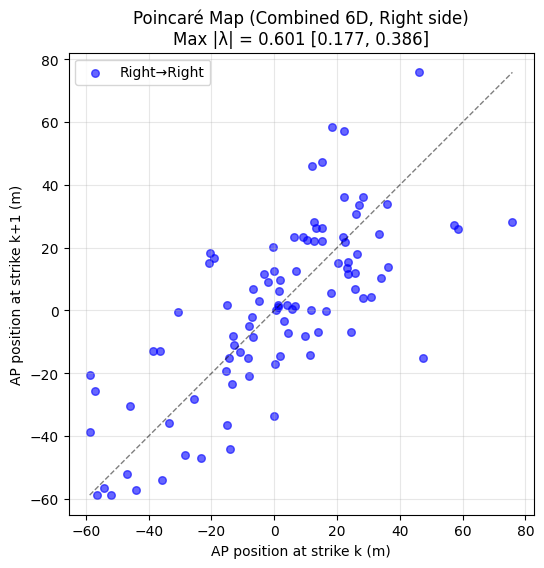


Combined (6D): λ = 0.6009 [0.1770, 0.3856]

ANALYZING STABILITY PER AXIS

COMPUTING PER-AXIS FLOQUET MULTIPLIERS

Analyzing Medio-lateral (x) axis...
Using Right-to-Right strides: 98 strides


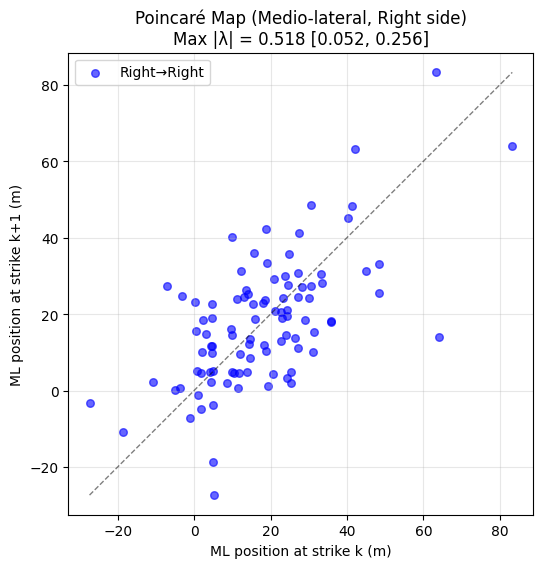


Analyzing Anterior-posterior (y) axis...
Using Right-to-Right strides: 98 strides


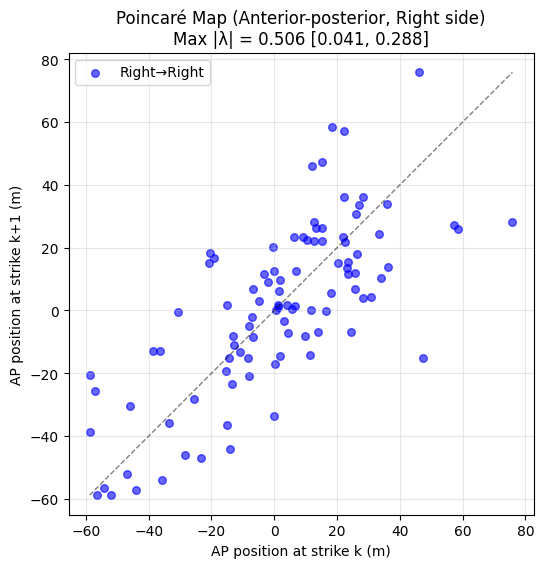


Analyzing Vertical (z) axis...
Using Right-to-Right strides: 98 strides


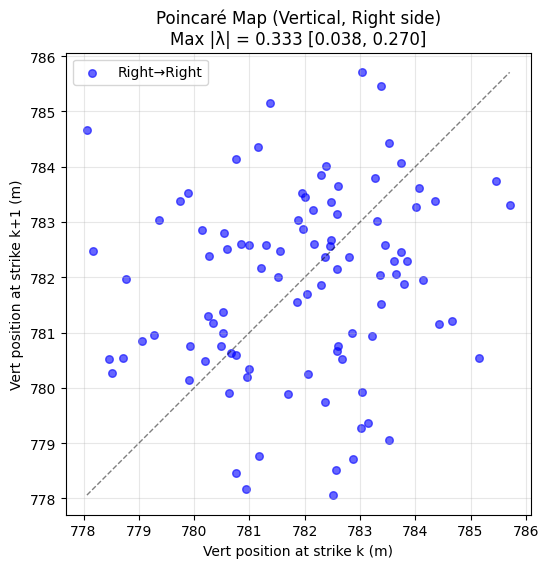


Analyzing Combined 6D state space...
Using Right-to-Right strides: 98 strides


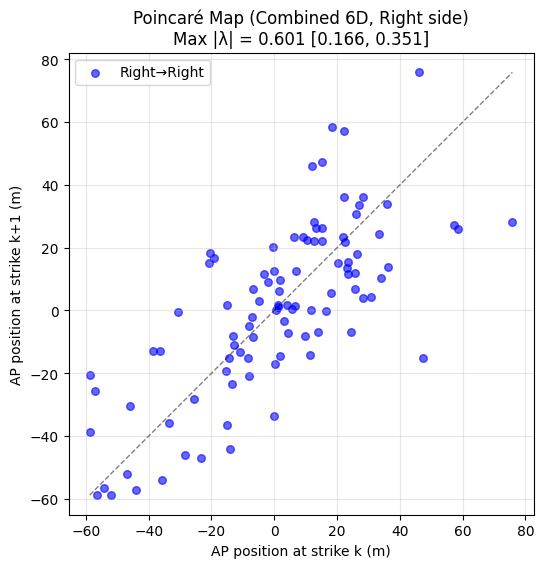


FLOQUET STABILITY SUMMARY (RIGHT FOOT)
Medio-lateral (x):      λ = 0.5181 [0.0519, 0.2562]
Anterior-posterior (y): λ = 0.5062 [0.0406, 0.2879]
Vertical (z):           λ = 0.3327 [0.0383, 0.2698]
Combined (6D):          λ = 0.6009 [0.1661, 0.3513]

Most stable direction:  Vertical (λ = 0.3327)
Least stable direction: Medio-lateral (λ = 0.5181)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 98 strides


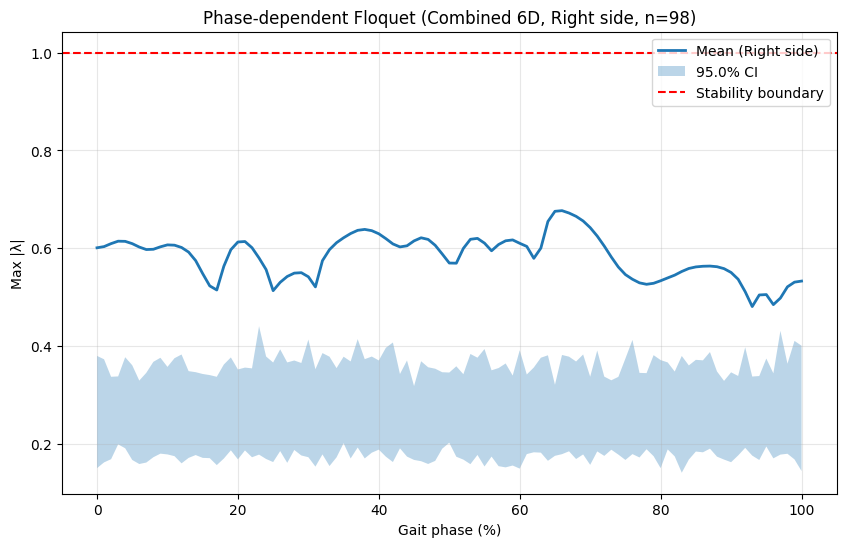

Most stable phase: 93% of gait cycle (λ = 0.4807)
Least stable phase: 66% of gait cycle (λ = 0.6769)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 98 strides


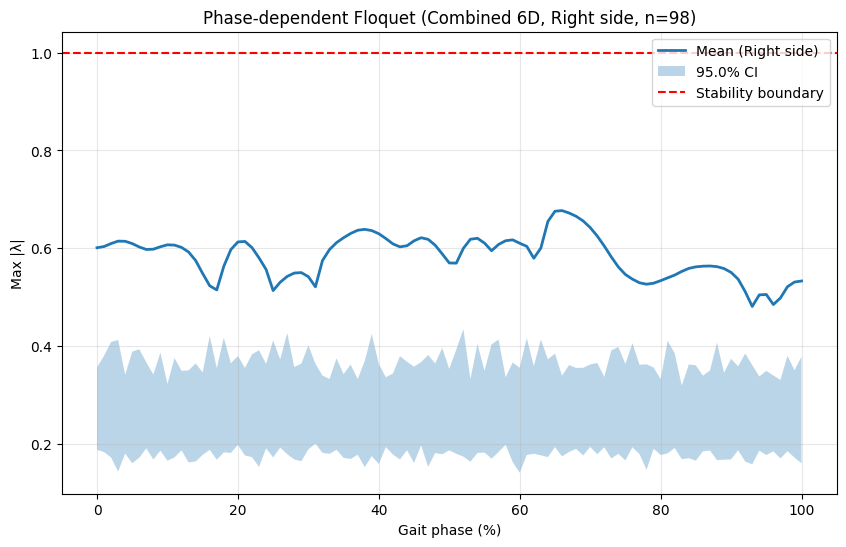

Most stable phase: 93% of gait cycle (λ = 0.4807)
Least stable phase: 66% of gait cycle (λ = 0.6769)

Phase-dependent analysis per axis...

Computing phase-dependent for Medio-lateral axis...
Using Right-to-Right strides: 98 strides


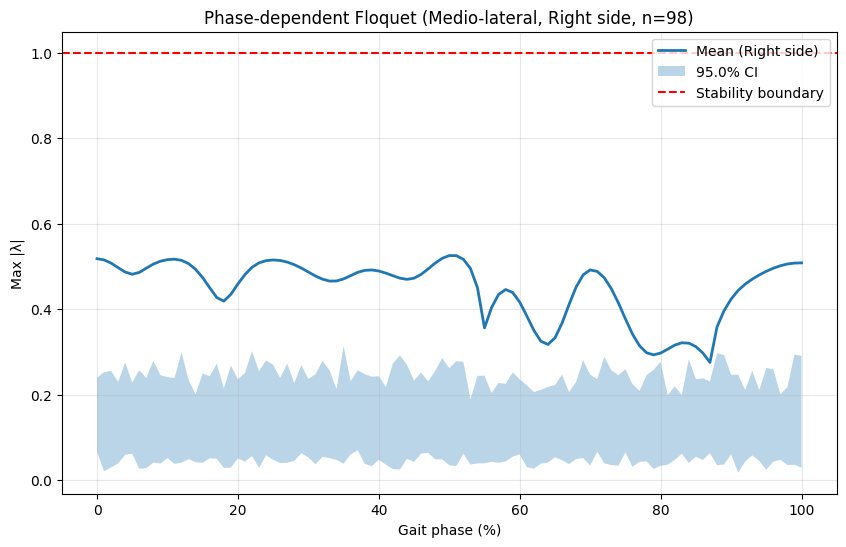

Computing phase-dependent for Anterior-posterior axis...
Using Right-to-Right strides: 98 strides


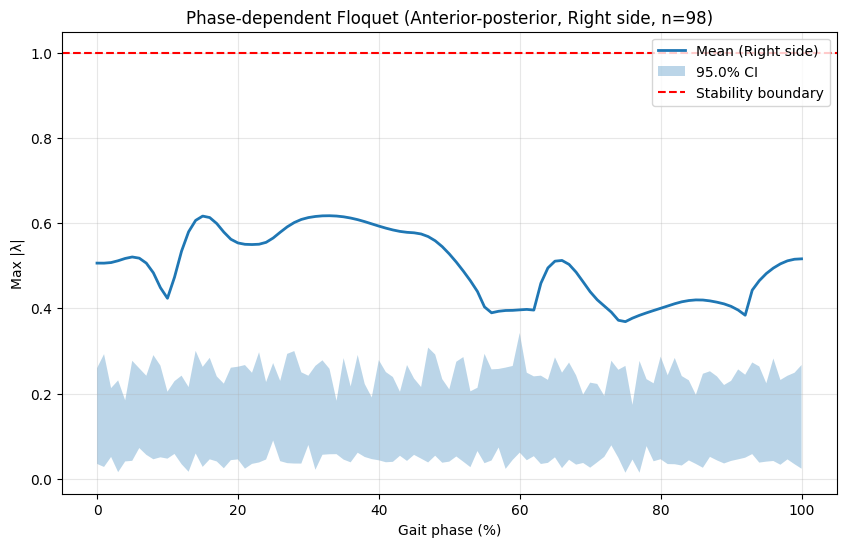

Computing phase-dependent for Vertical axis...
Using Right-to-Right strides: 98 strides


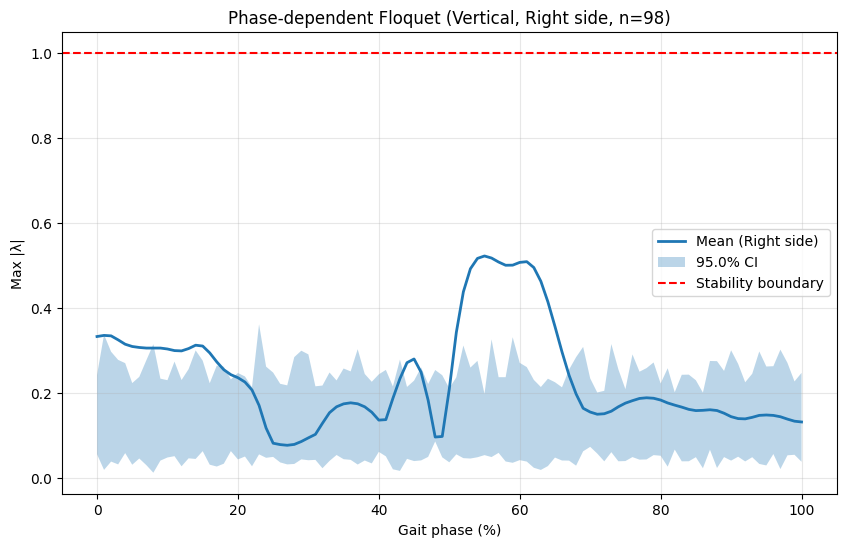

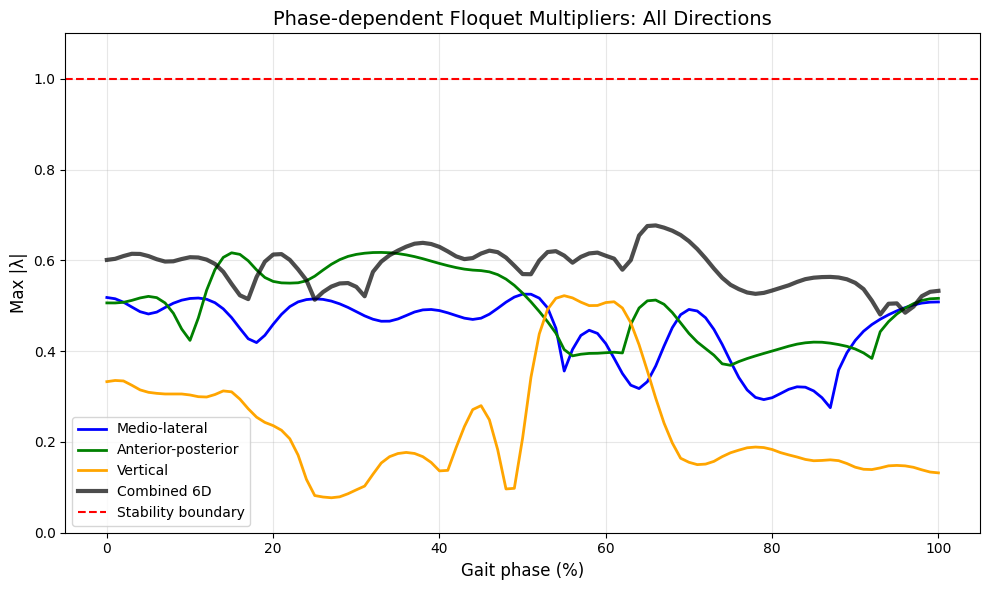


PHASE-SPECIFIC STABILITY SUMMARY
Heel strike (0%): λ = 0.6009
Loading response (10%): λ = 0.6069
Mid-stance (30%): λ = 0.5416
Terminal stance (50%): λ = 0.5697
Pre-swing (60%): λ = 0.6101
Initial swing (73%): λ = 0.5820
Mid-swing (87%): λ = 0.5635
Terminal swing (100%): λ = 0.5328

Extracting normalized trajectories for limit cycle analysis...

Extracting 98 Right-to-Right strides
Extracted data shape: 98 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


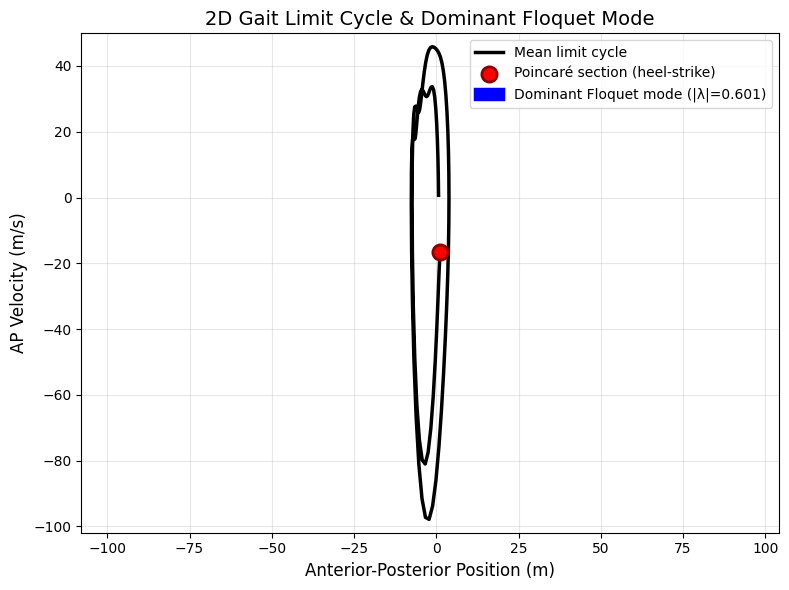


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.6009
- Eigenvector direction in (y, ẏ): [-0.097, 0.023]


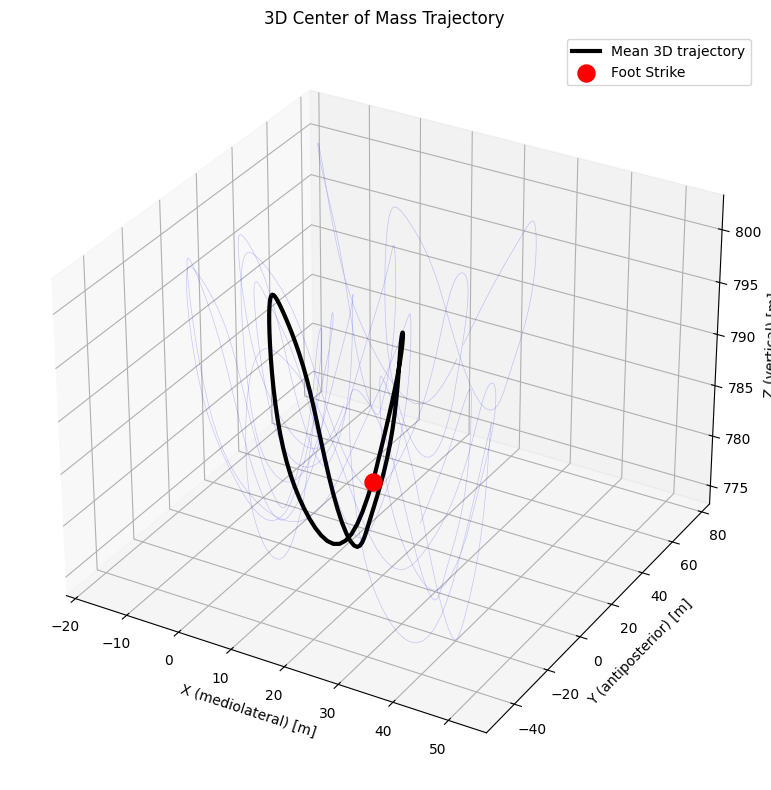

In [20]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events

def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # Load the data
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "03" /  "markers.nc"
    events_path = cwd.parent  / ".." / "data" / "PBT" / "Elderly" / "03" /  "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds = xr.open_dataset(data_path)
    df_all = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time = SKIP_SAMPLES / fs

    # Get foot strike events
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], 120.0
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (all {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 1) First, run a simple combined analysis to check everything works
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running combined 6D analysis first...")
    print("="*60)
    
    combined_result = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=['x', 'y', 'z'],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=100,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    print(f"\nCombined (6D): λ = {combined_result['max_floquet']:.4f} [{combined_result['confidence_interval'][0]:.4f}, {combined_result['confidence_interval'][1]:.4f}]")
    
    # ——————————————————————————————
    # 2) Now compute per-axis if you have the function defined
    # ——————————————————————————————
    if 'compute_floquet_per_axis' in globals():
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS")
        print("="*60)
        
        axis_results = compute_floquet_per_axis(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=False,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=100,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        # Display summary
        print("\n" + "="*60)
        print("FLOQUET STABILITY SUMMARY (RIGHT FOOT)")
        print("="*60)
        print(f"Medio-lateral (x):      λ = {axis_results['x']['max_floquet']:.4f} [{axis_results['x']['confidence_interval'][0]:.4f}, {axis_results['x']['confidence_interval'][1]:.4f}]")
        print(f"Anterior-posterior (y): λ = {axis_results['y']['max_floquet']:.4f} [{axis_results['y']['confidence_interval'][0]:.4f}, {axis_results['y']['confidence_interval'][1]:.4f}]")
        print(f"Vertical (z):           λ = {axis_results['z']['max_floquet']:.4f} [{axis_results['z']['confidence_interval'][0]:.4f}, {axis_results['z']['confidence_interval'][1]:.4f}]")
        print(f"Combined (6D):          λ = {axis_results['combined']['max_floquet']:.4f} [{axis_results['combined']['confidence_interval'][0]:.4f}, {axis_results['combined']['confidence_interval'][1]:.4f}]")
        
        # Identify most/least stable directions
        axis_values = {
            'Medio-lateral': axis_results['x']['max_floquet'],
            'Anterior-posterior': axis_results['y']['max_floquet'],
            'Vertical': axis_results['z']['max_floquet']
        }
        
        most_stable_axis = min(axis_values, key=axis_values.get)
        least_stable_axis = max(axis_values, key=axis_values.get)
        
        print(f"\nMost stable direction:  {most_stable_axis} (λ = {axis_values[most_stable_axis]:.4f})")
        print(f"Least stable direction: {least_stable_axis} (λ = {axis_values[least_stable_axis]:.4f})")
    else:
        # If compute_floquet_per_axis is not defined, compute each axis manually
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS (Manual)")
        print("="*60)
        
        axis_results = {}
        
        # Compute for each axis
        for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
            print(f"\nAnalyzing {name} ({axis}) axis...")
            axis_result = compute_floquet_from_events(
                com_da=com_window,
                events_df=df_window,
                channel="COM",
                axes=[axis],  # Single axis only
                normalization_points=101,
                rcond=1e-6,
                phase_dependent=False,
                plot_spectrum=False,
                use_same_side=True,
                force_side='Right',
                trim_cycles=0,
                bootstrap_n=100,
                bootstrap_ci=95.0,
                lowpass_cutoff=8.0,
                min_cycles_required=150
            )
            axis_results[axis] = axis_result
            print(f"{name}: λ = {axis_result['max_floquet']:.4f} [{axis_result['confidence_interval'][0]:.4f}, {axis_result['confidence_interval'][1]:.4f}]")
        
        axis_results['combined'] = combined_result



    # ——————————————————————————————
    # 4) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,  # Enable phase-dependent
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,  # Fewer iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    # The function automatically plots, but let's also create a custom plot
    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']
    ci_low, ci_high = phase_results['confidence_interval']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 1) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 2) Phase-dependent for each axis separately
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Phase-dependent analysis per axis...")
    print("="*60 + "\n")
    
    axis_phase_results = {}
    
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        print(f"Computing phase-dependent for {name} axis...")
        
        phase_result = compute_floquet_from_events(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            axes=[axis],
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=True,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=30,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        axis_phase_results[axis] = phase_result

    # ——————————————————————————————
    # 3) Create comparison plot of all axes on one graph
    # ——————————————————————————————
    plt.figure(figsize=(10, 6))
    
    # Plot each axis
    colors = {'x': 'blue', 'y': 'green', 'z': 'orange'}
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        plt.plot(phases, axis_phase_results[axis]['max_floquet'], 
                color=colors[axis], linewidth=2, label=name)
    
    # Add combined
    plt.plot(phases, phase_results['max_floquet'], 'k-', 
            linewidth=3, label='Combined 6D', alpha=0.7)
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
    plt.xlabel('Gait phase (%)', fontsize=12)
    plt.ylabel('Max |λ|', fontsize=12)
    plt.title('Phase-dependent Floquet Multipliers: All Directions', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    # ——————————————————————————————
    # 4) Print phase-specific statistics
    # ——————————————————————————————
    print("\n" + "="*60)
    print("PHASE-SPECIFIC STABILITY SUMMARY")
    print("="*60)
    
    # Typical gait events
    gait_events = {
        0: "Heel strike",
        10: "Loading response", 
        30: "Mid-stance",
        50: "Terminal stance",
        60: "Pre-swing",
        73: "Initial swing",
        87: "Mid-swing",
        100: "Terminal swing"
    }
    
    for phase, event in gait_events.items():
        if phase < len(phase_results['max_floquet']):
            print(f"{event} ({phase}%): λ = {phase_results['max_floquet'][phase]:.4f}")

        
    # ——————————————————————————————
    # 3) Extract data for limit cycle visualization
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,
        side_used='Right',
        trim_cycles=0,
        lowpass_cutoff=8.0,
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # Plot the 2D limit cycle
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

## Post 

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 160.00s to 234.68s (all 211 R_FS)
Using 134 foot‐strike events for Floquet segmentation

Running combined 6D analysis first...
Using Right-to-Right strides: 66 strides


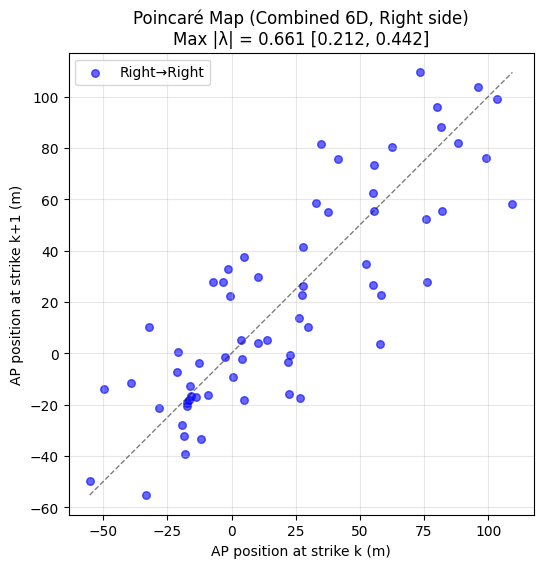


Combined (6D): λ = 0.6610 [0.2119, 0.4416]

ANALYZING STABILITY PER AXIS

COMPUTING PER-AXIS FLOQUET MULTIPLIERS

Analyzing Medio-lateral (x) axis...
Using Right-to-Right strides: 66 strides


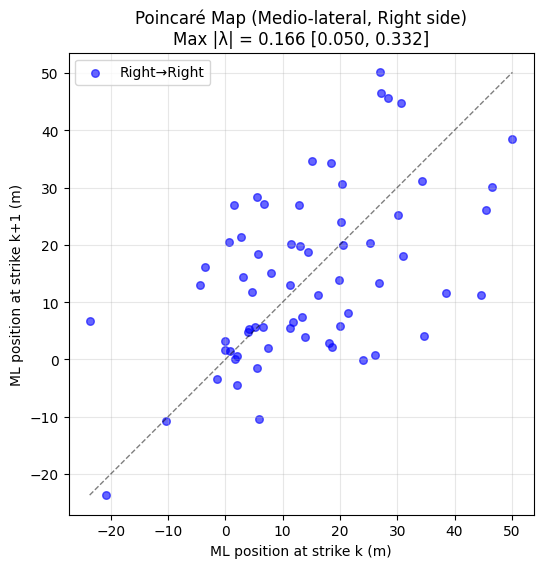


Analyzing Anterior-posterior (y) axis...
Using Right-to-Right strides: 66 strides


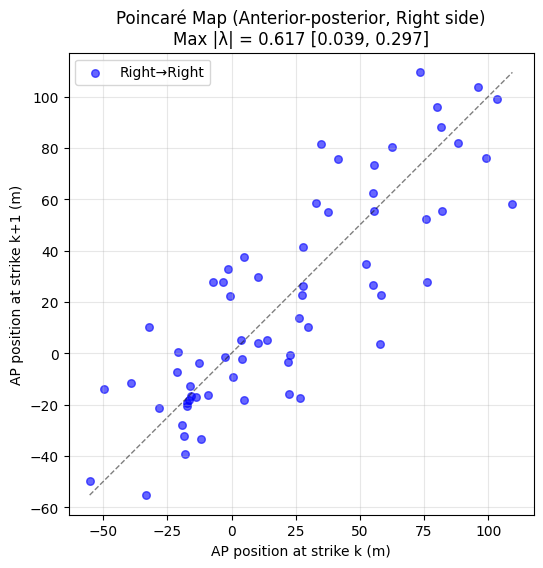


Analyzing Vertical (z) axis...
Using Right-to-Right strides: 66 strides


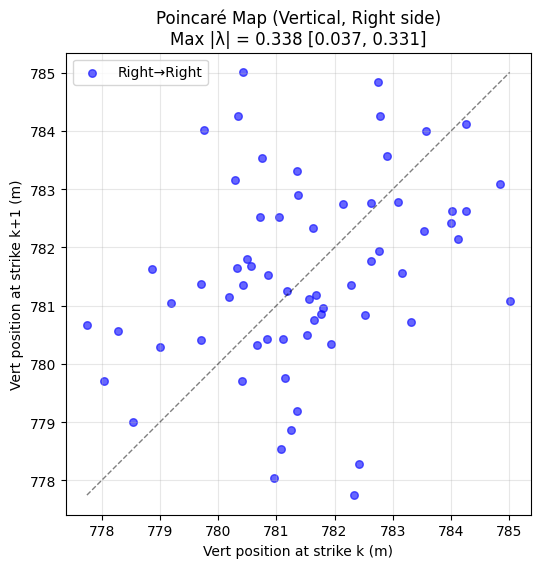


Analyzing Combined 6D state space...
Using Right-to-Right strides: 66 strides


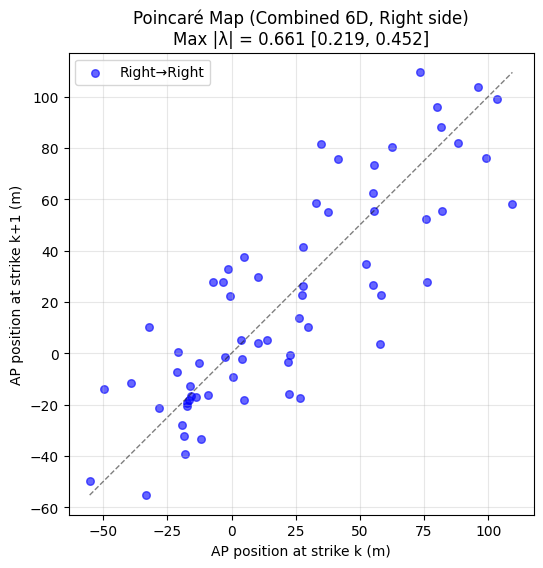


FLOQUET STABILITY SUMMARY (RIGHT FOOT)
Medio-lateral (x):      λ = 0.1665 [0.0495, 0.3320]
Anterior-posterior (y): λ = 0.6168 [0.0391, 0.2967]
Vertical (z):           λ = 0.3381 [0.0372, 0.3312]
Combined (6D):          λ = 0.6610 [0.2190, 0.4515]

Most stable direction:  Medio-lateral (λ = 0.1665)
Least stable direction: Anterior-posterior (λ = 0.6168)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 66 strides


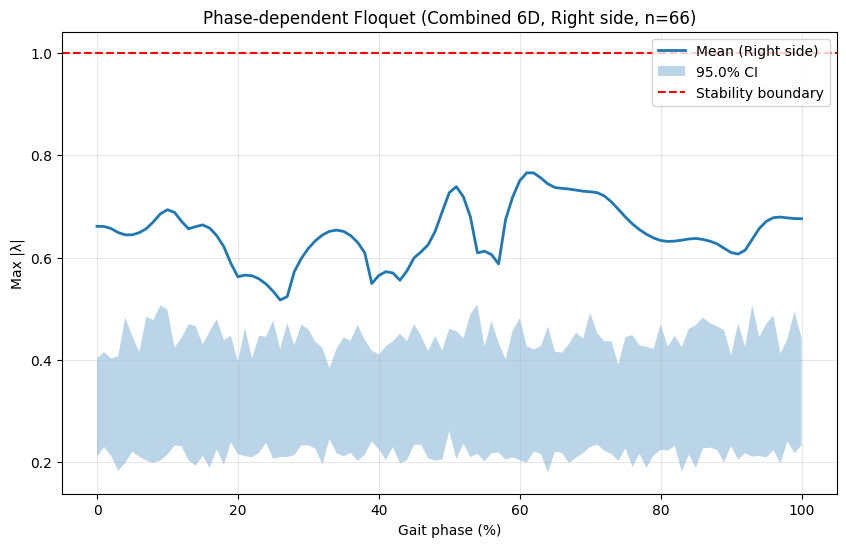

Most stable phase: 26% of gait cycle (λ = 0.5171)
Least stable phase: 61% of gait cycle (λ = 0.7655)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 66 strides


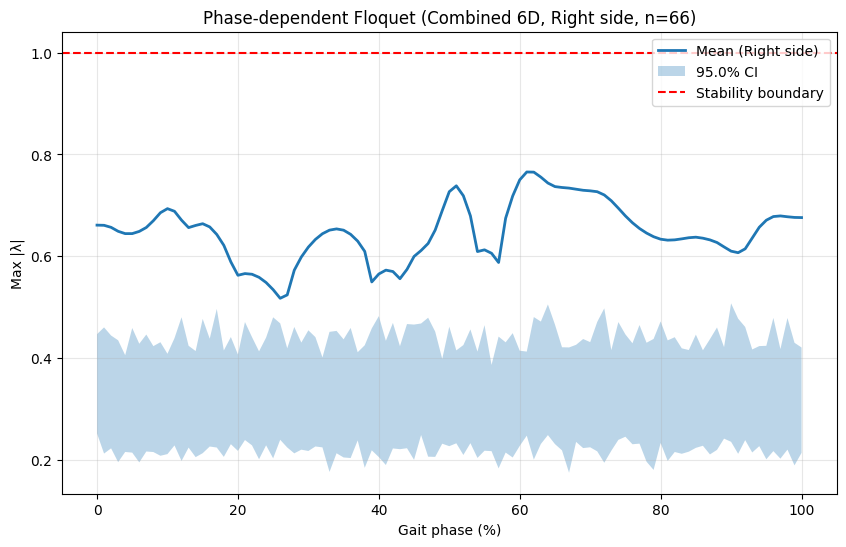

Most stable phase: 26% of gait cycle (λ = 0.5171)
Least stable phase: 61% of gait cycle (λ = 0.7655)

Phase-dependent analysis per axis...

Computing phase-dependent for Medio-lateral axis...
Using Right-to-Right strides: 66 strides


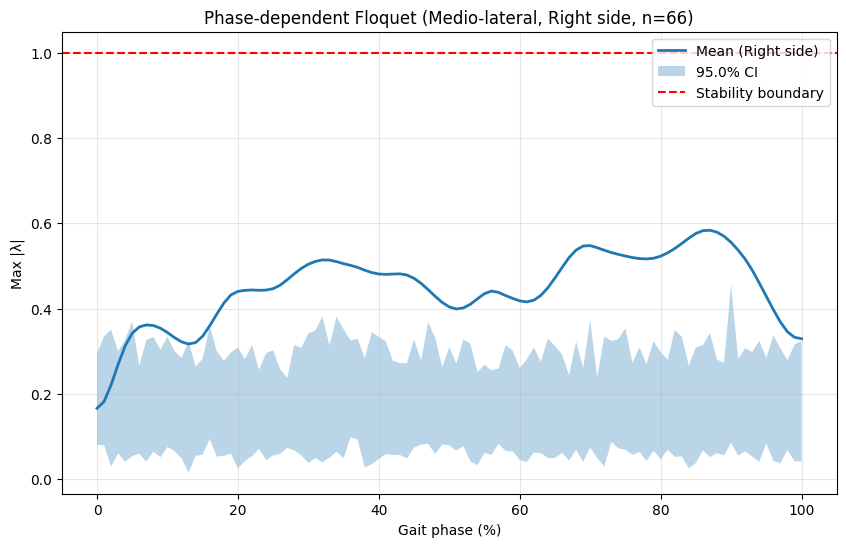

Computing phase-dependent for Anterior-posterior axis...
Using Right-to-Right strides: 66 strides


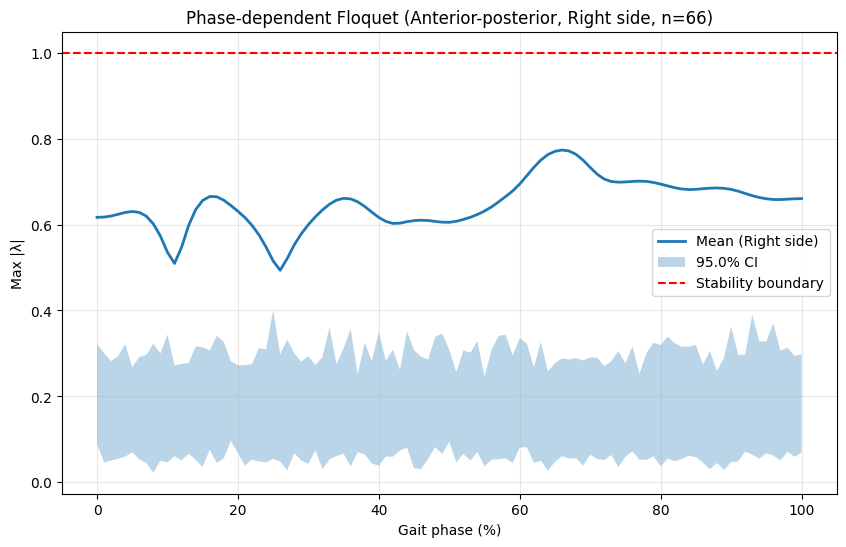

Computing phase-dependent for Vertical axis...
Using Right-to-Right strides: 66 strides


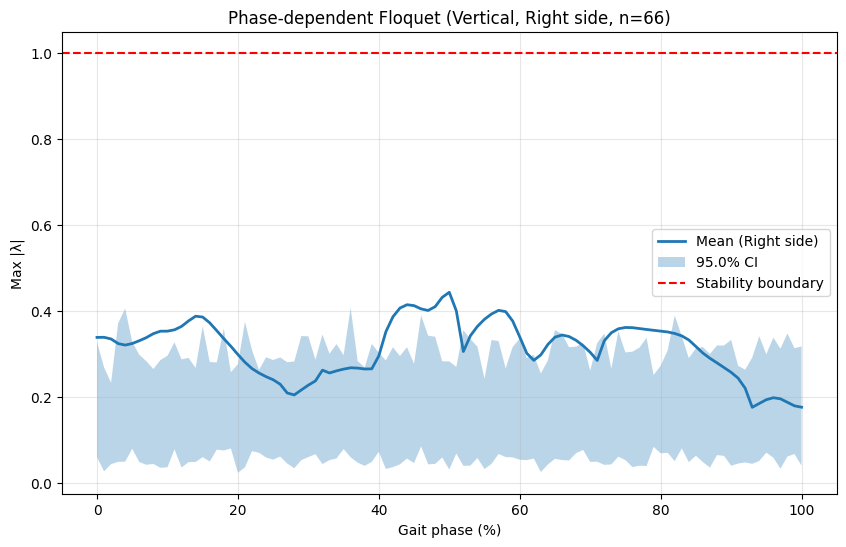

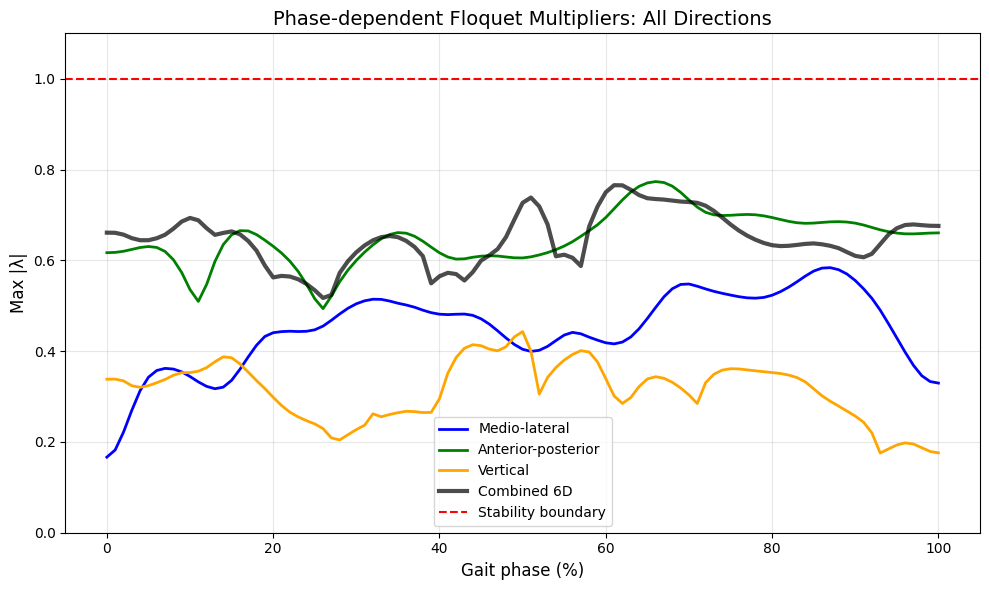


PHASE-SPECIFIC STABILITY SUMMARY
Heel strike (0%): λ = 0.6610
Loading response (10%): λ = 0.6934
Mid-stance (30%): λ = 0.6178
Terminal stance (50%): λ = 0.7267
Pre-swing (60%): λ = 0.7500
Initial swing (73%): λ = 0.7088
Mid-swing (87%): λ = 0.6319
Terminal swing (100%): λ = 0.6758

Extracting normalized trajectories for limit cycle analysis...

Extracting 66 Right-to-Right strides
Extracted data shape: 66 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


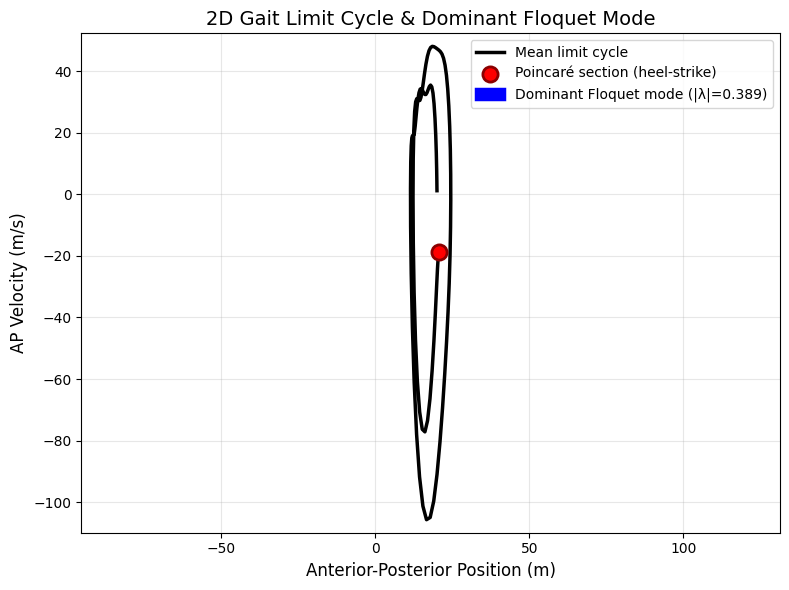


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.3894
- Eigenvector direction in (y, ẏ): [-0.075, 0.066]


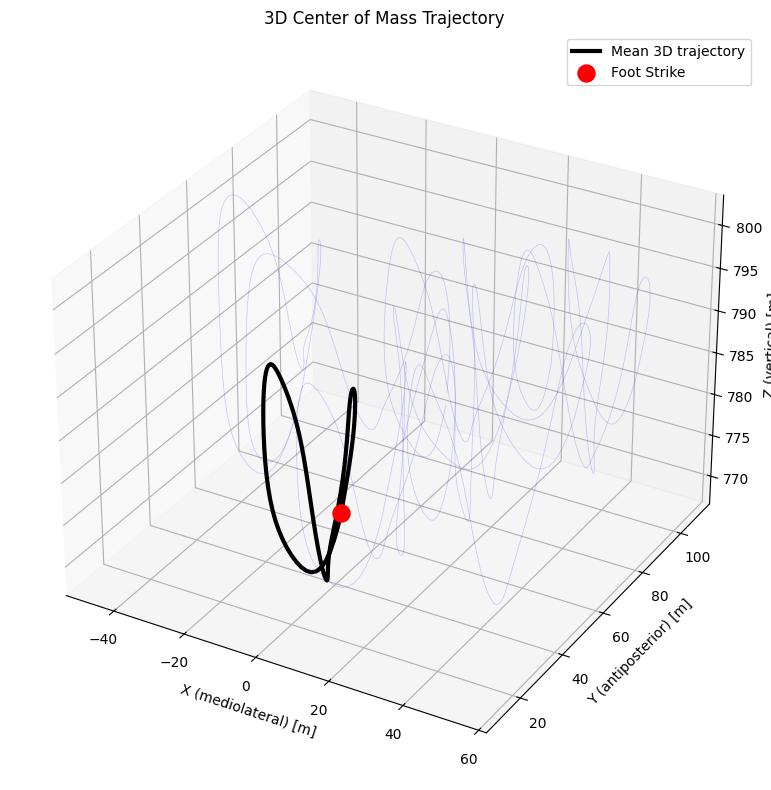

In [21]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events

def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # Load the data
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "03" /  "markers.nc"
    events_path = cwd.parent  / ".." / "data" / "PBT" / "Elderly" / "03" /  "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds = xr.open_dataset(data_path)
    df_all = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time = SKIP_SAMPLES / fs

    # Get foot strike events
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = 160.0, first_n.time.iloc[-1] - 10.0
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (all {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 1) First, run a simple combined analysis to check everything works
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running combined 6D analysis first...")
    print("="*60)
    
    combined_result = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=['x', 'y', 'z'],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=100,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    print(f"\nCombined (6D): λ = {combined_result['max_floquet']:.4f} [{combined_result['confidence_interval'][0]:.4f}, {combined_result['confidence_interval'][1]:.4f}]")
    
    # ——————————————————————————————
    # 2) Now compute per-axis if you have the function defined
    # ——————————————————————————————
    if 'compute_floquet_per_axis' in globals():
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS")
        print("="*60)
        
        axis_results = compute_floquet_per_axis(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=False,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=100,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        # Display summary
        print("\n" + "="*60)
        print("FLOQUET STABILITY SUMMARY (RIGHT FOOT)")
        print("="*60)
        print(f"Medio-lateral (x):      λ = {axis_results['x']['max_floquet']:.4f} [{axis_results['x']['confidence_interval'][0]:.4f}, {axis_results['x']['confidence_interval'][1]:.4f}]")
        print(f"Anterior-posterior (y): λ = {axis_results['y']['max_floquet']:.4f} [{axis_results['y']['confidence_interval'][0]:.4f}, {axis_results['y']['confidence_interval'][1]:.4f}]")
        print(f"Vertical (z):           λ = {axis_results['z']['max_floquet']:.4f} [{axis_results['z']['confidence_interval'][0]:.4f}, {axis_results['z']['confidence_interval'][1]:.4f}]")
        print(f"Combined (6D):          λ = {axis_results['combined']['max_floquet']:.4f} [{axis_results['combined']['confidence_interval'][0]:.4f}, {axis_results['combined']['confidence_interval'][1]:.4f}]")
        
        # Identify most/least stable directions
        axis_values = {
            'Medio-lateral': axis_results['x']['max_floquet'],
            'Anterior-posterior': axis_results['y']['max_floquet'],
            'Vertical': axis_results['z']['max_floquet']
        }
        
        most_stable_axis = min(axis_values, key=axis_values.get)
        least_stable_axis = max(axis_values, key=axis_values.get)
        
        print(f"\nMost stable direction:  {most_stable_axis} (λ = {axis_values[most_stable_axis]:.4f})")
        print(f"Least stable direction: {least_stable_axis} (λ = {axis_values[least_stable_axis]:.4f})")
    else:
        # If compute_floquet_per_axis is not defined, compute each axis manually
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS (Manual)")
        print("="*60)
        
        axis_results = {}
        
        # Compute for each axis
        for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
            print(f"\nAnalyzing {name} ({axis}) axis...")
            axis_result = compute_floquet_from_events(
                com_da=com_window,
                events_df=df_window,
                channel="COM",
                axes=[axis],  # Single axis only
                normalization_points=101,
                rcond=1e-6,
                phase_dependent=False,
                plot_spectrum=False,
                use_same_side=True,
                force_side='Right',
                trim_cycles=0,
                bootstrap_n=100,
                bootstrap_ci=95.0,
                lowpass_cutoff=8.0,
                min_cycles_required=150
            )
            axis_results[axis] = axis_result
            print(f"{name}: λ = {axis_result['max_floquet']:.4f} [{axis_result['confidence_interval'][0]:.4f}, {axis_result['confidence_interval'][1]:.4f}]")
        
        axis_results['combined'] = combined_result



    # ——————————————————————————————
    # 4) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,  # Enable phase-dependent
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,  # Fewer iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    # The function automatically plots, but let's also create a custom plot
    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']
    ci_low, ci_high = phase_results['confidence_interval']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 1) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 2) Phase-dependent for each axis separately
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Phase-dependent analysis per axis...")
    print("="*60 + "\n")
    
    axis_phase_results = {}
    
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        print(f"Computing phase-dependent for {name} axis...")
        
        phase_result = compute_floquet_from_events(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            axes=[axis],
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=True,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=30,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        axis_phase_results[axis] = phase_result

    # ——————————————————————————————
    # 3) Create comparison plot of all axes on one graph
    # ——————————————————————————————
    plt.figure(figsize=(10, 6))
    
    # Plot each axis
    colors = {'x': 'blue', 'y': 'green', 'z': 'orange'}
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        plt.plot(phases, axis_phase_results[axis]['max_floquet'], 
                color=colors[axis], linewidth=2, label=name)
    
    # Add combined
    plt.plot(phases, phase_results['max_floquet'], 'k-', 
            linewidth=3, label='Combined 6D', alpha=0.7)
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
    plt.xlabel('Gait phase (%)', fontsize=12)
    plt.ylabel('Max |λ|', fontsize=12)
    plt.title('Phase-dependent Floquet Multipliers: All Directions', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    # ——————————————————————————————
    # 4) Print phase-specific statistics
    # ——————————————————————————————
    print("\n" + "="*60)
    print("PHASE-SPECIFIC STABILITY SUMMARY")
    print("="*60)
    
    # Typical gait events
    gait_events = {
        0: "Heel strike",
        10: "Loading response", 
        30: "Mid-stance",
        50: "Terminal stance",
        60: "Pre-swing",
        73: "Initial swing",
        87: "Mid-swing",
        100: "Terminal swing"
    }
    
    for phase, event in gait_events.items():
        if phase < len(phase_results['max_floquet']):
            print(f"{event} ({phase}%): λ = {phase_results['max_floquet'][phase]:.4f}")

        
    # ——————————————————————————————
    # 3) Extract data for limit cycle visualization
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,
        side_used='Right',
        trim_cycles=0,
        lowpass_cutoff=8.0,
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # Plot the 2D limit cycle
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

# Patient 04

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 10.54s to 120.00s (all 186 R_FS)
Using 177 foot‐strike events for Floquet segmentation

Running combined 6D analysis first...
Using Right-to-Right strides: 88 strides


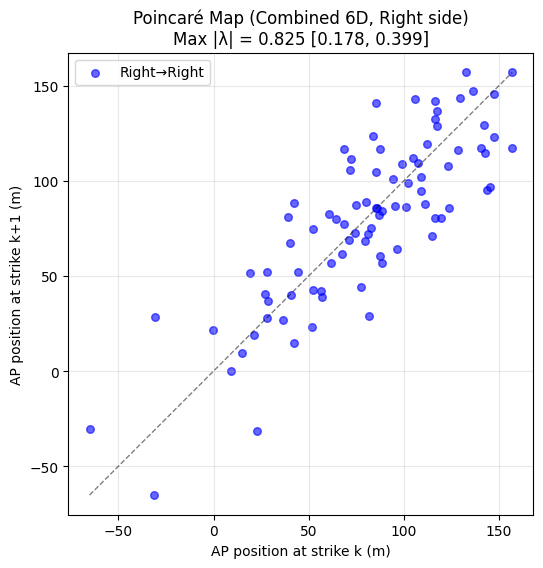


Combined (6D): λ = 0.8254 [0.1783, 0.3989]

ANALYZING STABILITY PER AXIS

COMPUTING PER-AXIS FLOQUET MULTIPLIERS

Analyzing Medio-lateral (x) axis...
Using Right-to-Right strides: 88 strides


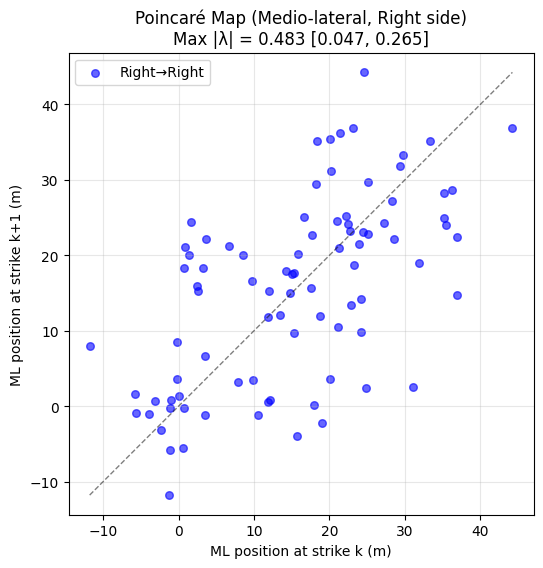


Analyzing Anterior-posterior (y) axis...
Using Right-to-Right strides: 88 strides


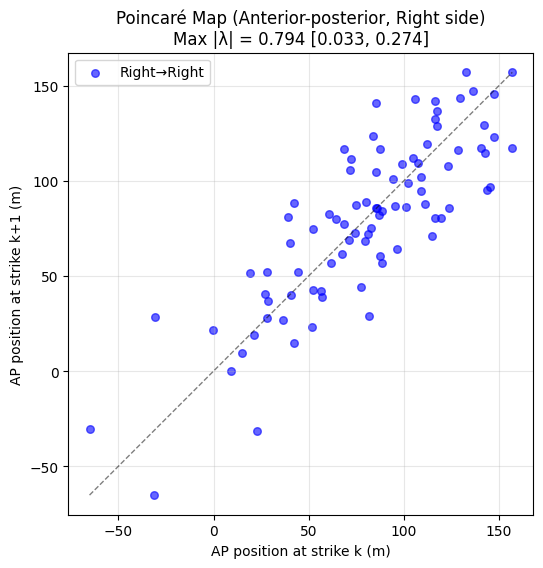


Analyzing Vertical (z) axis...
Using Right-to-Right strides: 88 strides


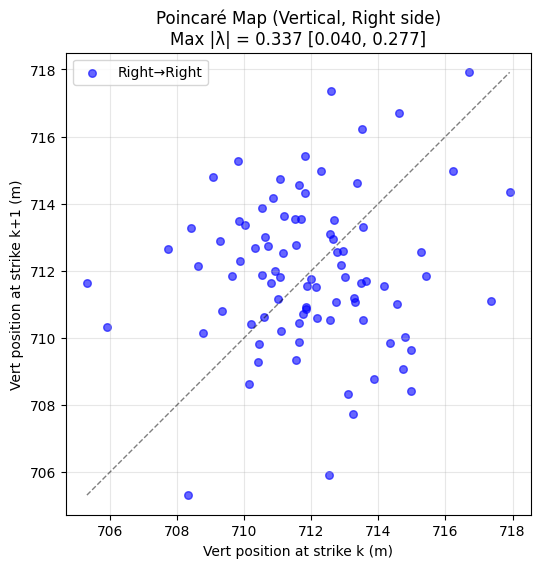


Analyzing Combined 6D state space...
Using Right-to-Right strides: 88 strides


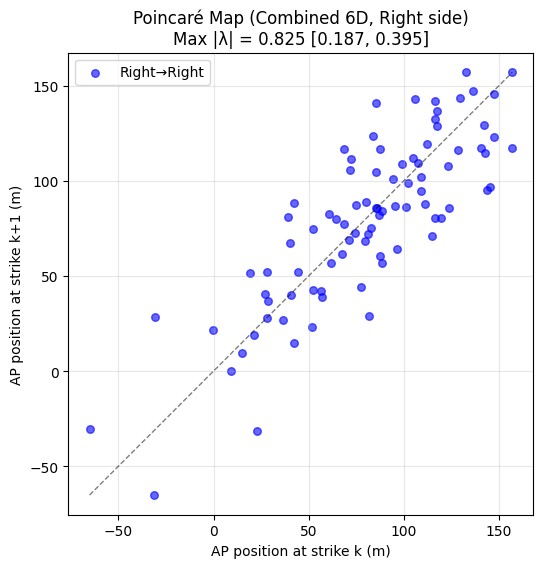


FLOQUET STABILITY SUMMARY (RIGHT FOOT)
Medio-lateral (x):      λ = 0.4835 [0.0470, 0.2647]
Anterior-posterior (y): λ = 0.7939 [0.0329, 0.2744]
Vertical (z):           λ = 0.3373 [0.0403, 0.2768]
Combined (6D):          λ = 0.8254 [0.1871, 0.3952]

Most stable direction:  Vertical (λ = 0.3373)
Least stable direction: Anterior-posterior (λ = 0.7939)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 88 strides


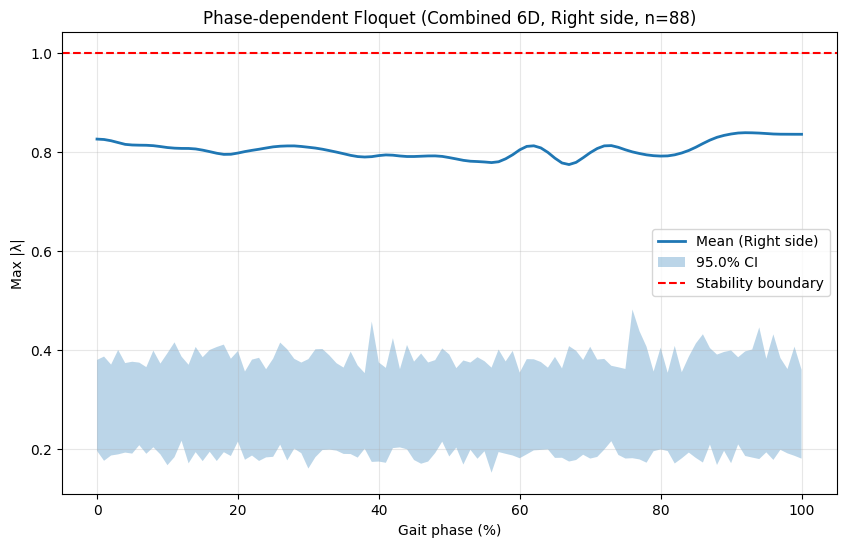

Most stable phase: 67% of gait cycle (λ = 0.7740)
Least stable phase: 92% of gait cycle (λ = 0.8383)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 88 strides


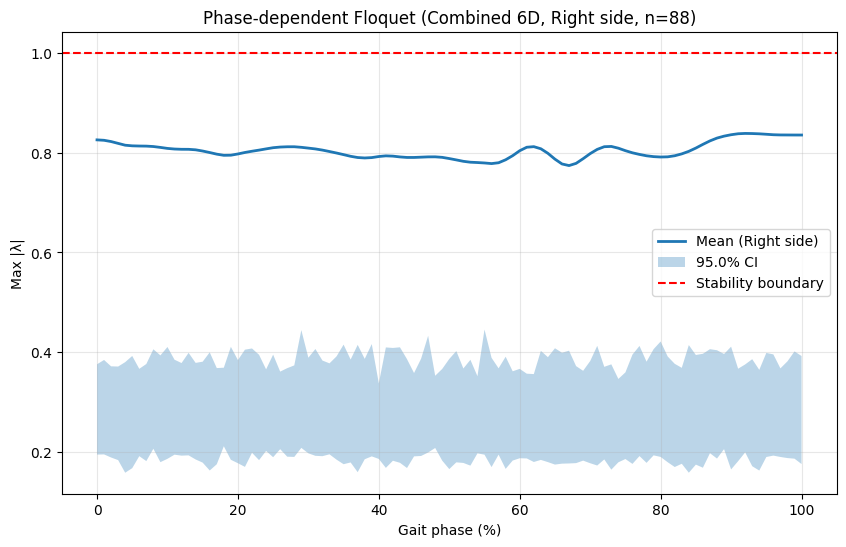

Most stable phase: 67% of gait cycle (λ = 0.7740)
Least stable phase: 92% of gait cycle (λ = 0.8383)

Phase-dependent analysis per axis...

Computing phase-dependent for Medio-lateral axis...
Using Right-to-Right strides: 88 strides


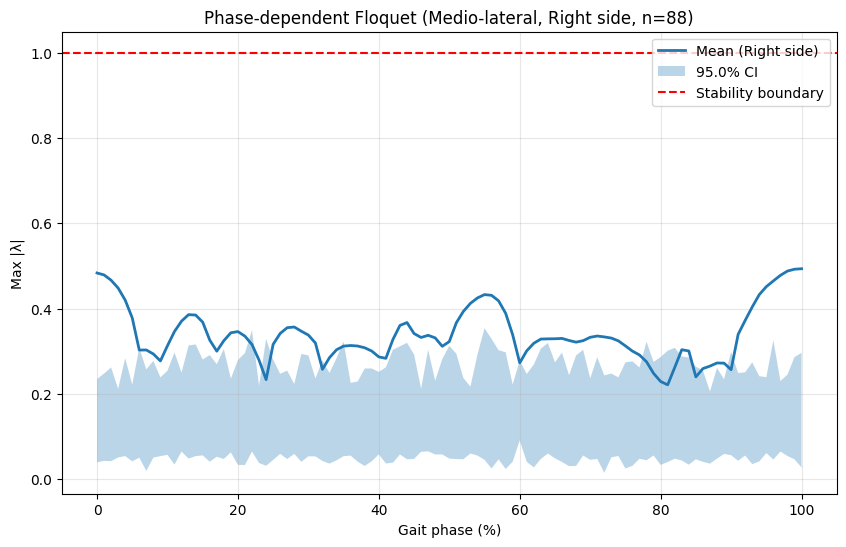

Computing phase-dependent for Anterior-posterior axis...
Using Right-to-Right strides: 88 strides


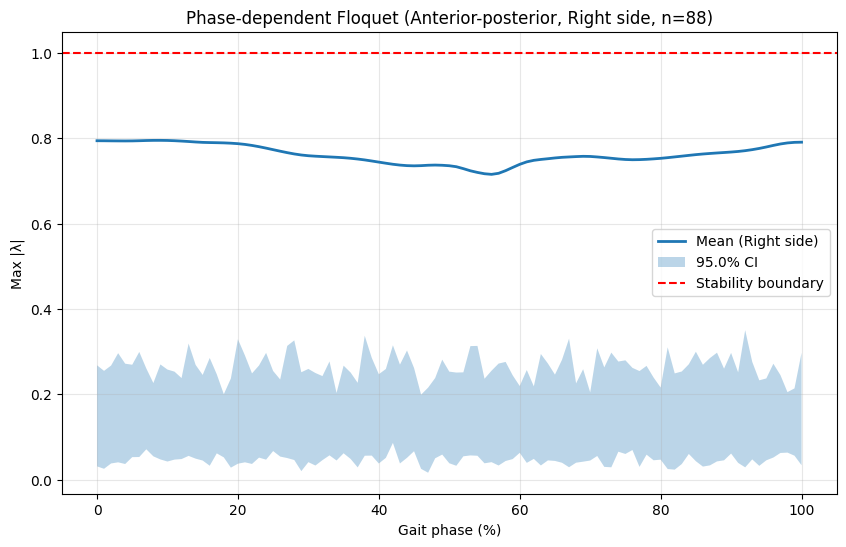

Computing phase-dependent for Vertical axis...
Using Right-to-Right strides: 88 strides


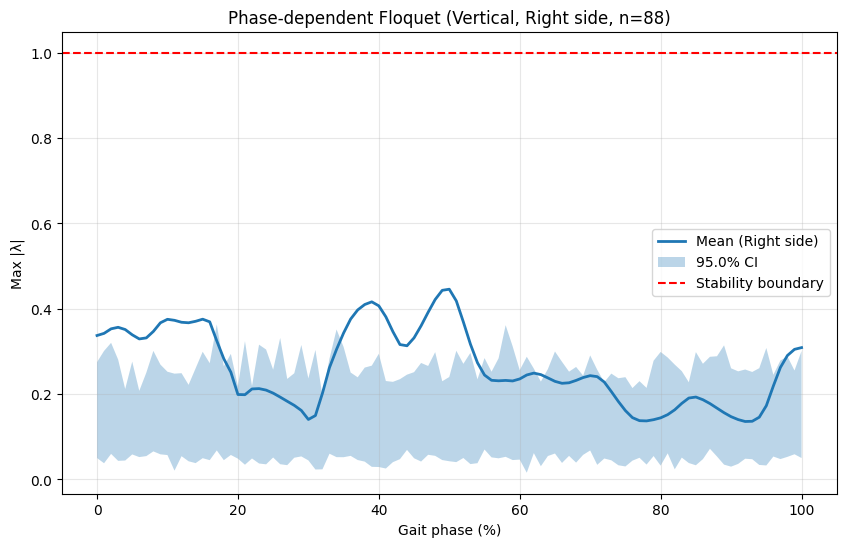

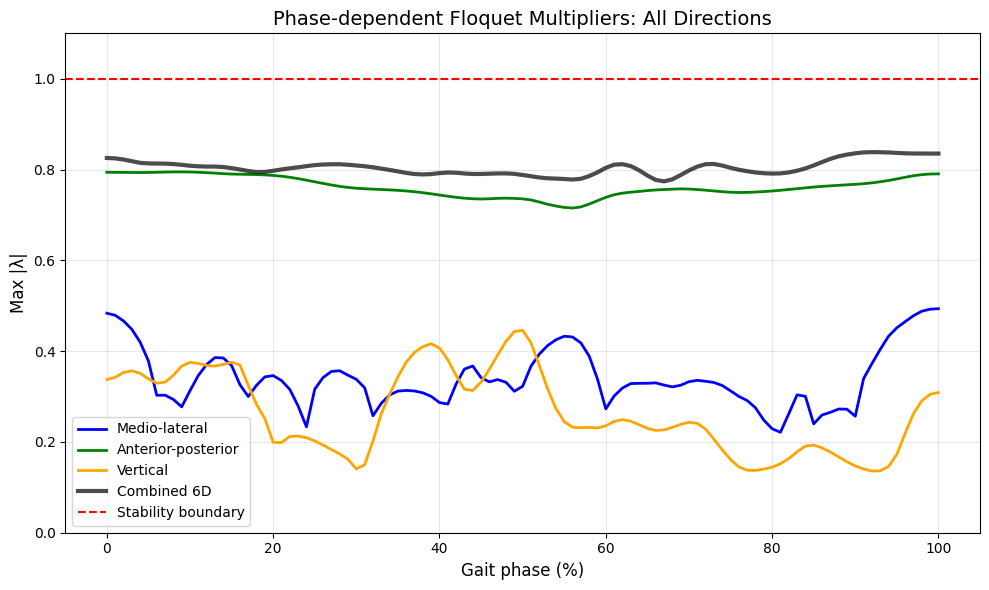


PHASE-SPECIFIC STABILITY SUMMARY
Heel strike (0%): λ = 0.8254
Loading response (10%): λ = 0.8083
Mid-stance (30%): λ = 0.8089
Terminal stance (50%): λ = 0.7880
Pre-swing (60%): λ = 0.8037
Initial swing (73%): λ = 0.8123
Mid-swing (87%): λ = 0.8234
Terminal swing (100%): λ = 0.8351

Extracting normalized trajectories for limit cycle analysis...

Extracting 88 Right-to-Right strides
Extracted data shape: 88 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


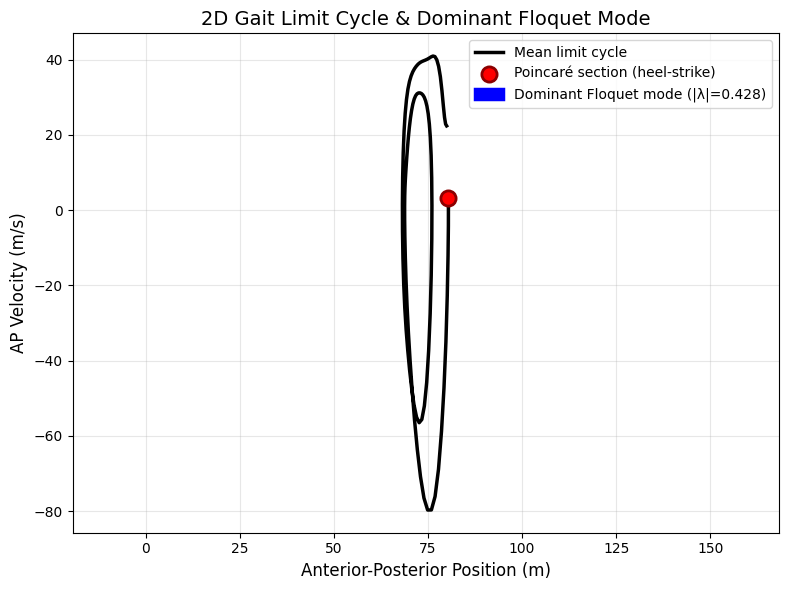


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.4282
- Eigenvector direction in (y, ẏ): [0.100, 0.000]


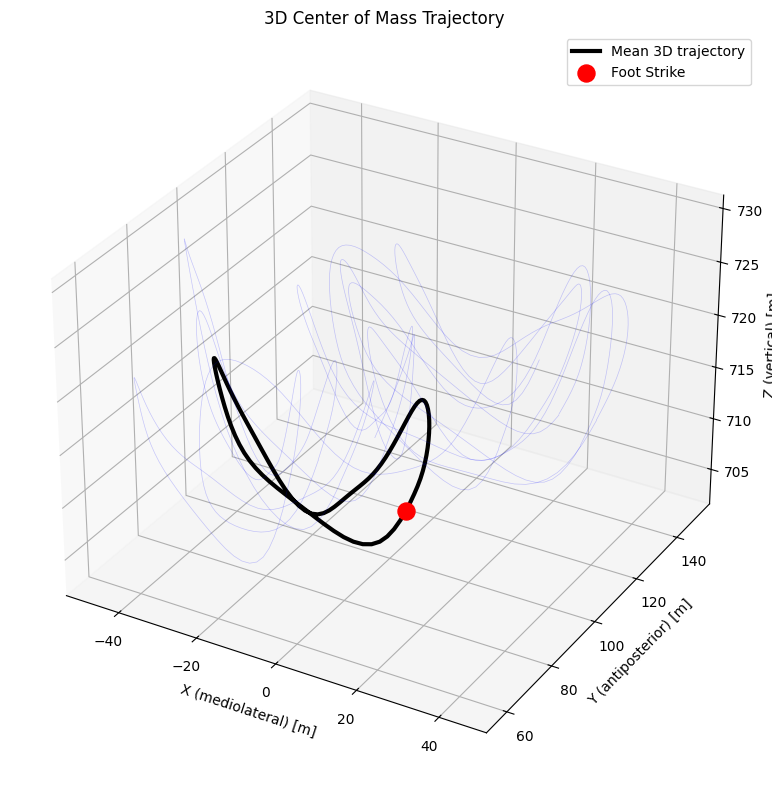

In [23]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events

def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # Load the data
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "04" /  "markers.nc"
    events_path = cwd.parent  / ".." / "data" / "PBT" / "Elderly" / "04" /  "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds = xr.open_dataset(data_path)
    df_all = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time = SKIP_SAMPLES / fs

    # Get foot strike events
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], 120.0
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (all {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 1) First, run a simple combined analysis to check everything works
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running combined 6D analysis first...")
    print("="*60)
    
    combined_result = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=['x', 'y', 'z'],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=100,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    print(f"\nCombined (6D): λ = {combined_result['max_floquet']:.4f} [{combined_result['confidence_interval'][0]:.4f}, {combined_result['confidence_interval'][1]:.4f}]")
    
    # ——————————————————————————————
    # 2) Now compute per-axis if you have the function defined
    # ——————————————————————————————
    if 'compute_floquet_per_axis' in globals():
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS")
        print("="*60)
        
        axis_results = compute_floquet_per_axis(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=False,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=100,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        # Display summary
        print("\n" + "="*60)
        print("FLOQUET STABILITY SUMMARY (RIGHT FOOT)")
        print("="*60)
        print(f"Medio-lateral (x):      λ = {axis_results['x']['max_floquet']:.4f} [{axis_results['x']['confidence_interval'][0]:.4f}, {axis_results['x']['confidence_interval'][1]:.4f}]")
        print(f"Anterior-posterior (y): λ = {axis_results['y']['max_floquet']:.4f} [{axis_results['y']['confidence_interval'][0]:.4f}, {axis_results['y']['confidence_interval'][1]:.4f}]")
        print(f"Vertical (z):           λ = {axis_results['z']['max_floquet']:.4f} [{axis_results['z']['confidence_interval'][0]:.4f}, {axis_results['z']['confidence_interval'][1]:.4f}]")
        print(f"Combined (6D):          λ = {axis_results['combined']['max_floquet']:.4f} [{axis_results['combined']['confidence_interval'][0]:.4f}, {axis_results['combined']['confidence_interval'][1]:.4f}]")
        
        # Identify most/least stable directions
        axis_values = {
            'Medio-lateral': axis_results['x']['max_floquet'],
            'Anterior-posterior': axis_results['y']['max_floquet'],
            'Vertical': axis_results['z']['max_floquet']
        }
        
        most_stable_axis = min(axis_values, key=axis_values.get)
        least_stable_axis = max(axis_values, key=axis_values.get)
        
        print(f"\nMost stable direction:  {most_stable_axis} (λ = {axis_values[most_stable_axis]:.4f})")
        print(f"Least stable direction: {least_stable_axis} (λ = {axis_values[least_stable_axis]:.4f})")
    else:
        # If compute_floquet_per_axis is not defined, compute each axis manually
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS (Manual)")
        print("="*60)
        
        axis_results = {}
        
        # Compute for each axis
        for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
            print(f"\nAnalyzing {name} ({axis}) axis...")
            axis_result = compute_floquet_from_events(
                com_da=com_window,
                events_df=df_window,
                channel="COM",
                axes=[axis],  # Single axis only
                normalization_points=101,
                rcond=1e-6,
                phase_dependent=False,
                plot_spectrum=False,
                use_same_side=True,
                force_side='Right',
                trim_cycles=0,
                bootstrap_n=100,
                bootstrap_ci=95.0,
                lowpass_cutoff=8.0,
                min_cycles_required=150
            )
            axis_results[axis] = axis_result
            print(f"{name}: λ = {axis_result['max_floquet']:.4f} [{axis_result['confidence_interval'][0]:.4f}, {axis_result['confidence_interval'][1]:.4f}]")
        
        axis_results['combined'] = combined_result



    # ——————————————————————————————
    # 4) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,  # Enable phase-dependent
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,  # Fewer iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    # The function automatically plots, but let's also create a custom plot
    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']
    ci_low, ci_high = phase_results['confidence_interval']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 1) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 2) Phase-dependent for each axis separately
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Phase-dependent analysis per axis...")
    print("="*60 + "\n")
    
    axis_phase_results = {}
    
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        print(f"Computing phase-dependent for {name} axis...")
        
        phase_result = compute_floquet_from_events(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            axes=[axis],
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=True,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=30,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        axis_phase_results[axis] = phase_result

    # ——————————————————————————————
    # 3) Create comparison plot of all axes on one graph
    # ——————————————————————————————
    plt.figure(figsize=(10, 6))
    
    # Plot each axis
    colors = {'x': 'blue', 'y': 'green', 'z': 'orange'}
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        plt.plot(phases, axis_phase_results[axis]['max_floquet'], 
                color=colors[axis], linewidth=2, label=name)
    
    # Add combined
    plt.plot(phases, phase_results['max_floquet'], 'k-', 
            linewidth=3, label='Combined 6D', alpha=0.7)
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
    plt.xlabel('Gait phase (%)', fontsize=12)
    plt.ylabel('Max |λ|', fontsize=12)
    plt.title('Phase-dependent Floquet Multipliers: All Directions', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    # ——————————————————————————————
    # 4) Print phase-specific statistics
    # ——————————————————————————————
    print("\n" + "="*60)
    print("PHASE-SPECIFIC STABILITY SUMMARY")
    print("="*60)
    
    # Typical gait events
    gait_events = {
        0: "Heel strike",
        10: "Loading response", 
        30: "Mid-stance",
        50: "Terminal stance",
        60: "Pre-swing",
        73: "Initial swing",
        87: "Mid-swing",
        100: "Terminal swing"
    }
    
    for phase, event in gait_events.items():
        if phase < len(phase_results['max_floquet']):
            print(f"{event} ({phase}%): λ = {phase_results['max_floquet'][phase]:.4f}")

        
    # ——————————————————————————————
    # 3) Extract data for limit cycle visualization
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,
        side_used='Right',
        trim_cycles=0,
        lowpass_cutoff=8.0,
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # Plot the 2D limit cycle
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

## Post

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 150.00s to 243.54s (all 186 R_FS)
Using 146 foot‐strike events for Floquet segmentation

Running combined 6D analysis first...
Using Right-to-Right strides: 72 strides


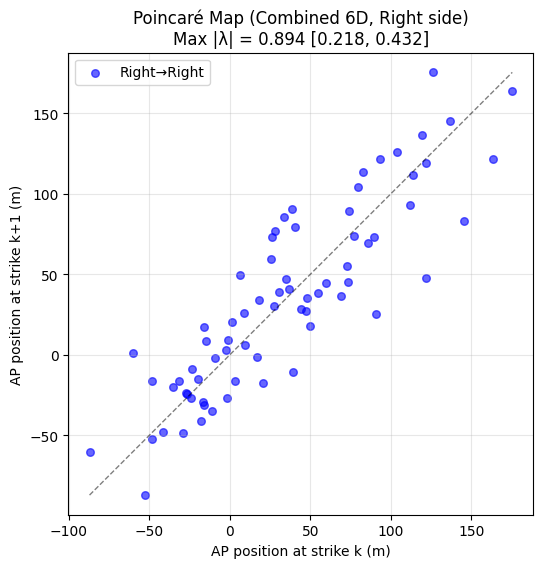


Combined (6D): λ = 0.8939 [0.2176, 0.4321]

ANALYZING STABILITY PER AXIS

COMPUTING PER-AXIS FLOQUET MULTIPLIERS

Analyzing Medio-lateral (x) axis...
Using Right-to-Right strides: 72 strides


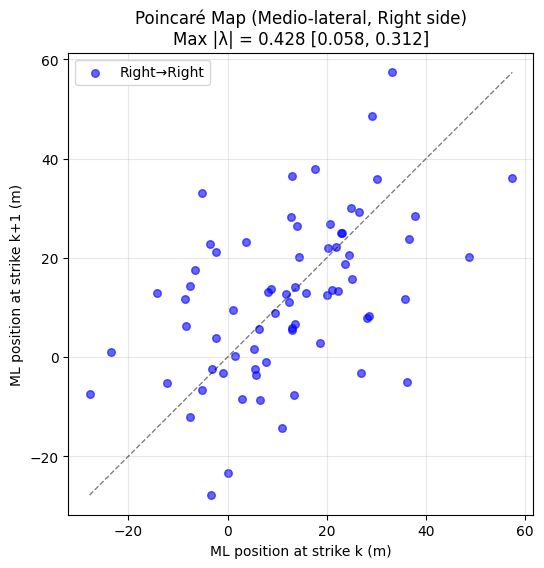


Analyzing Anterior-posterior (y) axis...
Using Right-to-Right strides: 72 strides


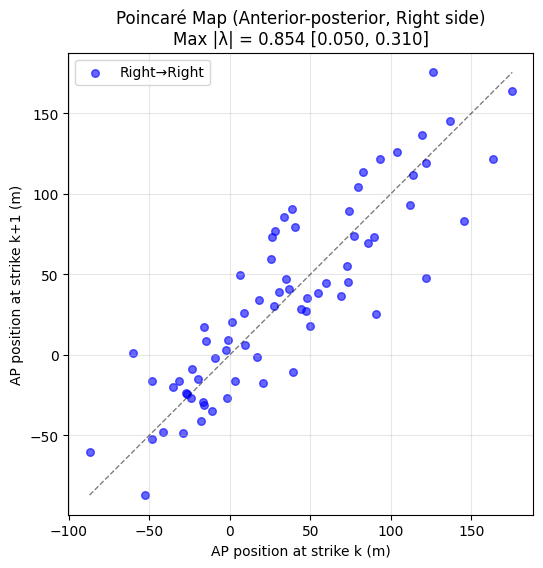


Analyzing Vertical (z) axis...
Using Right-to-Right strides: 72 strides


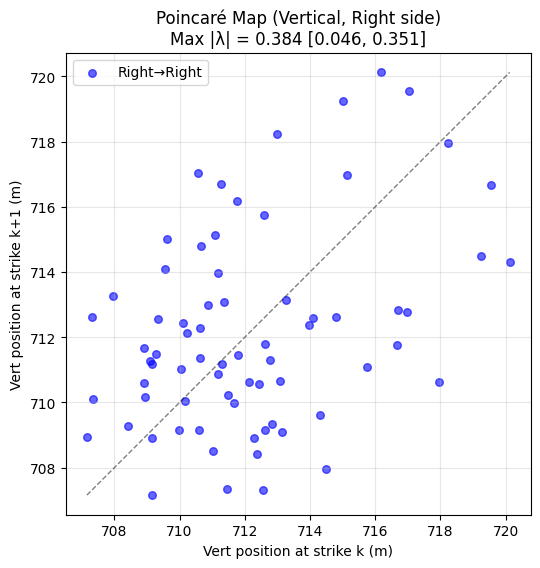


Analyzing Combined 6D state space...
Using Right-to-Right strides: 72 strides


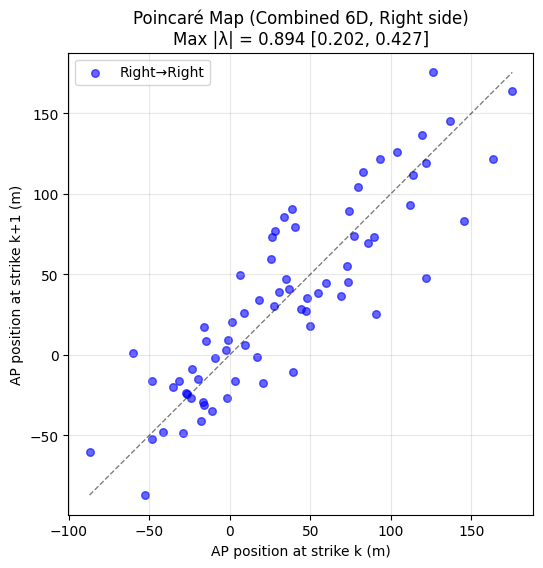


FLOQUET STABILITY SUMMARY (RIGHT FOOT)
Medio-lateral (x):      λ = 0.4276 [0.0578, 0.3123]
Anterior-posterior (y): λ = 0.8538 [0.0501, 0.3103]
Vertical (z):           λ = 0.3842 [0.0462, 0.3514]
Combined (6D):          λ = 0.8939 [0.2015, 0.4275]

Most stable direction:  Vertical (λ = 0.3842)
Least stable direction: Anterior-posterior (λ = 0.8538)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 72 strides


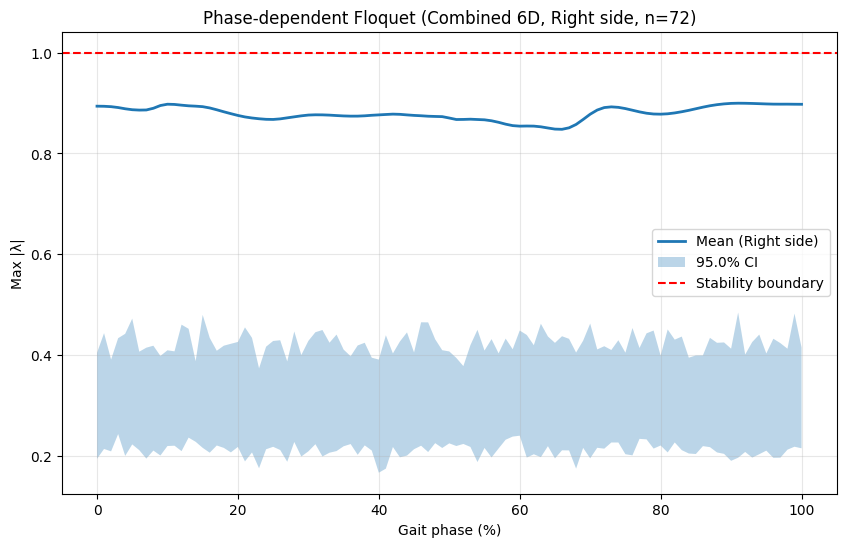

Most stable phase: 66% of gait cycle (λ = 0.8479)
Least stable phase: 91% of gait cycle (λ = 0.8998)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 72 strides


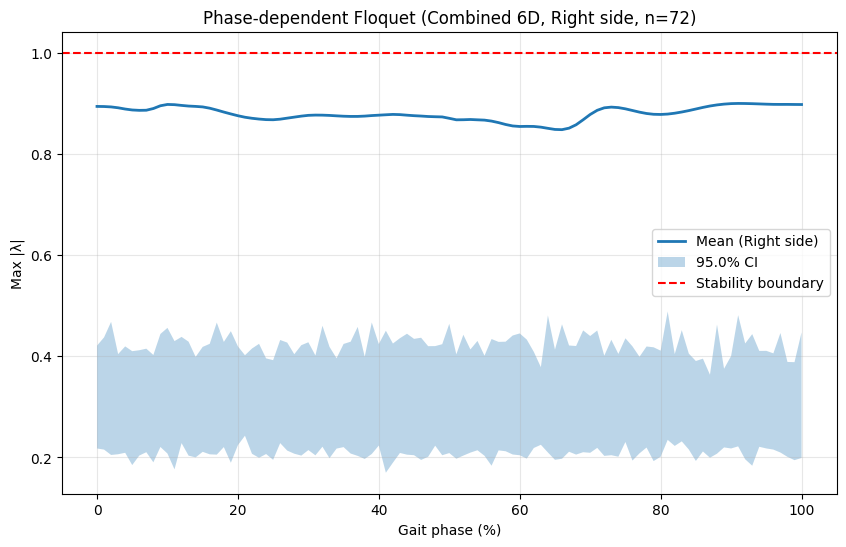

Most stable phase: 66% of gait cycle (λ = 0.8479)
Least stable phase: 91% of gait cycle (λ = 0.8998)

Phase-dependent analysis per axis...

Computing phase-dependent for Medio-lateral axis...
Using Right-to-Right strides: 72 strides


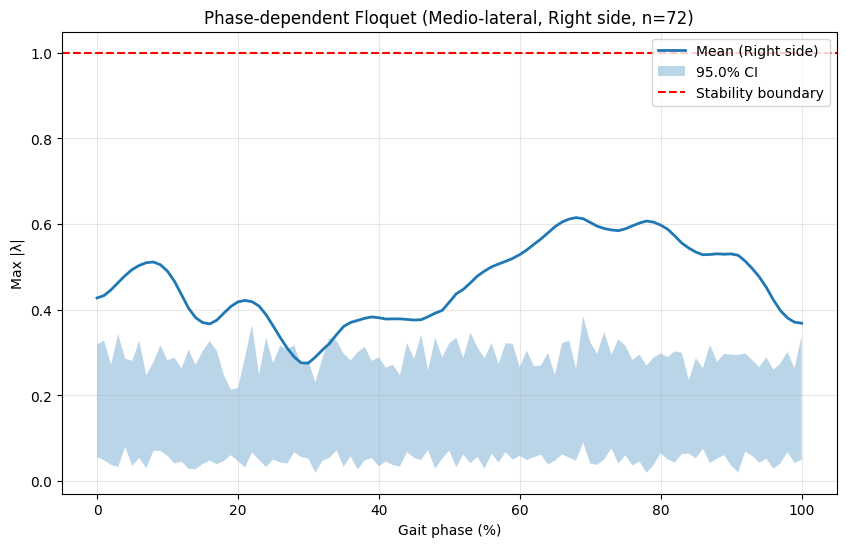

Computing phase-dependent for Anterior-posterior axis...
Using Right-to-Right strides: 72 strides


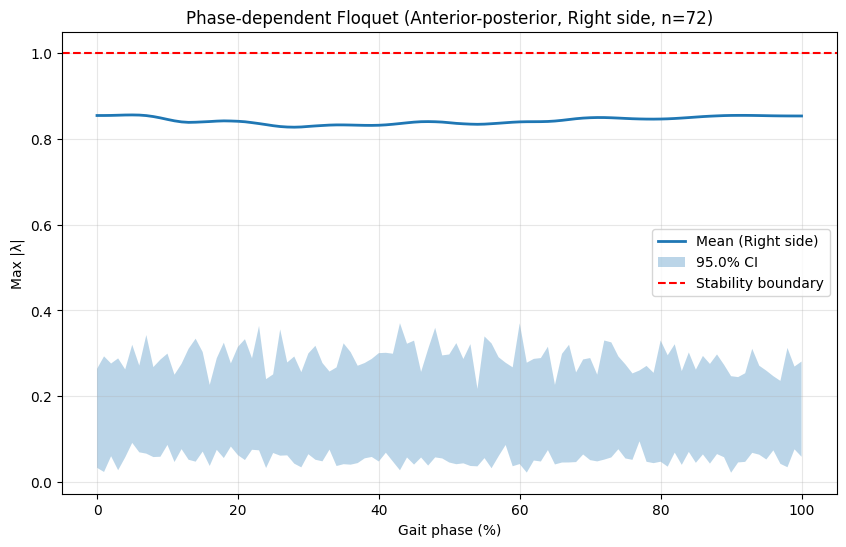

Computing phase-dependent for Vertical axis...
Using Right-to-Right strides: 72 strides


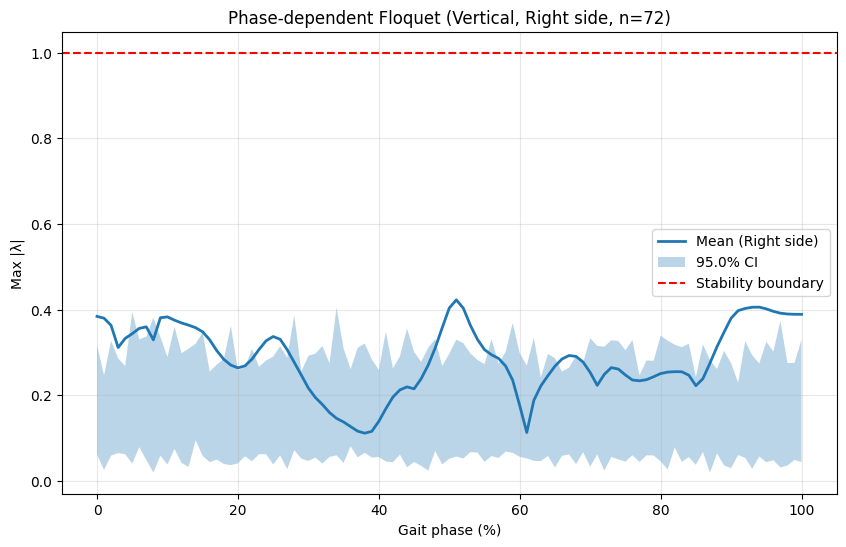

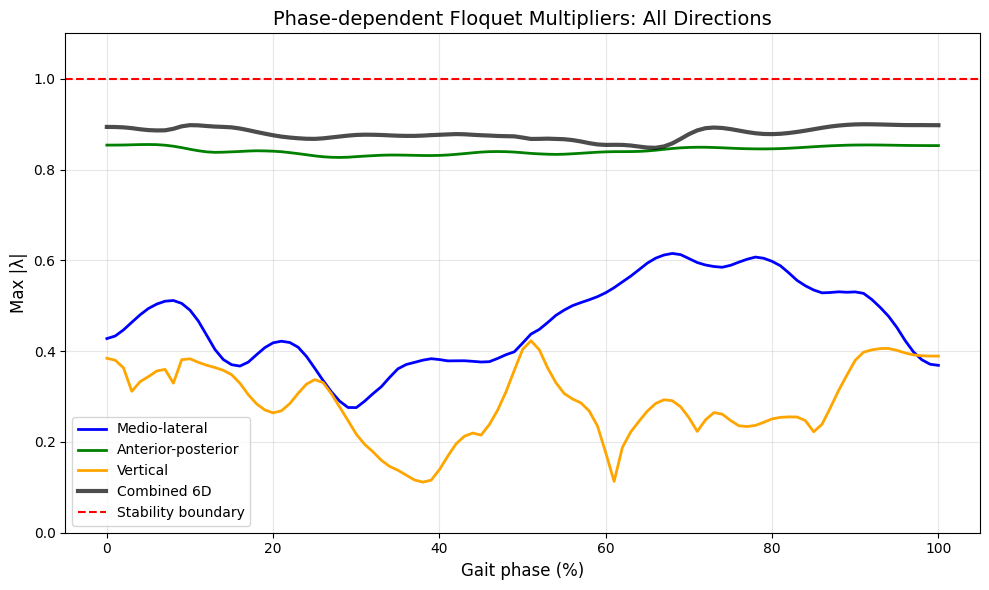


PHASE-SPECIFIC STABILITY SUMMARY
Heel strike (0%): λ = 0.8939
Loading response (10%): λ = 0.8978
Mid-stance (30%): λ = 0.8762
Terminal stance (50%): λ = 0.8704
Pre-swing (60%): λ = 0.8542
Initial swing (73%): λ = 0.8925
Mid-swing (87%): λ = 0.8947
Terminal swing (100%): λ = 0.8976

Extracting normalized trajectories for limit cycle analysis...

Extracting 72 Right-to-Right strides
Extracted data shape: 72 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


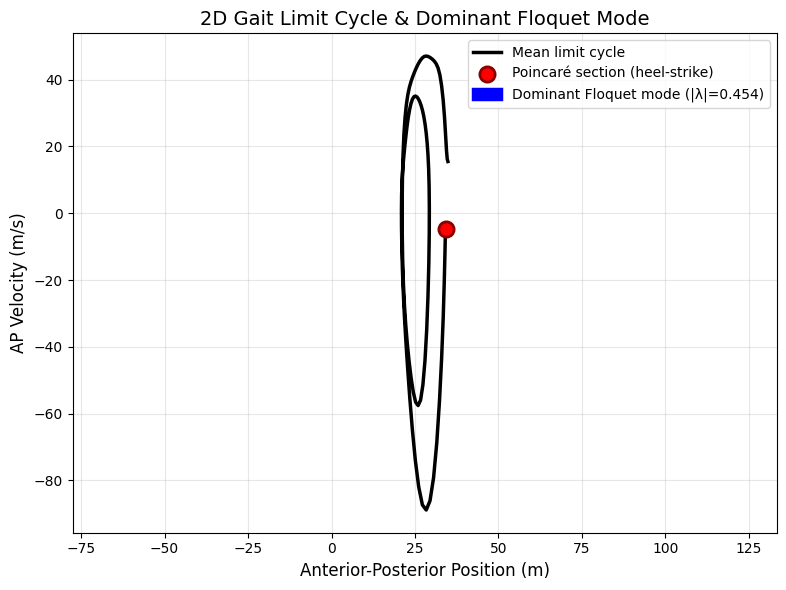


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.4541
- Eigenvector direction in (y, ẏ): [0.076, -0.066]


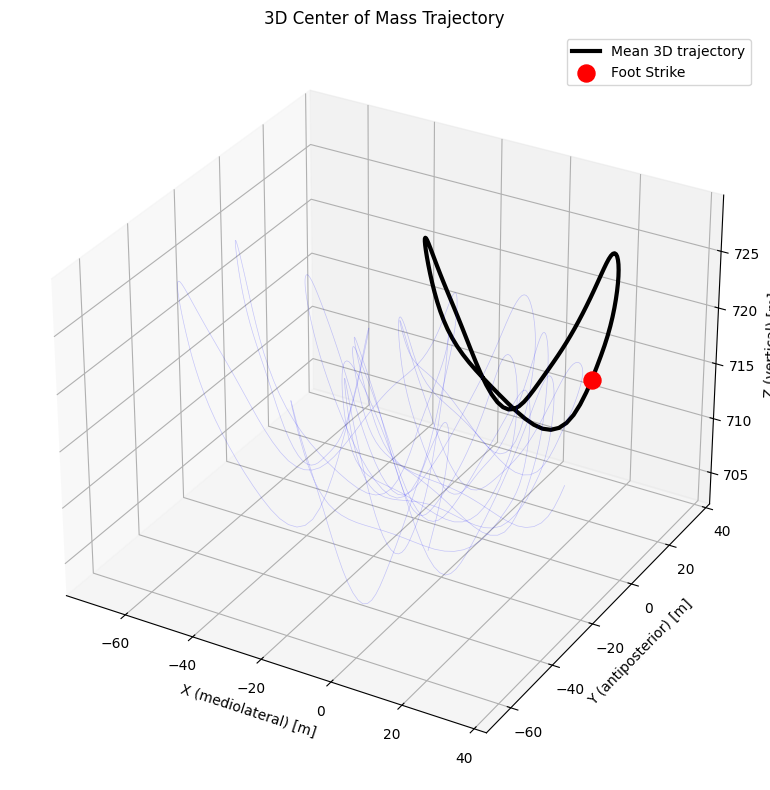

In [24]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events

def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # Load the data
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "04" /  "markers.nc"
    events_path = cwd.parent  / ".." / "data" / "PBT" / "Elderly" / "04" /  "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds = xr.open_dataset(data_path)
    df_all = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time = SKIP_SAMPLES / fs

    # Get foot strike events
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = 150.0,first_n.time.iloc[-1]
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (all {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 1) First, run a simple combined analysis to check everything works
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running combined 6D analysis first...")
    print("="*60)
    
    combined_result = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=['x', 'y', 'z'],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=100,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    print(f"\nCombined (6D): λ = {combined_result['max_floquet']:.4f} [{combined_result['confidence_interval'][0]:.4f}, {combined_result['confidence_interval'][1]:.4f}]")
    
    # ——————————————————————————————
    # 2) Now compute per-axis if you have the function defined
    # ——————————————————————————————
    if 'compute_floquet_per_axis' in globals():
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS")
        print("="*60)
        
        axis_results = compute_floquet_per_axis(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=False,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=100,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        # Display summary
        print("\n" + "="*60)
        print("FLOQUET STABILITY SUMMARY (RIGHT FOOT)")
        print("="*60)
        print(f"Medio-lateral (x):      λ = {axis_results['x']['max_floquet']:.4f} [{axis_results['x']['confidence_interval'][0]:.4f}, {axis_results['x']['confidence_interval'][1]:.4f}]")
        print(f"Anterior-posterior (y): λ = {axis_results['y']['max_floquet']:.4f} [{axis_results['y']['confidence_interval'][0]:.4f}, {axis_results['y']['confidence_interval'][1]:.4f}]")
        print(f"Vertical (z):           λ = {axis_results['z']['max_floquet']:.4f} [{axis_results['z']['confidence_interval'][0]:.4f}, {axis_results['z']['confidence_interval'][1]:.4f}]")
        print(f"Combined (6D):          λ = {axis_results['combined']['max_floquet']:.4f} [{axis_results['combined']['confidence_interval'][0]:.4f}, {axis_results['combined']['confidence_interval'][1]:.4f}]")
        
        # Identify most/least stable directions
        axis_values = {
            'Medio-lateral': axis_results['x']['max_floquet'],
            'Anterior-posterior': axis_results['y']['max_floquet'],
            'Vertical': axis_results['z']['max_floquet']
        }
        
        most_stable_axis = min(axis_values, key=axis_values.get)
        least_stable_axis = max(axis_values, key=axis_values.get)
        
        print(f"\nMost stable direction:  {most_stable_axis} (λ = {axis_values[most_stable_axis]:.4f})")
        print(f"Least stable direction: {least_stable_axis} (λ = {axis_values[least_stable_axis]:.4f})")
    else:
        # If compute_floquet_per_axis is not defined, compute each axis manually
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS (Manual)")
        print("="*60)
        
        axis_results = {}
        
        # Compute for each axis
        for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
            print(f"\nAnalyzing {name} ({axis}) axis...")
            axis_result = compute_floquet_from_events(
                com_da=com_window,
                events_df=df_window,
                channel="COM",
                axes=[axis],  # Single axis only
                normalization_points=101,
                rcond=1e-6,
                phase_dependent=False,
                plot_spectrum=False,
                use_same_side=True,
                force_side='Right',
                trim_cycles=0,
                bootstrap_n=100,
                bootstrap_ci=95.0,
                lowpass_cutoff=8.0,
                min_cycles_required=150
            )
            axis_results[axis] = axis_result
            print(f"{name}: λ = {axis_result['max_floquet']:.4f} [{axis_result['confidence_interval'][0]:.4f}, {axis_result['confidence_interval'][1]:.4f}]")
        
        axis_results['combined'] = combined_result



    # ——————————————————————————————
    # 4) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,  # Enable phase-dependent
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,  # Fewer iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    # The function automatically plots, but let's also create a custom plot
    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']
    ci_low, ci_high = phase_results['confidence_interval']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 1) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 2) Phase-dependent for each axis separately
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Phase-dependent analysis per axis...")
    print("="*60 + "\n")
    
    axis_phase_results = {}
    
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        print(f"Computing phase-dependent for {name} axis...")
        
        phase_result = compute_floquet_from_events(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            axes=[axis],
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=True,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=30,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        axis_phase_results[axis] = phase_result

    # ——————————————————————————————
    # 3) Create comparison plot of all axes on one graph
    # ——————————————————————————————
    plt.figure(figsize=(10, 6))
    
    # Plot each axis
    colors = {'x': 'blue', 'y': 'green', 'z': 'orange'}
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        plt.plot(phases, axis_phase_results[axis]['max_floquet'], 
                color=colors[axis], linewidth=2, label=name)
    
    # Add combined
    plt.plot(phases, phase_results['max_floquet'], 'k-', 
            linewidth=3, label='Combined 6D', alpha=0.7)
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
    plt.xlabel('Gait phase (%)', fontsize=12)
    plt.ylabel('Max |λ|', fontsize=12)
    plt.title('Phase-dependent Floquet Multipliers: All Directions', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    # ——————————————————————————————
    # 4) Print phase-specific statistics
    # ——————————————————————————————
    print("\n" + "="*60)
    print("PHASE-SPECIFIC STABILITY SUMMARY")
    print("="*60)
    
    # Typical gait events
    gait_events = {
        0: "Heel strike",
        10: "Loading response", 
        30: "Mid-stance",
        50: "Terminal stance",
        60: "Pre-swing",
        73: "Initial swing",
        87: "Mid-swing",
        100: "Terminal swing"
    }
    
    for phase, event in gait_events.items():
        if phase < len(phase_results['max_floquet']):
            print(f"{event} ({phase}%): λ = {phase_results['max_floquet'][phase]:.4f}")

        
    # ——————————————————————————————
    # 3) Extract data for limit cycle visualization
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,
        side_used='Right',
        trim_cycles=0,
        lowpass_cutoff=8.0,
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # Plot the 2D limit cycle
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

# Patient 05

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 10.59s to 120.00s (all 214 R_FS)
Using 201 foot‐strike events for Floquet segmentation

Running combined 6D analysis first...
Using Right-to-Right strides: 100 strides


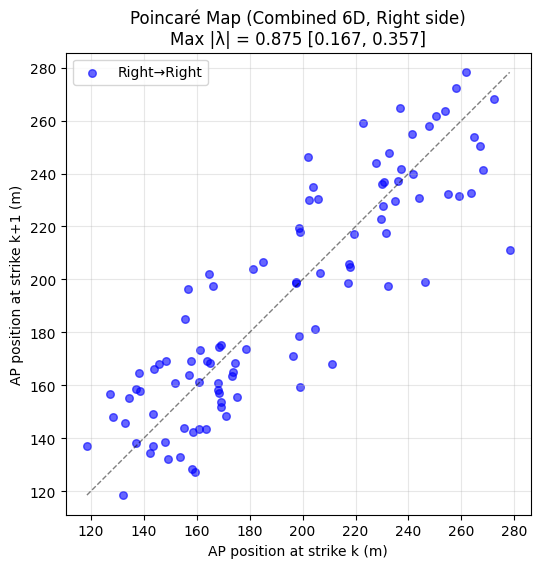


Combined (6D): λ = 0.8752 [0.1674, 0.3574]

ANALYZING STABILITY PER AXIS

COMPUTING PER-AXIS FLOQUET MULTIPLIERS

Analyzing Medio-lateral (x) axis...
Using Right-to-Right strides: 100 strides


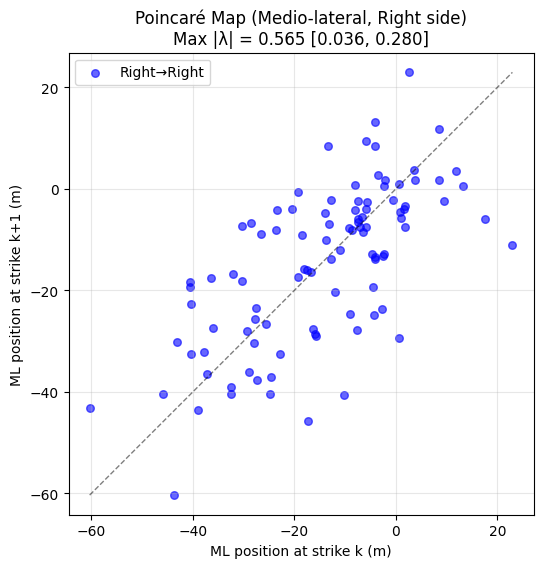


Analyzing Anterior-posterior (y) axis...
Using Right-to-Right strides: 100 strides


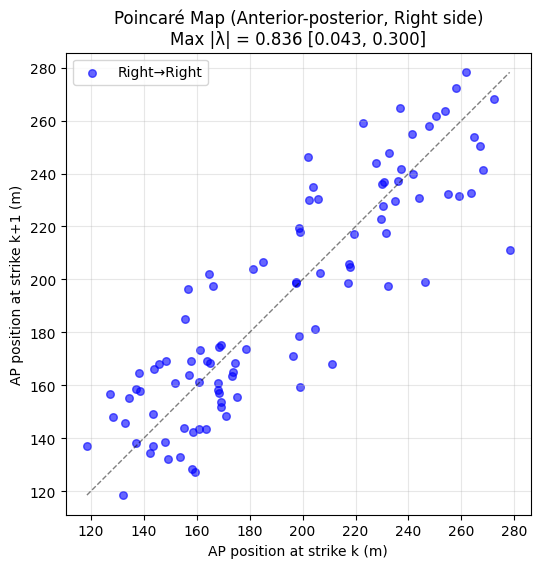


Analyzing Vertical (z) axis...
Using Right-to-Right strides: 100 strides


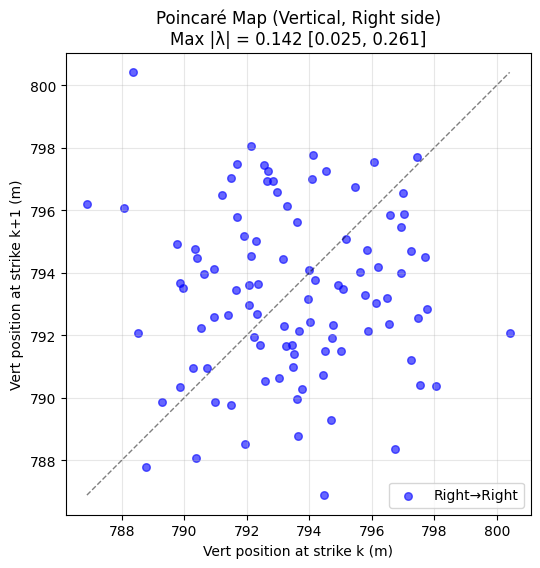


Analyzing Combined 6D state space...
Using Right-to-Right strides: 100 strides


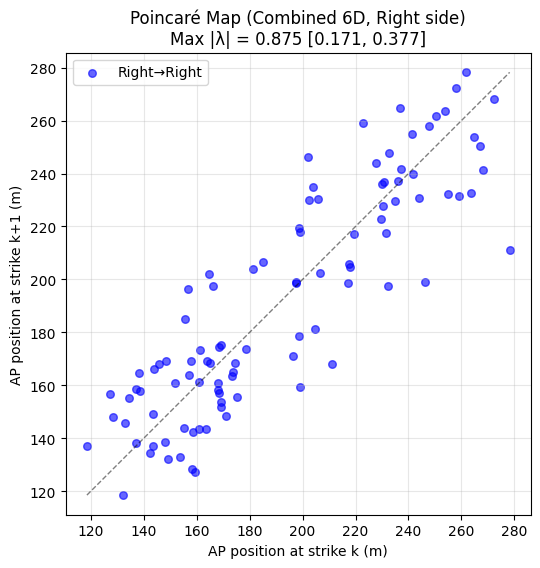


FLOQUET STABILITY SUMMARY (RIGHT FOOT)
Medio-lateral (x):      λ = 0.5650 [0.0364, 0.2801]
Anterior-posterior (y): λ = 0.8358 [0.0430, 0.2999]
Vertical (z):           λ = 0.1415 [0.0255, 0.2606]
Combined (6D):          λ = 0.8752 [0.1711, 0.3766]

Most stable direction:  Vertical (λ = 0.1415)
Least stable direction: Anterior-posterior (λ = 0.8358)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 100 strides


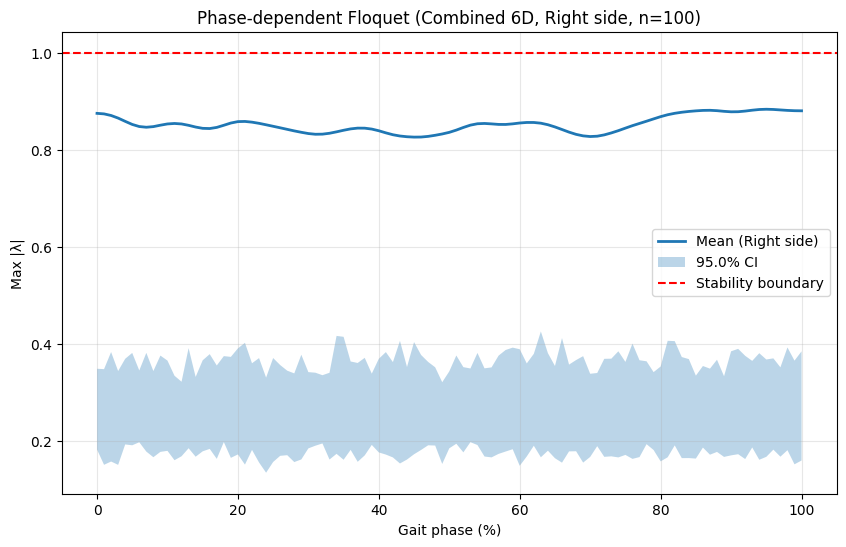

Most stable phase: 45% of gait cycle (λ = 0.8263)
Least stable phase: 95% of gait cycle (λ = 0.8836)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 100 strides


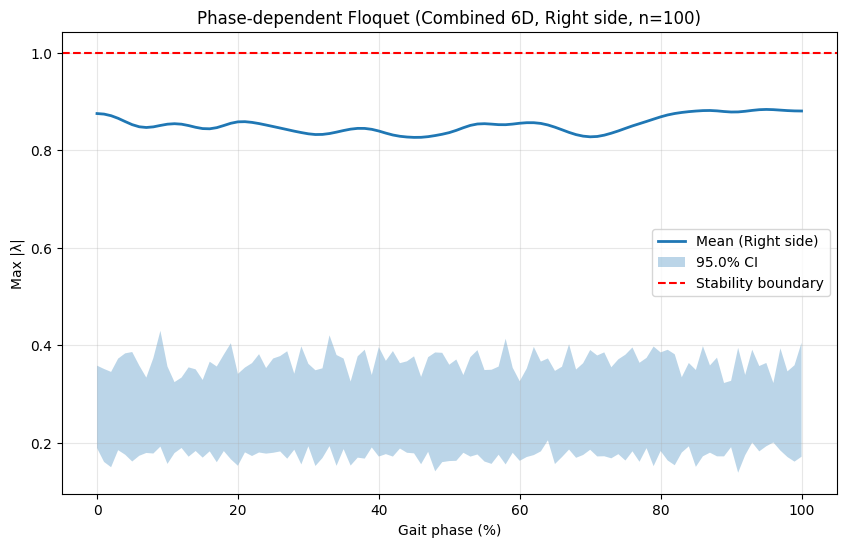

Most stable phase: 45% of gait cycle (λ = 0.8263)
Least stable phase: 95% of gait cycle (λ = 0.8836)

Phase-dependent analysis per axis...

Computing phase-dependent for Medio-lateral axis...
Using Right-to-Right strides: 100 strides


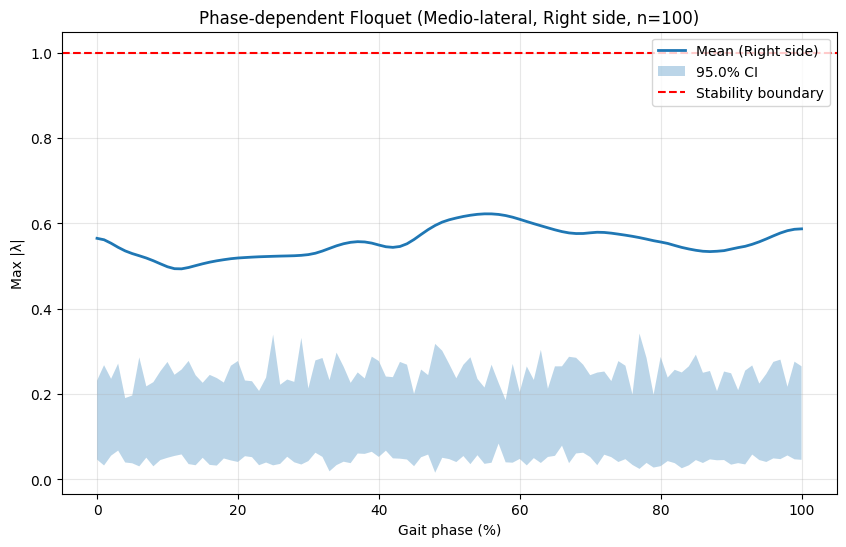

Computing phase-dependent for Anterior-posterior axis...
Using Right-to-Right strides: 100 strides


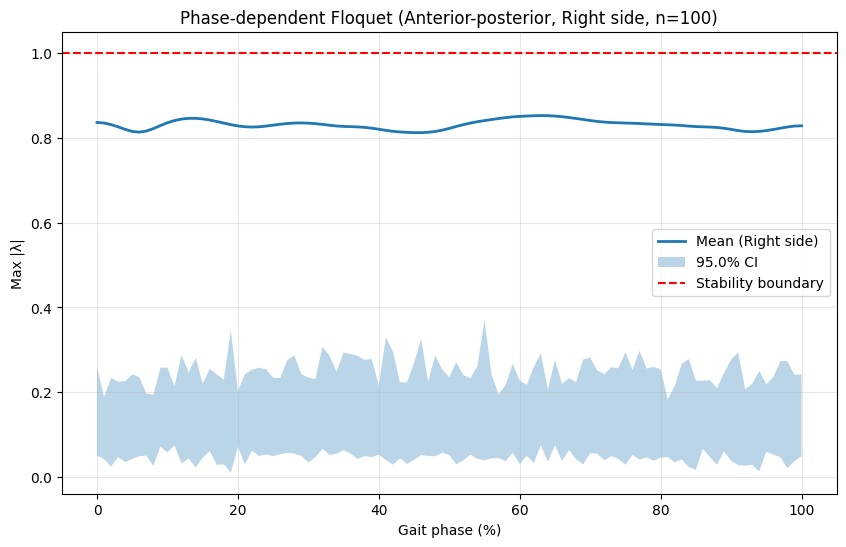

Computing phase-dependent for Vertical axis...
Using Right-to-Right strides: 100 strides


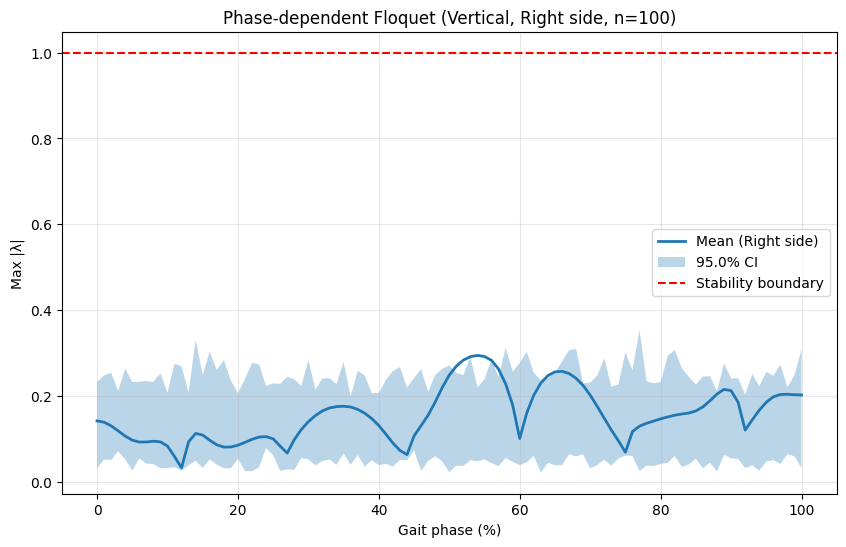

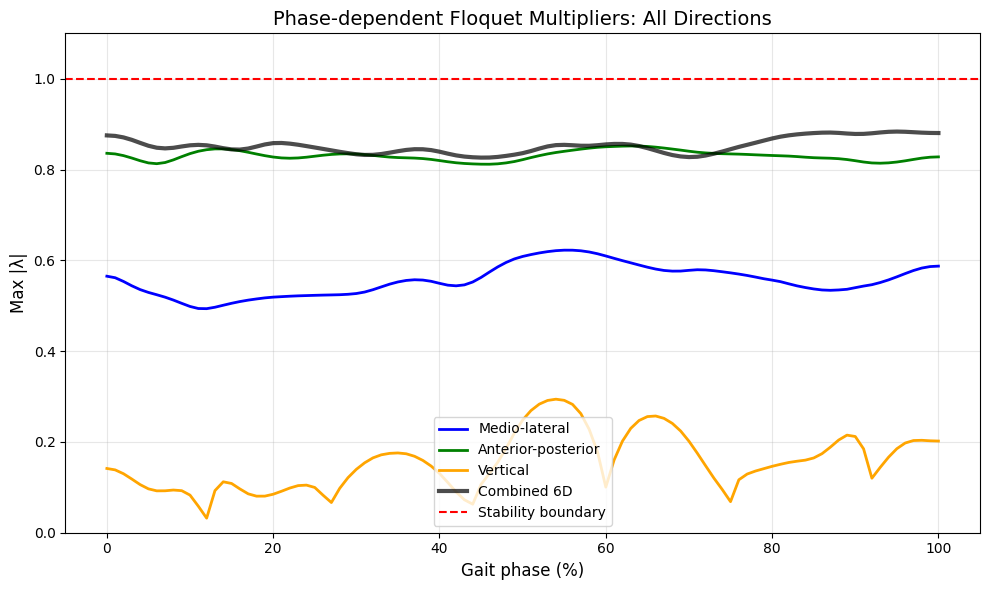


PHASE-SPECIFIC STABILITY SUMMARY
Heel strike (0%): λ = 0.8752
Loading response (10%): λ = 0.8534
Mid-stance (30%): λ = 0.8336
Terminal stance (50%): λ = 0.8361
Pre-swing (60%): λ = 0.8553
Initial swing (73%): λ = 0.8349
Mid-swing (87%): λ = 0.8815
Terminal swing (100%): λ = 0.8804

Extracting normalized trajectories for limit cycle analysis...

Extracting 100 Right-to-Right strides
Extracted data shape: 100 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


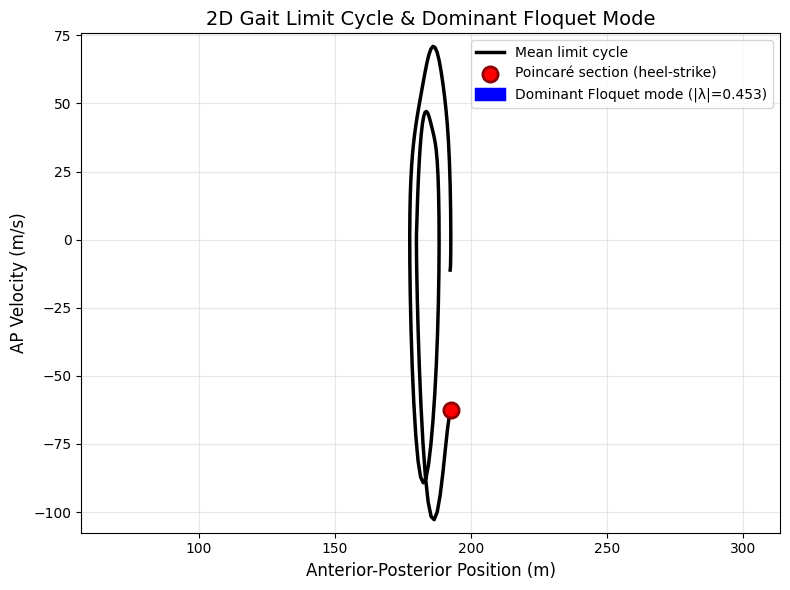


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.4527
- Eigenvector direction in (y, ẏ): [-0.095, 0.030]


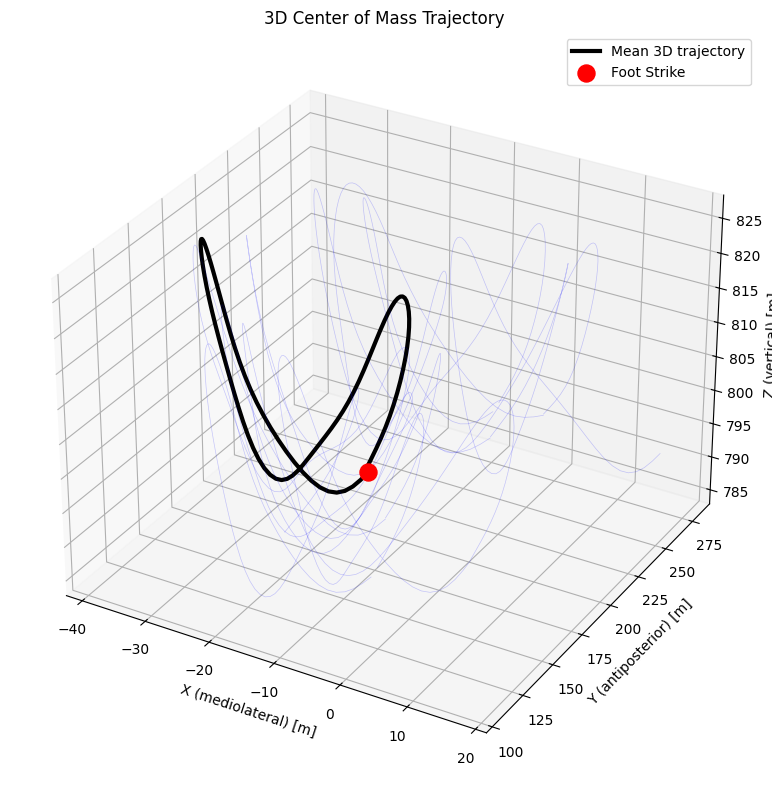

In [25]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events

def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # Load the data
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "05" /  "markers.nc"
    events_path = cwd.parent  / ".." / "data" / "PBT" / "Elderly" / "05" /  "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds = xr.open_dataset(data_path)
    df_all = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time = SKIP_SAMPLES / fs

    # Get foot strike events
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], 120.0
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (all {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 1) First, run a simple combined analysis to check everything works
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running combined 6D analysis first...")
    print("="*60)
    
    combined_result = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=['x', 'y', 'z'],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=100,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    print(f"\nCombined (6D): λ = {combined_result['max_floquet']:.4f} [{combined_result['confidence_interval'][0]:.4f}, {combined_result['confidence_interval'][1]:.4f}]")
    
    # ——————————————————————————————
    # 2) Now compute per-axis if you have the function defined
    # ——————————————————————————————
    if 'compute_floquet_per_axis' in globals():
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS")
        print("="*60)
        
        axis_results = compute_floquet_per_axis(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=False,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=100,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        # Display summary
        print("\n" + "="*60)
        print("FLOQUET STABILITY SUMMARY (RIGHT FOOT)")
        print("="*60)
        print(f"Medio-lateral (x):      λ = {axis_results['x']['max_floquet']:.4f} [{axis_results['x']['confidence_interval'][0]:.4f}, {axis_results['x']['confidence_interval'][1]:.4f}]")
        print(f"Anterior-posterior (y): λ = {axis_results['y']['max_floquet']:.4f} [{axis_results['y']['confidence_interval'][0]:.4f}, {axis_results['y']['confidence_interval'][1]:.4f}]")
        print(f"Vertical (z):           λ = {axis_results['z']['max_floquet']:.4f} [{axis_results['z']['confidence_interval'][0]:.4f}, {axis_results['z']['confidence_interval'][1]:.4f}]")
        print(f"Combined (6D):          λ = {axis_results['combined']['max_floquet']:.4f} [{axis_results['combined']['confidence_interval'][0]:.4f}, {axis_results['combined']['confidence_interval'][1]:.4f}]")
        
        # Identify most/least stable directions
        axis_values = {
            'Medio-lateral': axis_results['x']['max_floquet'],
            'Anterior-posterior': axis_results['y']['max_floquet'],
            'Vertical': axis_results['z']['max_floquet']
        }
        
        most_stable_axis = min(axis_values, key=axis_values.get)
        least_stable_axis = max(axis_values, key=axis_values.get)
        
        print(f"\nMost stable direction:  {most_stable_axis} (λ = {axis_values[most_stable_axis]:.4f})")
        print(f"Least stable direction: {least_stable_axis} (λ = {axis_values[least_stable_axis]:.4f})")
    else:
        # If compute_floquet_per_axis is not defined, compute each axis manually
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS (Manual)")
        print("="*60)
        
        axis_results = {}
        
        # Compute for each axis
        for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
            print(f"\nAnalyzing {name} ({axis}) axis...")
            axis_result = compute_floquet_from_events(
                com_da=com_window,
                events_df=df_window,
                channel="COM",
                axes=[axis],  # Single axis only
                normalization_points=101,
                rcond=1e-6,
                phase_dependent=False,
                plot_spectrum=False,
                use_same_side=True,
                force_side='Right',
                trim_cycles=0,
                bootstrap_n=100,
                bootstrap_ci=95.0,
                lowpass_cutoff=8.0,
                min_cycles_required=150
            )
            axis_results[axis] = axis_result
            print(f"{name}: λ = {axis_result['max_floquet']:.4f} [{axis_result['confidence_interval'][0]:.4f}, {axis_result['confidence_interval'][1]:.4f}]")
        
        axis_results['combined'] = combined_result



    # ——————————————————————————————
    # 4) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,  # Enable phase-dependent
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,  # Fewer iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    # The function automatically plots, but let's also create a custom plot
    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']
    ci_low, ci_high = phase_results['confidence_interval']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 1) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 2) Phase-dependent for each axis separately
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Phase-dependent analysis per axis...")
    print("="*60 + "\n")
    
    axis_phase_results = {}
    
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        print(f"Computing phase-dependent for {name} axis...")
        
        phase_result = compute_floquet_from_events(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            axes=[axis],
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=True,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=30,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        axis_phase_results[axis] = phase_result

    # ——————————————————————————————
    # 3) Create comparison plot of all axes on one graph
    # ——————————————————————————————
    plt.figure(figsize=(10, 6))
    
    # Plot each axis
    colors = {'x': 'blue', 'y': 'green', 'z': 'orange'}
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        plt.plot(phases, axis_phase_results[axis]['max_floquet'], 
                color=colors[axis], linewidth=2, label=name)
    
    # Add combined
    plt.plot(phases, phase_results['max_floquet'], 'k-', 
            linewidth=3, label='Combined 6D', alpha=0.7)
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
    plt.xlabel('Gait phase (%)', fontsize=12)
    plt.ylabel('Max |λ|', fontsize=12)
    plt.title('Phase-dependent Floquet Multipliers: All Directions', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    # ——————————————————————————————
    # 4) Print phase-specific statistics
    # ——————————————————————————————
    print("\n" + "="*60)
    print("PHASE-SPECIFIC STABILITY SUMMARY")
    print("="*60)
    
    # Typical gait events
    gait_events = {
        0: "Heel strike",
        10: "Loading response", 
        30: "Mid-stance",
        50: "Terminal stance",
        60: "Pre-swing",
        73: "Initial swing",
        87: "Mid-swing",
        100: "Terminal swing"
    }
    
    for phase, event in gait_events.items():
        if phase < len(phase_results['max_floquet']):
            print(f"{event} ({phase}%): λ = {phase_results['max_floquet'][phase]:.4f}")

        
    # ——————————————————————————————
    # 3) Extract data for limit cycle visualization
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,
        side_used='Right',
        trim_cycles=0,
        lowpass_cutoff=8.0,
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # Plot the 2D limit cycle
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

## Post

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 160.00s to 234.60s (all 214 R_FS)
Using 135 foot‐strike events for Floquet segmentation

Running combined 6D analysis first...
Using Right-to-Right strides: 66 strides


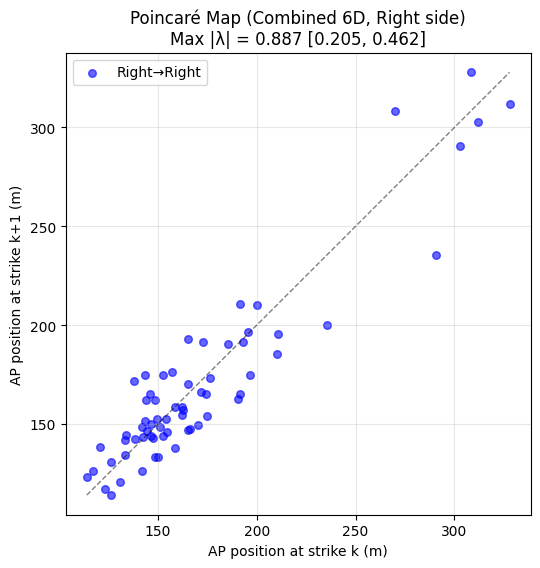


Combined (6D): λ = 0.8868 [0.2046, 0.4616]

ANALYZING STABILITY PER AXIS

COMPUTING PER-AXIS FLOQUET MULTIPLIERS

Analyzing Medio-lateral (x) axis...
Using Right-to-Right strides: 66 strides


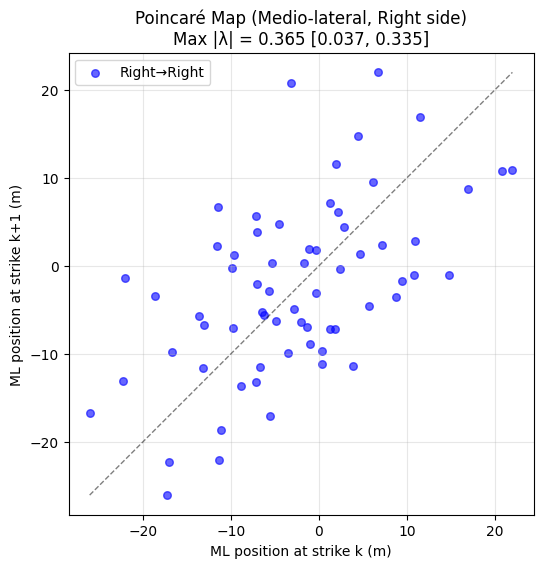


Analyzing Anterior-posterior (y) axis...
Using Right-to-Right strides: 66 strides


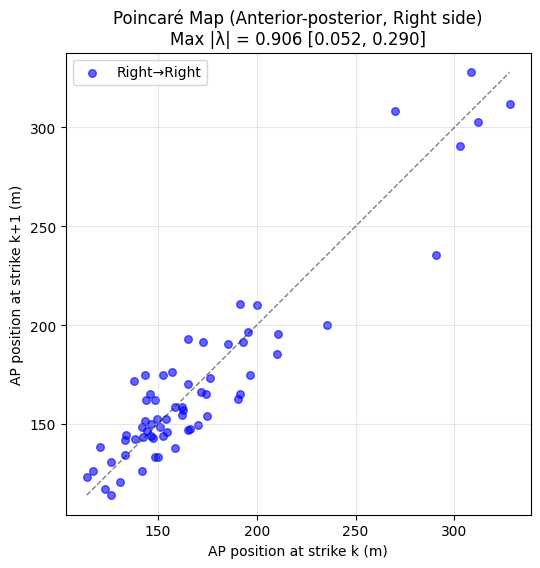


Analyzing Vertical (z) axis...
Using Right-to-Right strides: 66 strides


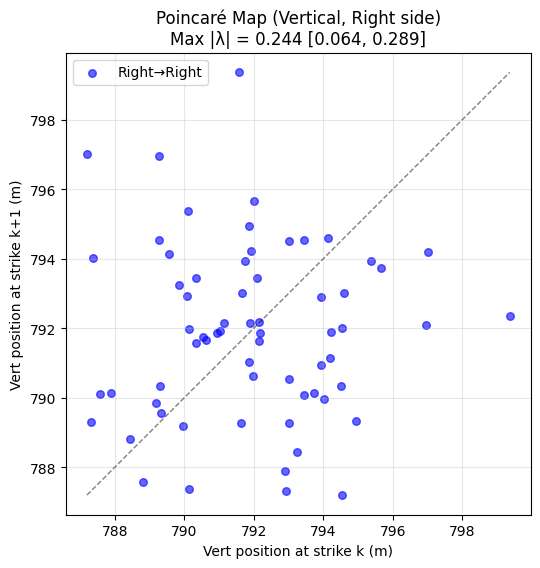


Analyzing Combined 6D state space...
Using Right-to-Right strides: 66 strides


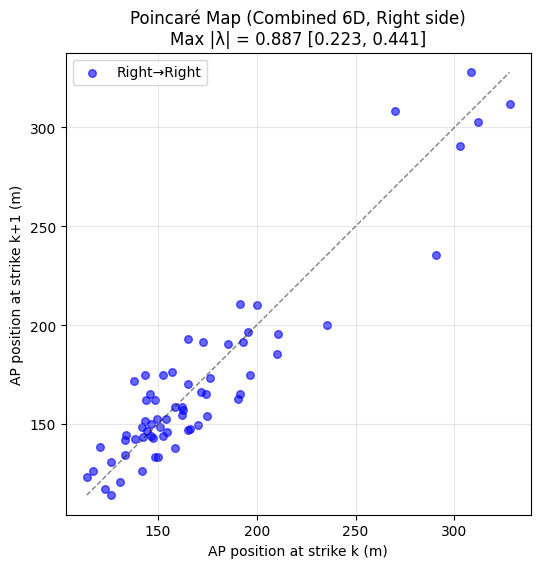


FLOQUET STABILITY SUMMARY (RIGHT FOOT)
Medio-lateral (x):      λ = 0.3654 [0.0366, 0.3349]
Anterior-posterior (y): λ = 0.9058 [0.0518, 0.2904]
Vertical (z):           λ = 0.2438 [0.0637, 0.2890]
Combined (6D):          λ = 0.8868 [0.2230, 0.4407]

Most stable direction:  Vertical (λ = 0.2438)
Least stable direction: Anterior-posterior (λ = 0.9058)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 66 strides


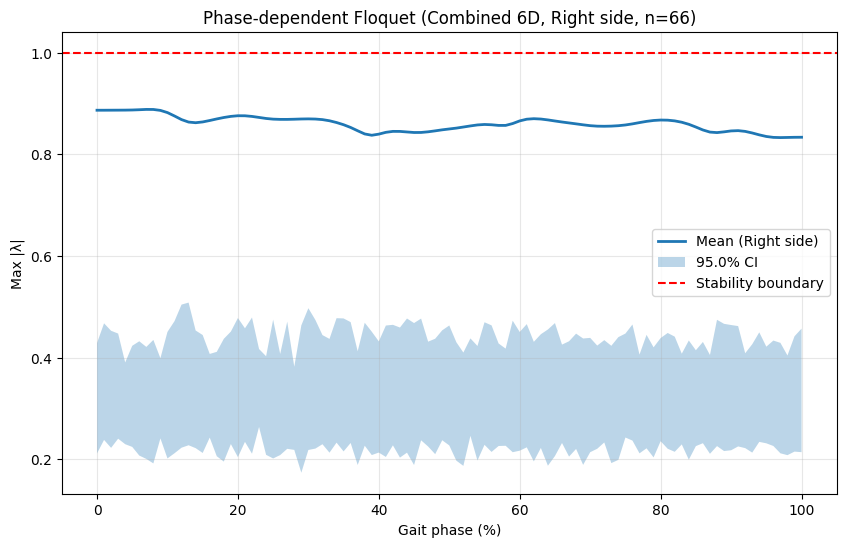

Most stable phase: 97% of gait cycle (λ = 0.8330)
Least stable phase: 7% of gait cycle (λ = 0.8884)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 66 strides


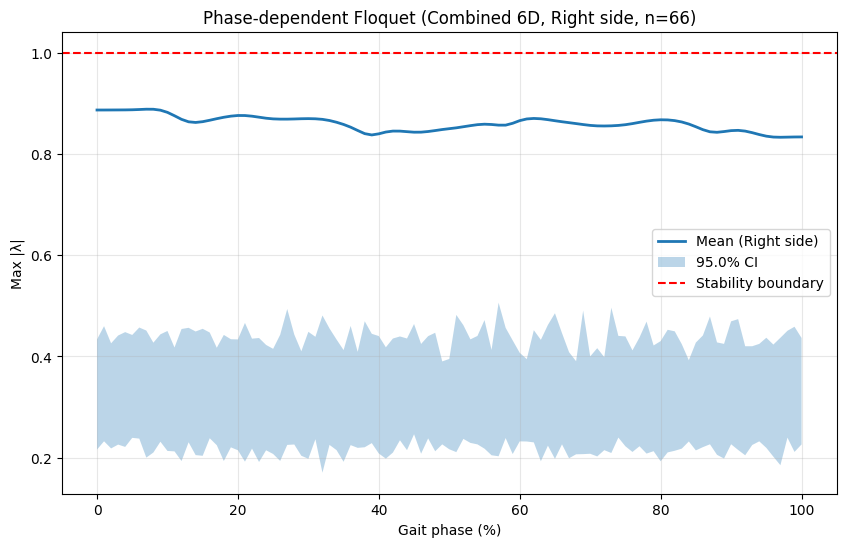

Most stable phase: 97% of gait cycle (λ = 0.8330)
Least stable phase: 7% of gait cycle (λ = 0.8884)

Phase-dependent analysis per axis...

Computing phase-dependent for Medio-lateral axis...
Using Right-to-Right strides: 66 strides


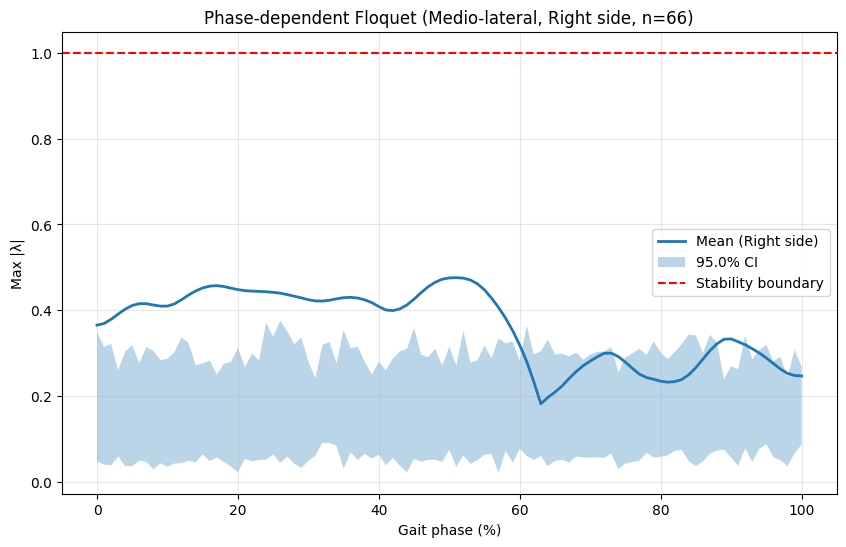

Computing phase-dependent for Anterior-posterior axis...
Using Right-to-Right strides: 66 strides


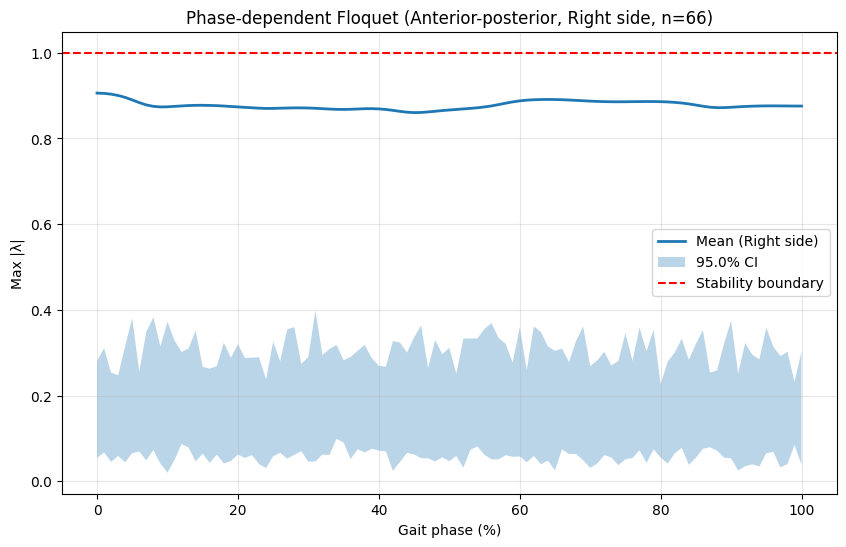

Computing phase-dependent for Vertical axis...
Using Right-to-Right strides: 66 strides


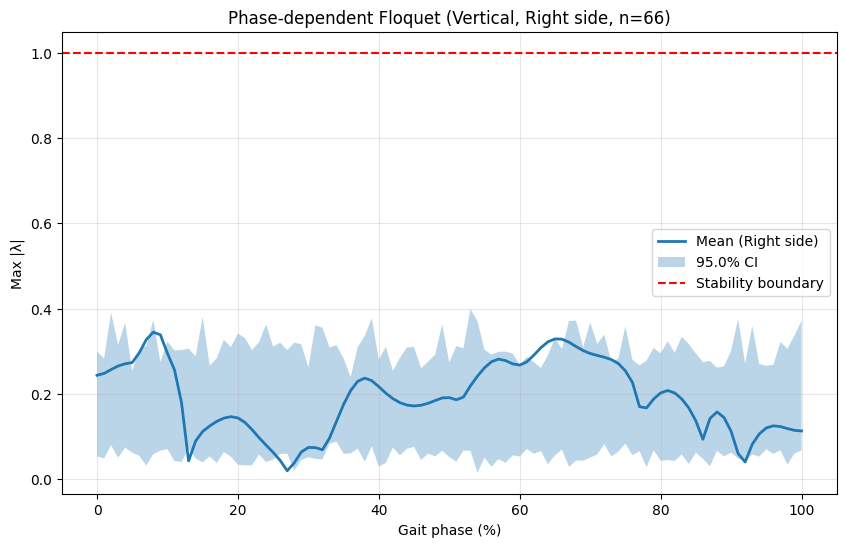

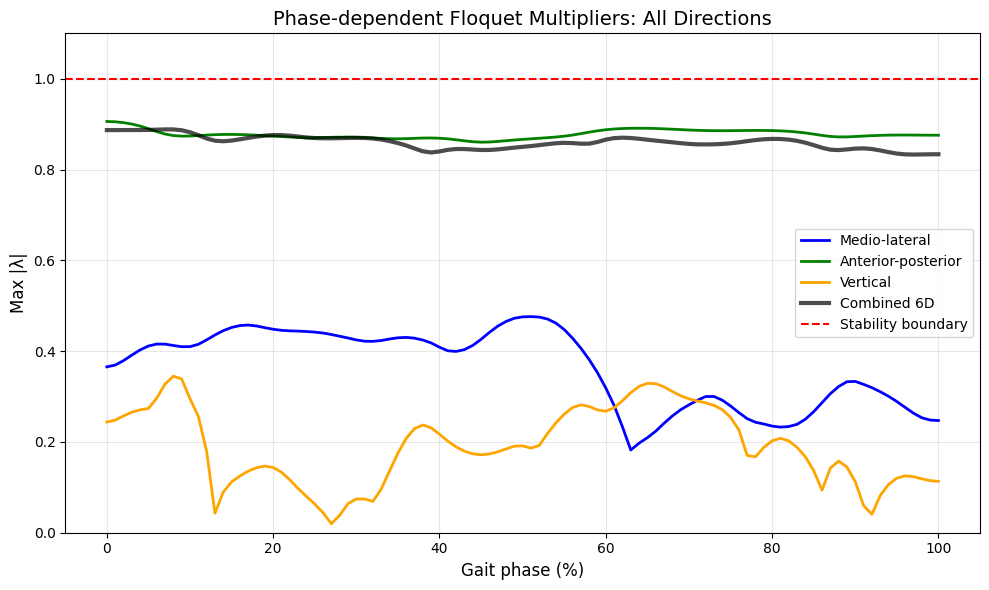


PHASE-SPECIFIC STABILITY SUMMARY
Heel strike (0%): λ = 0.8868
Loading response (10%): λ = 0.8822
Mid-stance (30%): λ = 0.8698
Terminal stance (50%): λ = 0.8500
Pre-swing (60%): λ = 0.8658
Initial swing (73%): λ = 0.8556
Mid-swing (87%): λ = 0.8438
Terminal swing (100%): λ = 0.8337

Extracting normalized trajectories for limit cycle analysis...

Extracting 66 Right-to-Right strides
Extracted data shape: 66 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


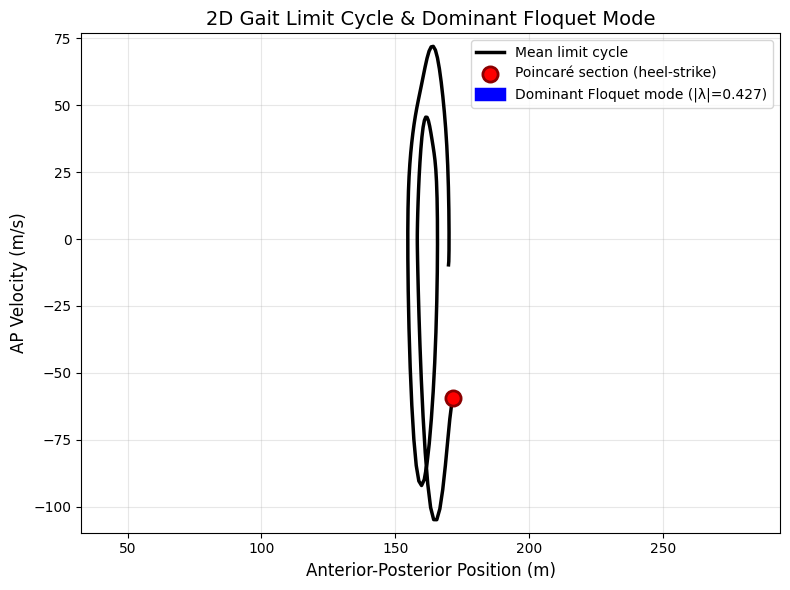


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.4270
- Eigenvector direction in (y, ẏ): [-0.012, 0.099]


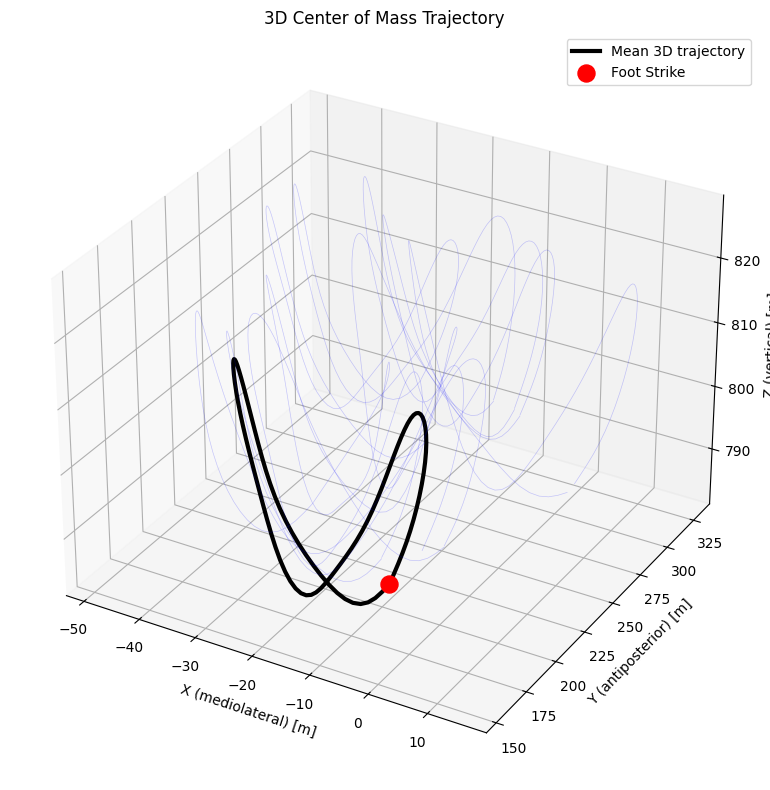

In [26]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events

def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # Load the data
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "05" /  "markers.nc"
    events_path = cwd.parent  / ".." / "data" / "PBT" / "Elderly" / "05" /  "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds = xr.open_dataset(data_path)
    df_all = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time = SKIP_SAMPLES / fs

    # Get foot strike events
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time =  160.0, first_n.time.iloc[-1] - 10.0
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (all {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 1) First, run a simple combined analysis to check everything works
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running combined 6D analysis first...")
    print("="*60)
    
    combined_result = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=['x', 'y', 'z'],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=100,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    print(f"\nCombined (6D): λ = {combined_result['max_floquet']:.4f} [{combined_result['confidence_interval'][0]:.4f}, {combined_result['confidence_interval'][1]:.4f}]")
    
    # ——————————————————————————————
    # 2) Now compute per-axis if you have the function defined
    # ——————————————————————————————
    if 'compute_floquet_per_axis' in globals():
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS")
        print("="*60)
        
        axis_results = compute_floquet_per_axis(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=False,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=100,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        # Display summary
        print("\n" + "="*60)
        print("FLOQUET STABILITY SUMMARY (RIGHT FOOT)")
        print("="*60)
        print(f"Medio-lateral (x):      λ = {axis_results['x']['max_floquet']:.4f} [{axis_results['x']['confidence_interval'][0]:.4f}, {axis_results['x']['confidence_interval'][1]:.4f}]")
        print(f"Anterior-posterior (y): λ = {axis_results['y']['max_floquet']:.4f} [{axis_results['y']['confidence_interval'][0]:.4f}, {axis_results['y']['confidence_interval'][1]:.4f}]")
        print(f"Vertical (z):           λ = {axis_results['z']['max_floquet']:.4f} [{axis_results['z']['confidence_interval'][0]:.4f}, {axis_results['z']['confidence_interval'][1]:.4f}]")
        print(f"Combined (6D):          λ = {axis_results['combined']['max_floquet']:.4f} [{axis_results['combined']['confidence_interval'][0]:.4f}, {axis_results['combined']['confidence_interval'][1]:.4f}]")
        
        # Identify most/least stable directions
        axis_values = {
            'Medio-lateral': axis_results['x']['max_floquet'],
            'Anterior-posterior': axis_results['y']['max_floquet'],
            'Vertical': axis_results['z']['max_floquet']
        }
        
        most_stable_axis = min(axis_values, key=axis_values.get)
        least_stable_axis = max(axis_values, key=axis_values.get)
        
        print(f"\nMost stable direction:  {most_stable_axis} (λ = {axis_values[most_stable_axis]:.4f})")
        print(f"Least stable direction: {least_stable_axis} (λ = {axis_values[least_stable_axis]:.4f})")
    else:
        # If compute_floquet_per_axis is not defined, compute each axis manually
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS (Manual)")
        print("="*60)
        
        axis_results = {}
        
        # Compute for each axis
        for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
            print(f"\nAnalyzing {name} ({axis}) axis...")
            axis_result = compute_floquet_from_events(
                com_da=com_window,
                events_df=df_window,
                channel="COM",
                axes=[axis],  # Single axis only
                normalization_points=101,
                rcond=1e-6,
                phase_dependent=False,
                plot_spectrum=False,
                use_same_side=True,
                force_side='Right',
                trim_cycles=0,
                bootstrap_n=100,
                bootstrap_ci=95.0,
                lowpass_cutoff=8.0,
                min_cycles_required=150
            )
            axis_results[axis] = axis_result
            print(f"{name}: λ = {axis_result['max_floquet']:.4f} [{axis_result['confidence_interval'][0]:.4f}, {axis_result['confidence_interval'][1]:.4f}]")
        
        axis_results['combined'] = combined_result



    # ——————————————————————————————
    # 4) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,  # Enable phase-dependent
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,  # Fewer iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    # The function automatically plots, but let's also create a custom plot
    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']
    ci_low, ci_high = phase_results['confidence_interval']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 1) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 2) Phase-dependent for each axis separately
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Phase-dependent analysis per axis...")
    print("="*60 + "\n")
    
    axis_phase_results = {}
    
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        print(f"Computing phase-dependent for {name} axis...")
        
        phase_result = compute_floquet_from_events(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            axes=[axis],
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=True,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=30,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        axis_phase_results[axis] = phase_result

    # ——————————————————————————————
    # 3) Create comparison plot of all axes on one graph
    # ——————————————————————————————
    plt.figure(figsize=(10, 6))
    
    # Plot each axis
    colors = {'x': 'blue', 'y': 'green', 'z': 'orange'}
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        plt.plot(phases, axis_phase_results[axis]['max_floquet'], 
                color=colors[axis], linewidth=2, label=name)
    
    # Add combined
    plt.plot(phases, phase_results['max_floquet'], 'k-', 
            linewidth=3, label='Combined 6D', alpha=0.7)
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
    plt.xlabel('Gait phase (%)', fontsize=12)
    plt.ylabel('Max |λ|', fontsize=12)
    plt.title('Phase-dependent Floquet Multipliers: All Directions', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    # ——————————————————————————————
    # 4) Print phase-specific statistics
    # ——————————————————————————————
    print("\n" + "="*60)
    print("PHASE-SPECIFIC STABILITY SUMMARY")
    print("="*60)
    
    # Typical gait events
    gait_events = {
        0: "Heel strike",
        10: "Loading response", 
        30: "Mid-stance",
        50: "Terminal stance",
        60: "Pre-swing",
        73: "Initial swing",
        87: "Mid-swing",
        100: "Terminal swing"
    }
    
    for phase, event in gait_events.items():
        if phase < len(phase_results['max_floquet']):
            print(f"{event} ({phase}%): λ = {phase_results['max_floquet'][phase]:.4f}")

        
    # ——————————————————————————————
    # 3) Extract data for limit cycle visualization
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,
        side_used='Right',
        trim_cycles=0,
        lowpass_cutoff=8.0,
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # Plot the 2D limit cycle
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

# Patient 08

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 10.59s to 120.00s (all 299 R_FS)
Using 207 foot‐strike events for Floquet segmentation

Running combined 6D analysis first...
Using Right-to-Right strides: 103 strides


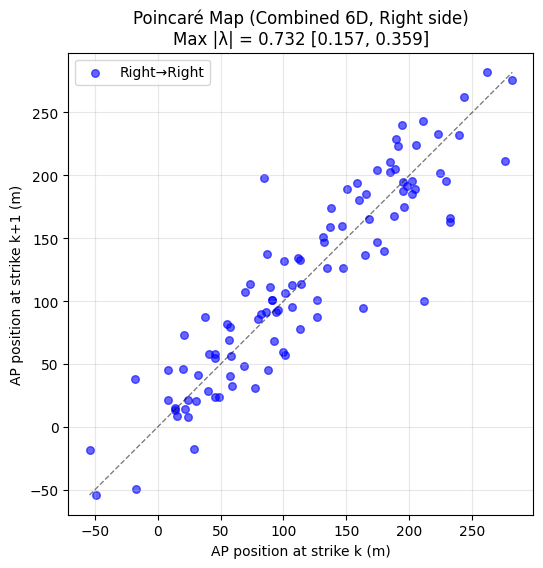


Combined (6D): λ = 0.7317 [0.1574, 0.3590]

ANALYZING STABILITY PER AXIS

COMPUTING PER-AXIS FLOQUET MULTIPLIERS

Analyzing Medio-lateral (x) axis...
Using Right-to-Right strides: 103 strides


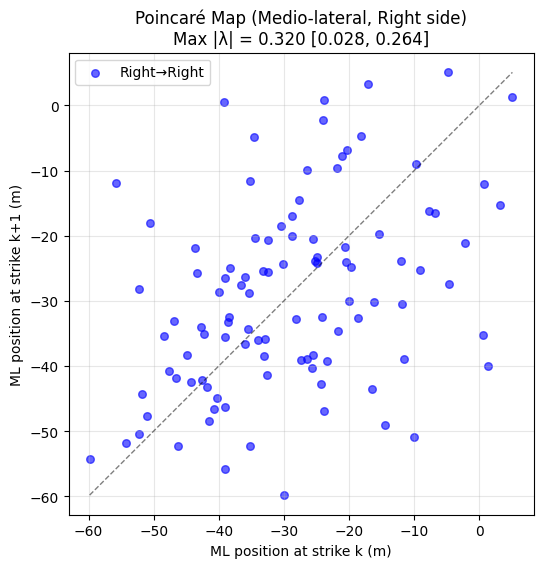


Analyzing Anterior-posterior (y) axis...
Using Right-to-Right strides: 103 strides


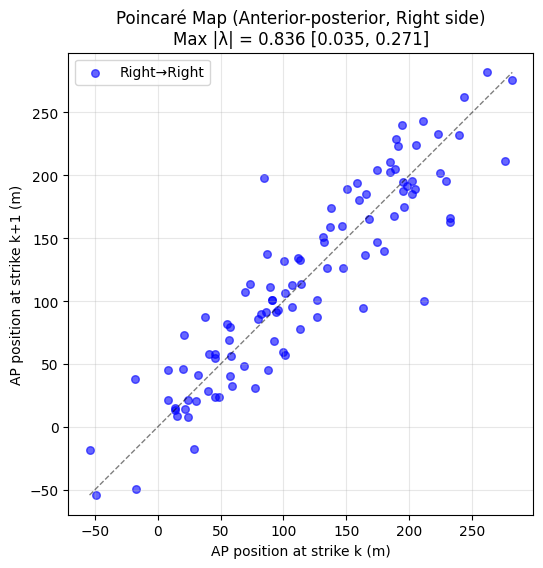


Analyzing Vertical (z) axis...
Using Right-to-Right strides: 103 strides


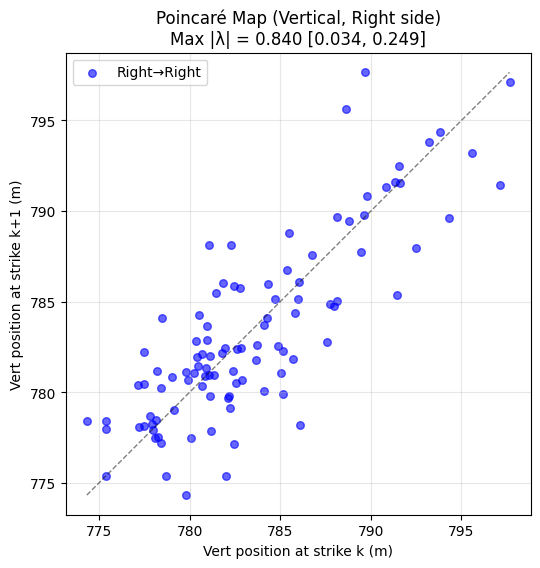


Analyzing Combined 6D state space...
Using Right-to-Right strides: 103 strides


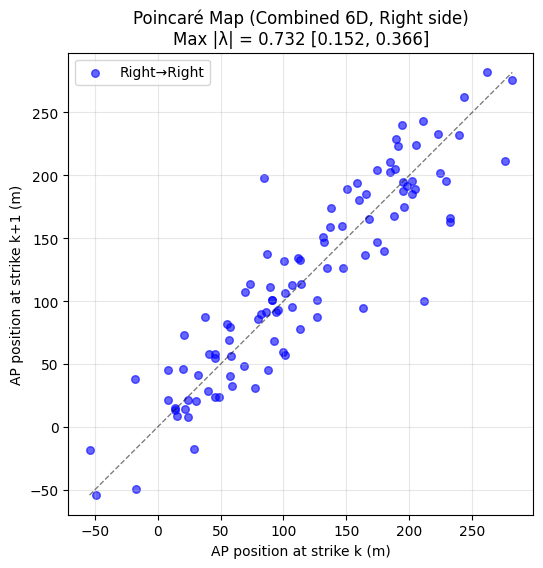


FLOQUET STABILITY SUMMARY (RIGHT FOOT)
Medio-lateral (x):      λ = 0.3197 [0.0281, 0.2639]
Anterior-posterior (y): λ = 0.8356 [0.0348, 0.2706]
Vertical (z):           λ = 0.8402 [0.0337, 0.2490]
Combined (6D):          λ = 0.7317 [0.1523, 0.3663]

Most stable direction:  Medio-lateral (λ = 0.3197)
Least stable direction: Vertical (λ = 0.8402)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 103 strides


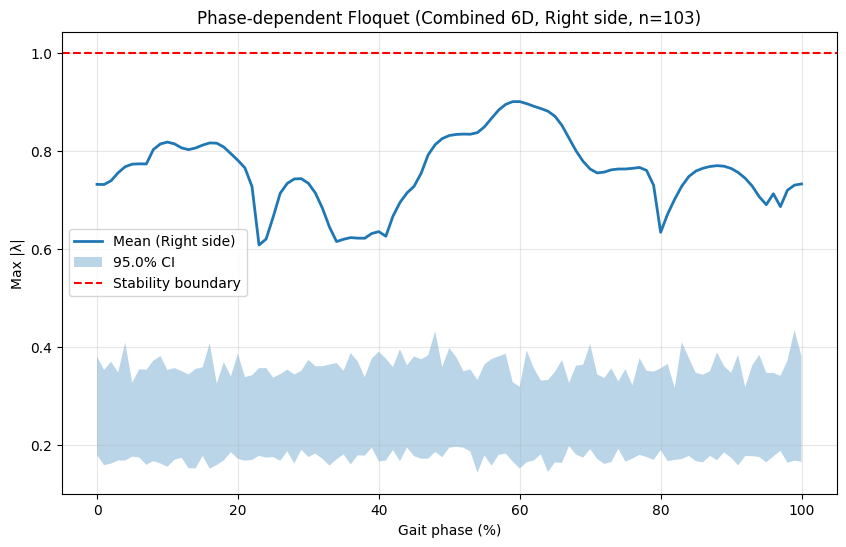

Most stable phase: 23% of gait cycle (λ = 0.6082)
Least stable phase: 60% of gait cycle (λ = 0.9004)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 103 strides


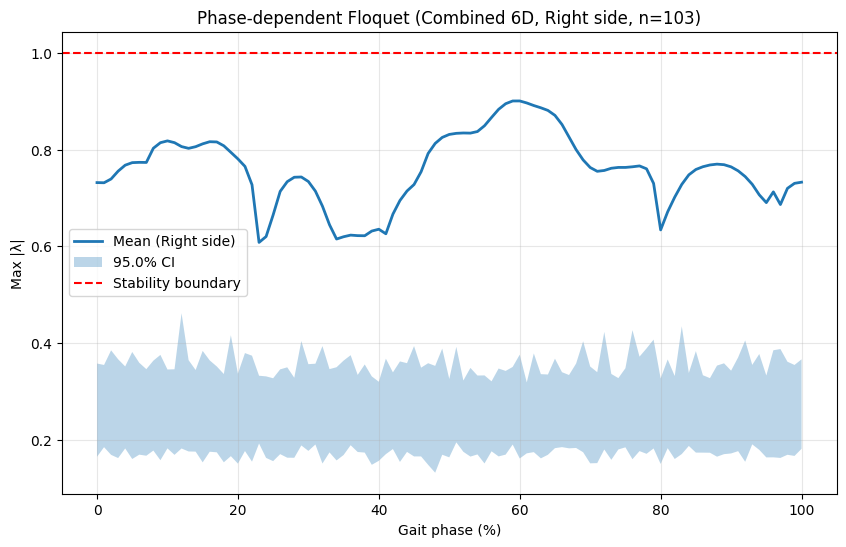

Most stable phase: 23% of gait cycle (λ = 0.6082)
Least stable phase: 60% of gait cycle (λ = 0.9004)

Phase-dependent analysis per axis...

Computing phase-dependent for Medio-lateral axis...
Using Right-to-Right strides: 103 strides


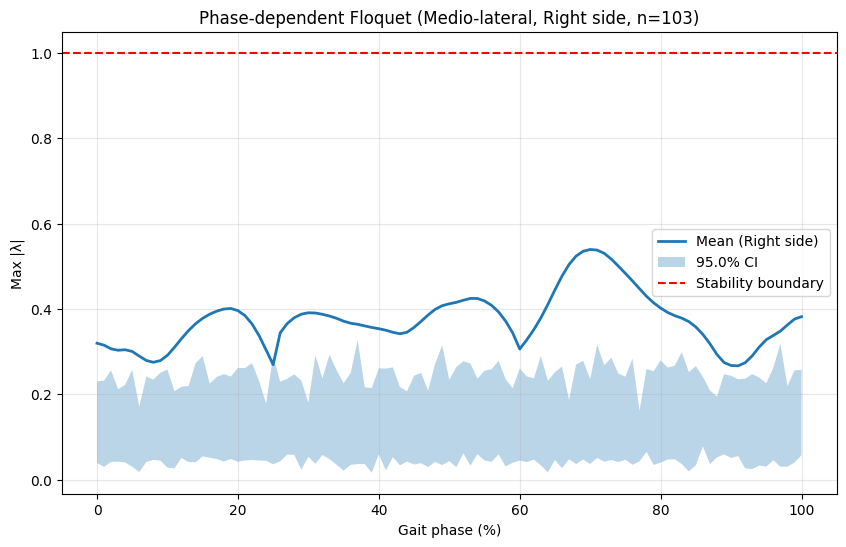

Computing phase-dependent for Anterior-posterior axis...
Using Right-to-Right strides: 103 strides


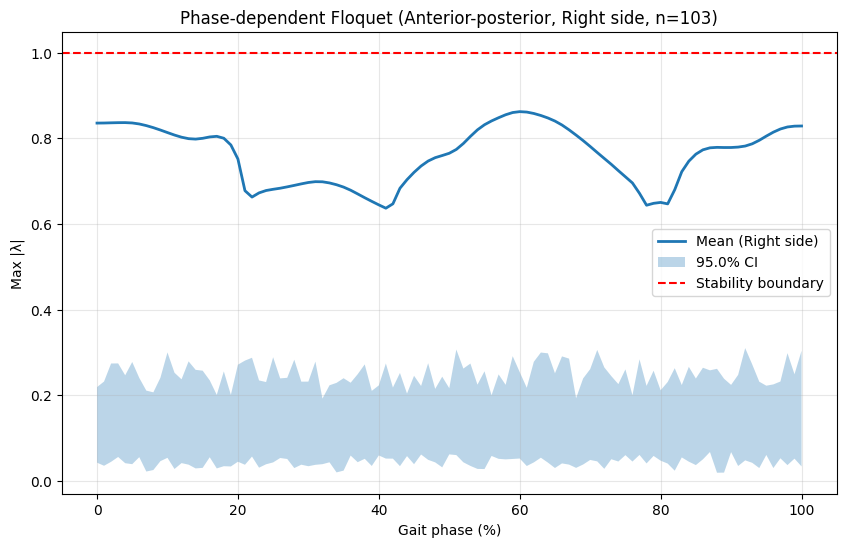

Computing phase-dependent for Vertical axis...
Using Right-to-Right strides: 103 strides


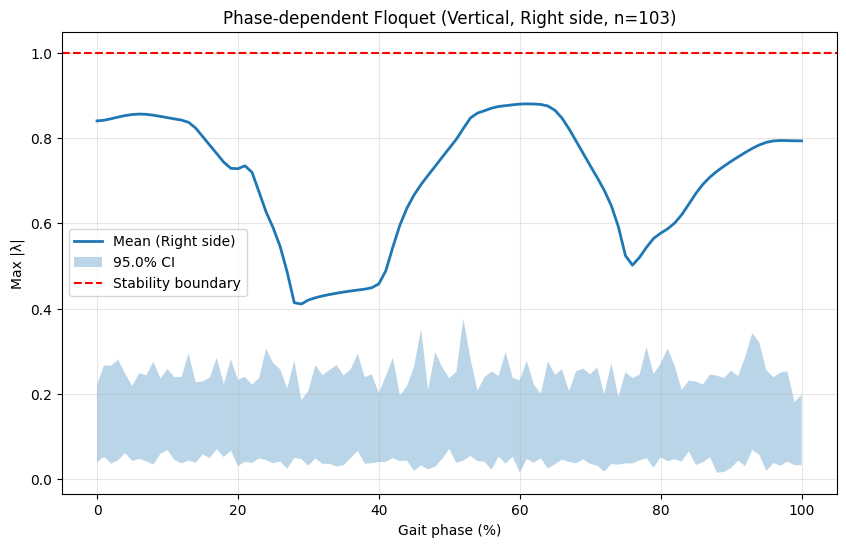

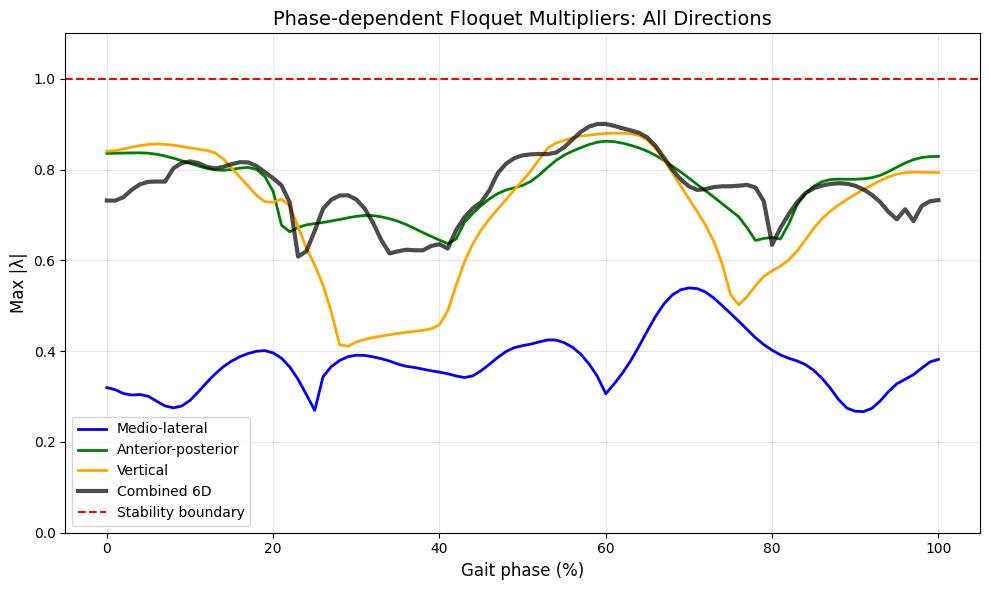


PHASE-SPECIFIC STABILITY SUMMARY
Heel strike (0%): λ = 0.7317
Loading response (10%): λ = 0.8179
Mid-stance (30%): λ = 0.7340
Terminal stance (50%): λ = 0.8313
Pre-swing (60%): λ = 0.9004
Initial swing (73%): λ = 0.7614
Mid-swing (87%): λ = 0.7682
Terminal swing (100%): λ = 0.7326

Extracting normalized trajectories for limit cycle analysis...

Extracting 103 Right-to-Right strides
Extracted data shape: 103 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


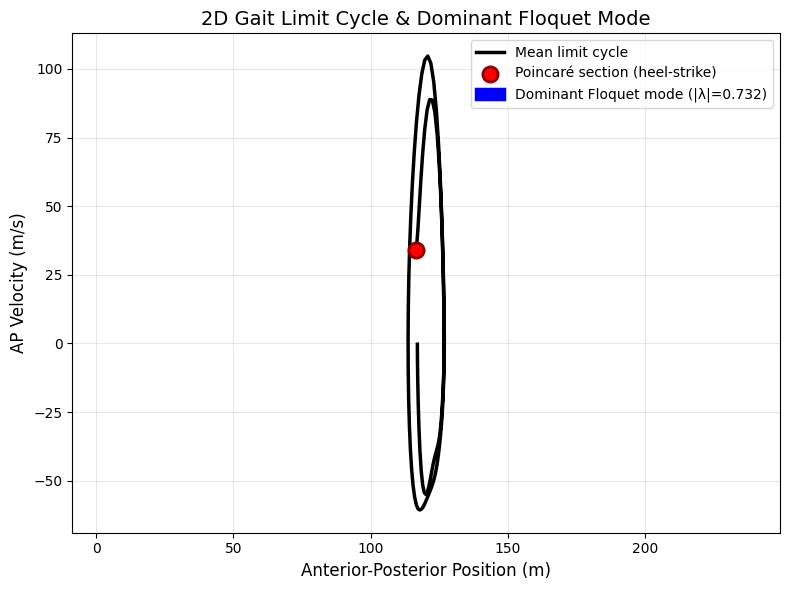


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.7317
- Eigenvector direction in (y, ẏ): [-0.098, 0.019]


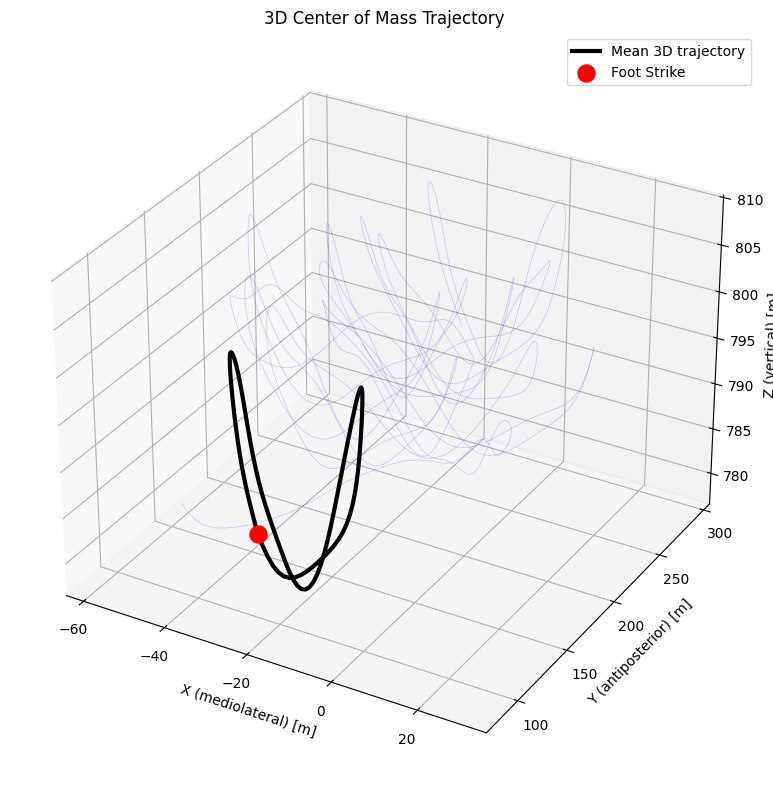

In [27]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events

def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # Load the data
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "08" /  "markers.nc"
    events_path = cwd.parent  / ".." / "data" / "PBT" / "Elderly" / "08" /  "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds = xr.open_dataset(data_path)
    df_all = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time = SKIP_SAMPLES / fs

    # Get foot strike events
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], 120.0
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (all {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 1) First, run a simple combined analysis to check everything works
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running combined 6D analysis first...")
    print("="*60)
    
    combined_result = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=['x', 'y', 'z'],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=100,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    print(f"\nCombined (6D): λ = {combined_result['max_floquet']:.4f} [{combined_result['confidence_interval'][0]:.4f}, {combined_result['confidence_interval'][1]:.4f}]")
    
    # ——————————————————————————————
    # 2) Now compute per-axis if you have the function defined
    # ——————————————————————————————
    if 'compute_floquet_per_axis' in globals():
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS")
        print("="*60)
        
        axis_results = compute_floquet_per_axis(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=False,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=100,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        # Display summary
        print("\n" + "="*60)
        print("FLOQUET STABILITY SUMMARY (RIGHT FOOT)")
        print("="*60)
        print(f"Medio-lateral (x):      λ = {axis_results['x']['max_floquet']:.4f} [{axis_results['x']['confidence_interval'][0]:.4f}, {axis_results['x']['confidence_interval'][1]:.4f}]")
        print(f"Anterior-posterior (y): λ = {axis_results['y']['max_floquet']:.4f} [{axis_results['y']['confidence_interval'][0]:.4f}, {axis_results['y']['confidence_interval'][1]:.4f}]")
        print(f"Vertical (z):           λ = {axis_results['z']['max_floquet']:.4f} [{axis_results['z']['confidence_interval'][0]:.4f}, {axis_results['z']['confidence_interval'][1]:.4f}]")
        print(f"Combined (6D):          λ = {axis_results['combined']['max_floquet']:.4f} [{axis_results['combined']['confidence_interval'][0]:.4f}, {axis_results['combined']['confidence_interval'][1]:.4f}]")
        
        # Identify most/least stable directions
        axis_values = {
            'Medio-lateral': axis_results['x']['max_floquet'],
            'Anterior-posterior': axis_results['y']['max_floquet'],
            'Vertical': axis_results['z']['max_floquet']
        }
        
        most_stable_axis = min(axis_values, key=axis_values.get)
        least_stable_axis = max(axis_values, key=axis_values.get)
        
        print(f"\nMost stable direction:  {most_stable_axis} (λ = {axis_values[most_stable_axis]:.4f})")
        print(f"Least stable direction: {least_stable_axis} (λ = {axis_values[least_stable_axis]:.4f})")
    else:
        # If compute_floquet_per_axis is not defined, compute each axis manually
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS (Manual)")
        print("="*60)
        
        axis_results = {}
        
        # Compute for each axis
        for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
            print(f"\nAnalyzing {name} ({axis}) axis...")
            axis_result = compute_floquet_from_events(
                com_da=com_window,
                events_df=df_window,
                channel="COM",
                axes=[axis],  # Single axis only
                normalization_points=101,
                rcond=1e-6,
                phase_dependent=False,
                plot_spectrum=False,
                use_same_side=True,
                force_side='Right',
                trim_cycles=0,
                bootstrap_n=100,
                bootstrap_ci=95.0,
                lowpass_cutoff=8.0,
                min_cycles_required=150
            )
            axis_results[axis] = axis_result
            print(f"{name}: λ = {axis_result['max_floquet']:.4f} [{axis_result['confidence_interval'][0]:.4f}, {axis_result['confidence_interval'][1]:.4f}]")
        
        axis_results['combined'] = combined_result



    # ——————————————————————————————
    # 4) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,  # Enable phase-dependent
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,  # Fewer iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    # The function automatically plots, but let's also create a custom plot
    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']
    ci_low, ci_high = phase_results['confidence_interval']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 1) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 2) Phase-dependent for each axis separately
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Phase-dependent analysis per axis...")
    print("="*60 + "\n")
    
    axis_phase_results = {}
    
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        print(f"Computing phase-dependent for {name} axis...")
        
        phase_result = compute_floquet_from_events(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            axes=[axis],
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=True,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=30,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        axis_phase_results[axis] = phase_result

    # ——————————————————————————————
    # 3) Create comparison plot of all axes on one graph
    # ——————————————————————————————
    plt.figure(figsize=(10, 6))
    
    # Plot each axis
    colors = {'x': 'blue', 'y': 'green', 'z': 'orange'}
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        plt.plot(phases, axis_phase_results[axis]['max_floquet'], 
                color=colors[axis], linewidth=2, label=name)
    
    # Add combined
    plt.plot(phases, phase_results['max_floquet'], 'k-', 
            linewidth=3, label='Combined 6D', alpha=0.7)
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
    plt.xlabel('Gait phase (%)', fontsize=12)
    plt.ylabel('Max |λ|', fontsize=12)
    plt.title('Phase-dependent Floquet Multipliers: All Directions', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    # ——————————————————————————————
    # 4) Print phase-specific statistics
    # ——————————————————————————————
    print("\n" + "="*60)
    print("PHASE-SPECIFIC STABILITY SUMMARY")
    print("="*60)
    
    # Typical gait events
    gait_events = {
        0: "Heel strike",
        10: "Loading response", 
        30: "Mid-stance",
        50: "Terminal stance",
        60: "Pre-swing",
        73: "Initial swing",
        87: "Mid-swing",
        100: "Terminal swing"
    }
    
    for phase, event in gait_events.items():
        if phase < len(phase_results['max_floquet']):
            print(f"{event} ({phase}%): λ = {phase_results['max_floquet'][phase]:.4f}")

        
    # ——————————————————————————————
    # 3) Extract data for limit cycle visualization
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,
        side_used='Right',
        trim_cycles=0,
        lowpass_cutoff=8.0,
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # Plot the 2D limit cycle
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

## Post

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 160.00s to 314.82s (all 299 R_FS)
Using 311 foot‐strike events for Floquet segmentation

Running combined 6D analysis first...
Using Right-to-Right strides: 155 strides


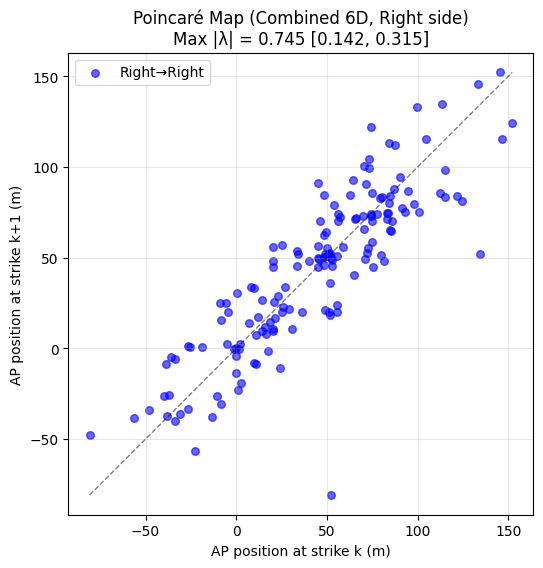


Combined (6D): λ = 0.7446 [0.1417, 0.3155]

ANALYZING STABILITY PER AXIS

COMPUTING PER-AXIS FLOQUET MULTIPLIERS

Analyzing Medio-lateral (x) axis...
Using Right-to-Right strides: 155 strides


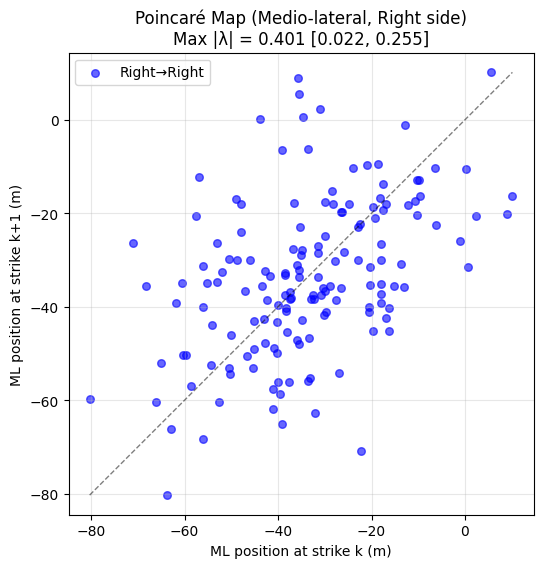


Analyzing Anterior-posterior (y) axis...
Using Right-to-Right strides: 155 strides


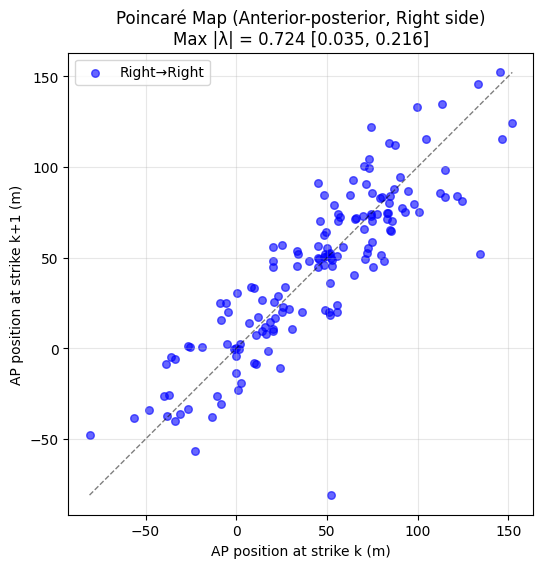


Analyzing Vertical (z) axis...
Using Right-to-Right strides: 155 strides


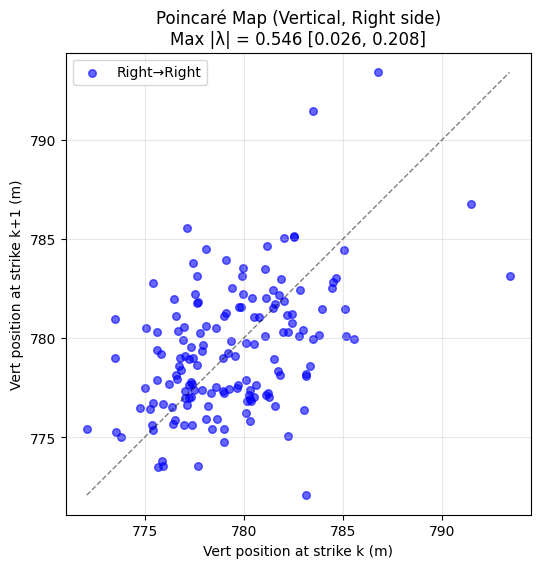


Analyzing Combined 6D state space...
Using Right-to-Right strides: 155 strides


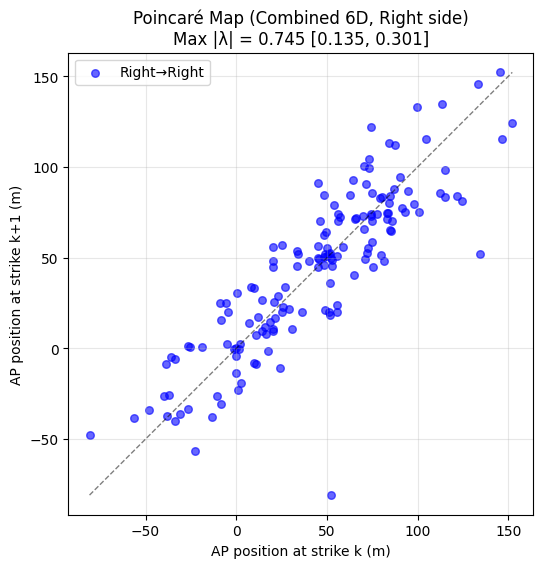


FLOQUET STABILITY SUMMARY (RIGHT FOOT)
Medio-lateral (x):      λ = 0.4014 [0.0219, 0.2553]
Anterior-posterior (y): λ = 0.7245 [0.0346, 0.2158]
Vertical (z):           λ = 0.5462 [0.0255, 0.2076]
Combined (6D):          λ = 0.7446 [0.1348, 0.3008]

Most stable direction:  Medio-lateral (λ = 0.4014)
Least stable direction: Anterior-posterior (λ = 0.7245)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 155 strides


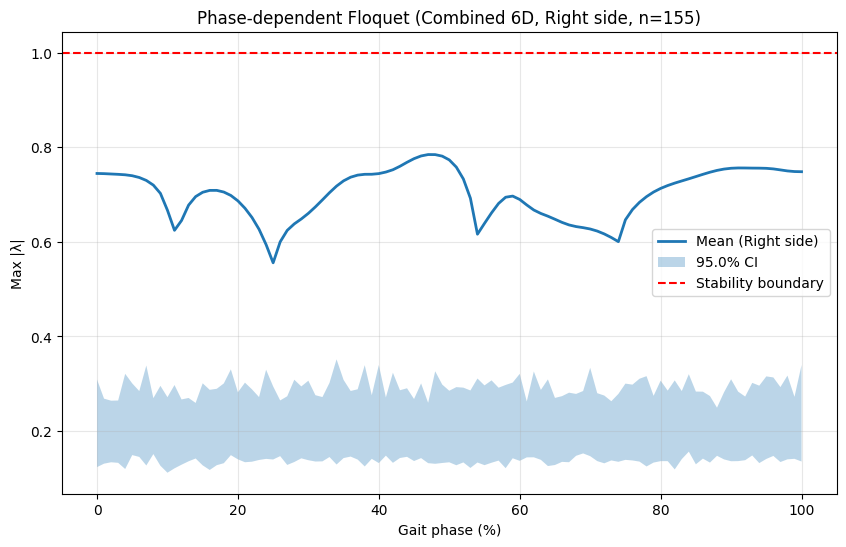

Most stable phase: 25% of gait cycle (λ = 0.5557)
Least stable phase: 47% of gait cycle (λ = 0.7846)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 155 strides


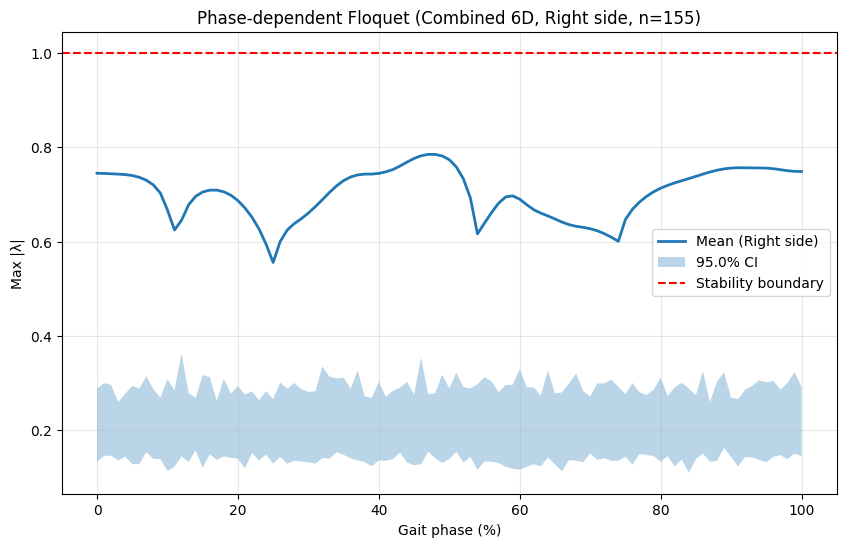

Most stable phase: 25% of gait cycle (λ = 0.5557)
Least stable phase: 47% of gait cycle (λ = 0.7846)

Phase-dependent analysis per axis...

Computing phase-dependent for Medio-lateral axis...
Using Right-to-Right strides: 155 strides


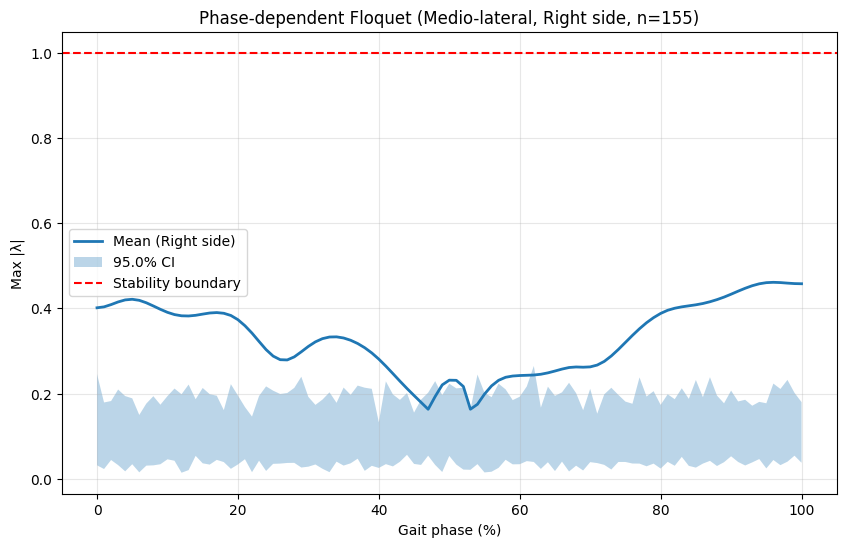

Computing phase-dependent for Anterior-posterior axis...
Using Right-to-Right strides: 155 strides


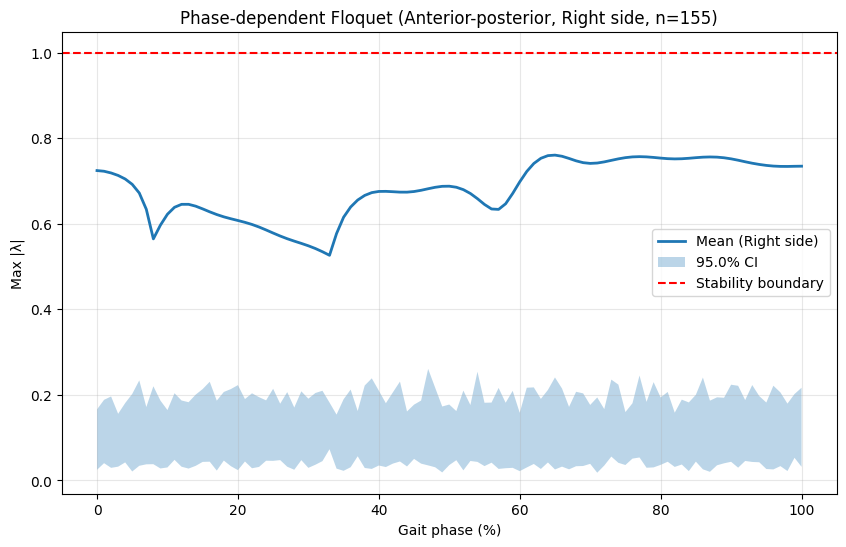

Computing phase-dependent for Vertical axis...
Using Right-to-Right strides: 155 strides


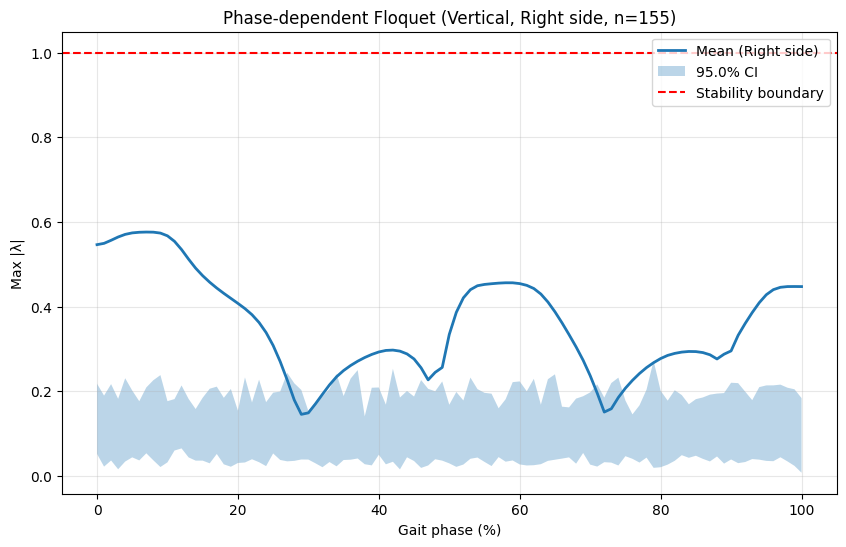

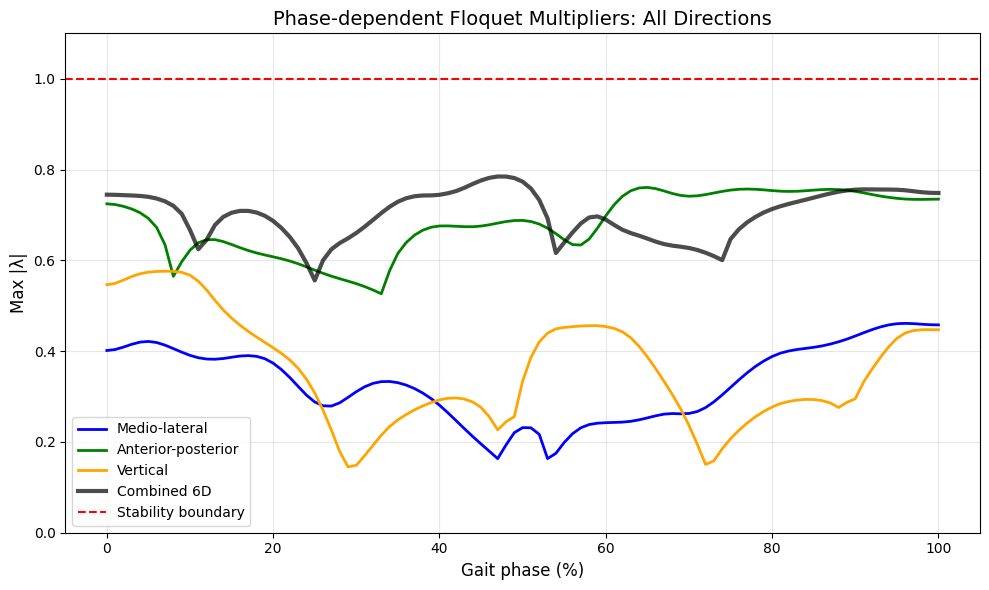


PHASE-SPECIFIC STABILITY SUMMARY
Heel strike (0%): λ = 0.7446
Loading response (10%): λ = 0.6668
Mid-stance (30%): λ = 0.6603
Terminal stance (50%): λ = 0.7733
Pre-swing (60%): λ = 0.6896
Initial swing (73%): λ = 0.6092
Mid-swing (87%): λ = 0.7473
Terminal swing (100%): λ = 0.7484

Extracting normalized trajectories for limit cycle analysis...

Extracting 155 Right-to-Right strides
Extracted data shape: 155 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


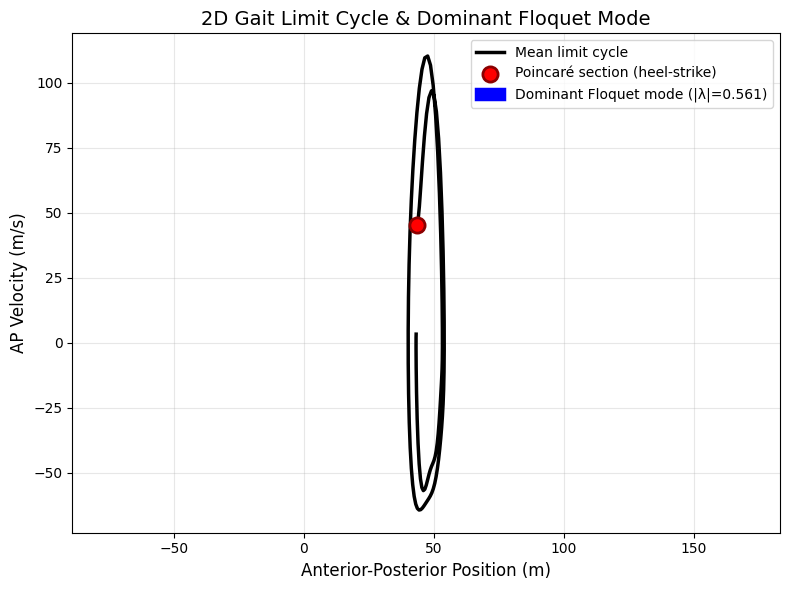


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.5611
- Eigenvector direction in (y, ẏ): [-0.081, 0.058]


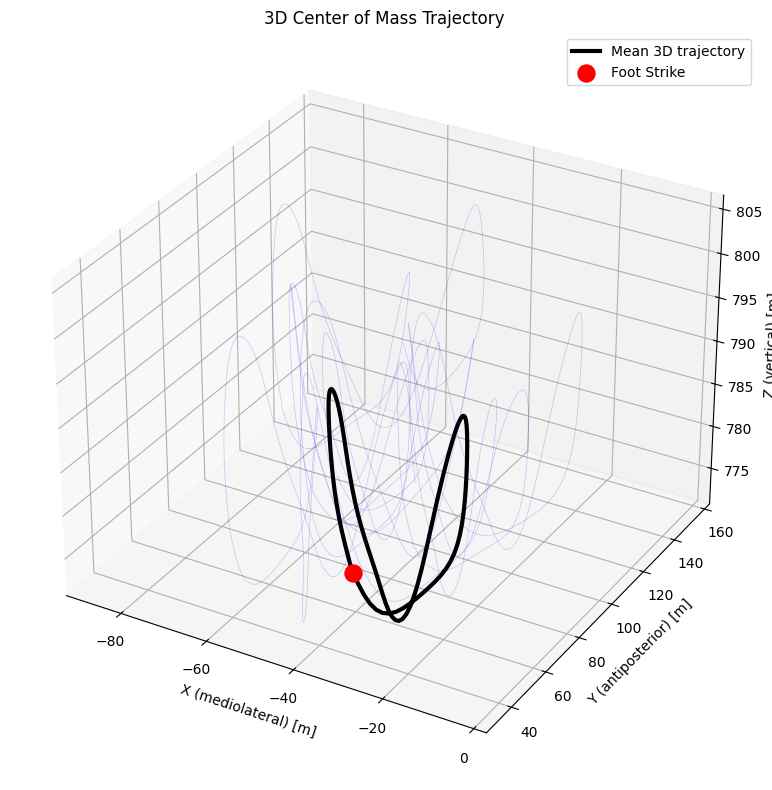

In [28]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events

def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # Load the data
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "08" /  "markers.nc"
    events_path = cwd.parent  / ".." / "data" / "PBT" / "Elderly" / "08" /  "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds = xr.open_dataset(data_path)
    df_all = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time = SKIP_SAMPLES / fs

    # Get foot strike events
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = 160.0, first_n.time.iloc[-1]
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (all {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 1) First, run a simple combined analysis to check everything works
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running combined 6D analysis first...")
    print("="*60)
    
    combined_result = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=['x', 'y', 'z'],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=100,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    print(f"\nCombined (6D): λ = {combined_result['max_floquet']:.4f} [{combined_result['confidence_interval'][0]:.4f}, {combined_result['confidence_interval'][1]:.4f}]")
    
    # ——————————————————————————————
    # 2) Now compute per-axis if you have the function defined
    # ——————————————————————————————
    if 'compute_floquet_per_axis' in globals():
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS")
        print("="*60)
        
        axis_results = compute_floquet_per_axis(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=False,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=100,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        # Display summary
        print("\n" + "="*60)
        print("FLOQUET STABILITY SUMMARY (RIGHT FOOT)")
        print("="*60)
        print(f"Medio-lateral (x):      λ = {axis_results['x']['max_floquet']:.4f} [{axis_results['x']['confidence_interval'][0]:.4f}, {axis_results['x']['confidence_interval'][1]:.4f}]")
        print(f"Anterior-posterior (y): λ = {axis_results['y']['max_floquet']:.4f} [{axis_results['y']['confidence_interval'][0]:.4f}, {axis_results['y']['confidence_interval'][1]:.4f}]")
        print(f"Vertical (z):           λ = {axis_results['z']['max_floquet']:.4f} [{axis_results['z']['confidence_interval'][0]:.4f}, {axis_results['z']['confidence_interval'][1]:.4f}]")
        print(f"Combined (6D):          λ = {axis_results['combined']['max_floquet']:.4f} [{axis_results['combined']['confidence_interval'][0]:.4f}, {axis_results['combined']['confidence_interval'][1]:.4f}]")
        
        # Identify most/least stable directions
        axis_values = {
            'Medio-lateral': axis_results['x']['max_floquet'],
            'Anterior-posterior': axis_results['y']['max_floquet'],
            'Vertical': axis_results['z']['max_floquet']
        }
        
        most_stable_axis = min(axis_values, key=axis_values.get)
        least_stable_axis = max(axis_values, key=axis_values.get)
        
        print(f"\nMost stable direction:  {most_stable_axis} (λ = {axis_values[most_stable_axis]:.4f})")
        print(f"Least stable direction: {least_stable_axis} (λ = {axis_values[least_stable_axis]:.4f})")
    else:
        # If compute_floquet_per_axis is not defined, compute each axis manually
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS (Manual)")
        print("="*60)
        
        axis_results = {}
        
        # Compute for each axis
        for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
            print(f"\nAnalyzing {name} ({axis}) axis...")
            axis_result = compute_floquet_from_events(
                com_da=com_window,
                events_df=df_window,
                channel="COM",
                axes=[axis],  # Single axis only
                normalization_points=101,
                rcond=1e-6,
                phase_dependent=False,
                plot_spectrum=False,
                use_same_side=True,
                force_side='Right',
                trim_cycles=0,
                bootstrap_n=100,
                bootstrap_ci=95.0,
                lowpass_cutoff=8.0,
                min_cycles_required=150
            )
            axis_results[axis] = axis_result
            print(f"{name}: λ = {axis_result['max_floquet']:.4f} [{axis_result['confidence_interval'][0]:.4f}, {axis_result['confidence_interval'][1]:.4f}]")
        
        axis_results['combined'] = combined_result



    # ——————————————————————————————
    # 4) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,  # Enable phase-dependent
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,  # Fewer iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    # The function automatically plots, but let's also create a custom plot
    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']
    ci_low, ci_high = phase_results['confidence_interval']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 1) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 2) Phase-dependent for each axis separately
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Phase-dependent analysis per axis...")
    print("="*60 + "\n")
    
    axis_phase_results = {}
    
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        print(f"Computing phase-dependent for {name} axis...")
        
        phase_result = compute_floquet_from_events(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            axes=[axis],
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=True,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=30,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        axis_phase_results[axis] = phase_result

    # ——————————————————————————————
    # 3) Create comparison plot of all axes on one graph
    # ——————————————————————————————
    plt.figure(figsize=(10, 6))
    
    # Plot each axis
    colors = {'x': 'blue', 'y': 'green', 'z': 'orange'}
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        plt.plot(phases, axis_phase_results[axis]['max_floquet'], 
                color=colors[axis], linewidth=2, label=name)
    
    # Add combined
    plt.plot(phases, phase_results['max_floquet'], 'k-', 
            linewidth=3, label='Combined 6D', alpha=0.7)
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
    plt.xlabel('Gait phase (%)', fontsize=12)
    plt.ylabel('Max |λ|', fontsize=12)
    plt.title('Phase-dependent Floquet Multipliers: All Directions', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    # ——————————————————————————————
    # 4) Print phase-specific statistics
    # ——————————————————————————————
    print("\n" + "="*60)
    print("PHASE-SPECIFIC STABILITY SUMMARY")
    print("="*60)
    
    # Typical gait events
    gait_events = {
        0: "Heel strike",
        10: "Loading response", 
        30: "Mid-stance",
        50: "Terminal stance",
        60: "Pre-swing",
        73: "Initial swing",
        87: "Mid-swing",
        100: "Terminal swing"
    }
    
    for phase, event in gait_events.items():
        if phase < len(phase_results['max_floquet']):
            print(f"{event} ({phase}%): λ = {phase_results['max_floquet'][phase]:.4f}")

        
    # ——————————————————————————————
    # 3) Extract data for limit cycle visualization
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,
        side_used='Right',
        trim_cycles=0,
        lowpass_cutoff=8.0,
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # Plot the 2D limit cycle
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

## Patient 09

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 10.77s to 120.00s (all 270 R_FS)
Using 257 foot‐strike events for Floquet segmentation

Running combined 6D analysis first...
Using Right-to-Right strides: 128 strides


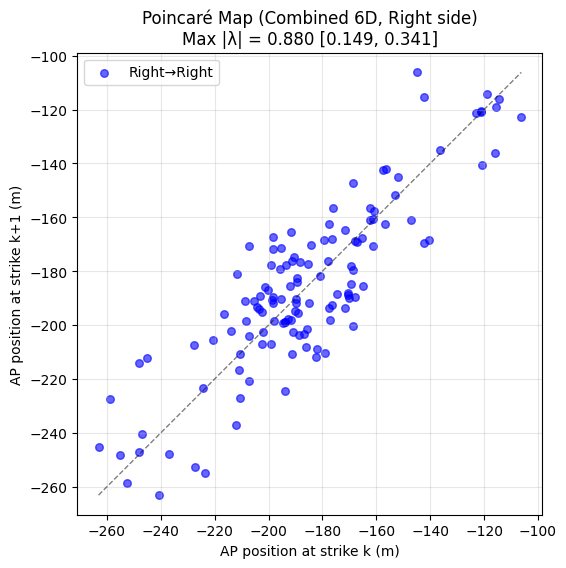


Combined (6D): λ = 0.8802 [0.1489, 0.3411]

ANALYZING STABILITY PER AXIS

COMPUTING PER-AXIS FLOQUET MULTIPLIERS

Analyzing Medio-lateral (x) axis...
Using Right-to-Right strides: 128 strides


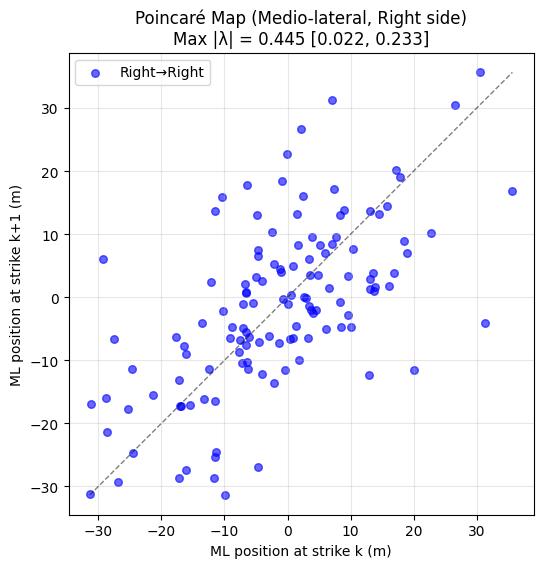


Analyzing Anterior-posterior (y) axis...
Using Right-to-Right strides: 128 strides


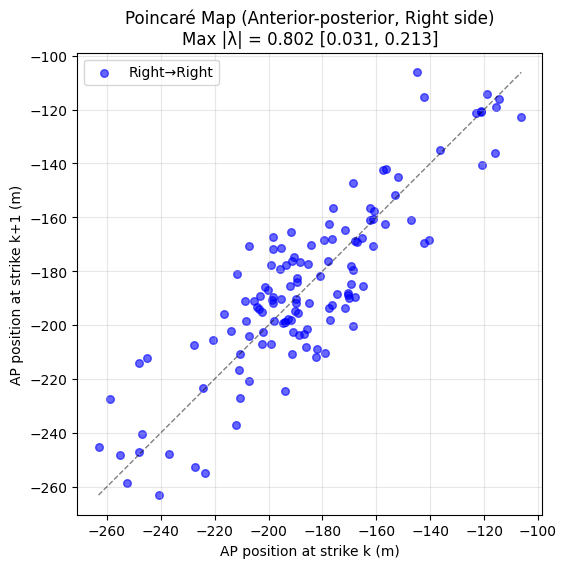


Analyzing Vertical (z) axis...
Using Right-to-Right strides: 128 strides


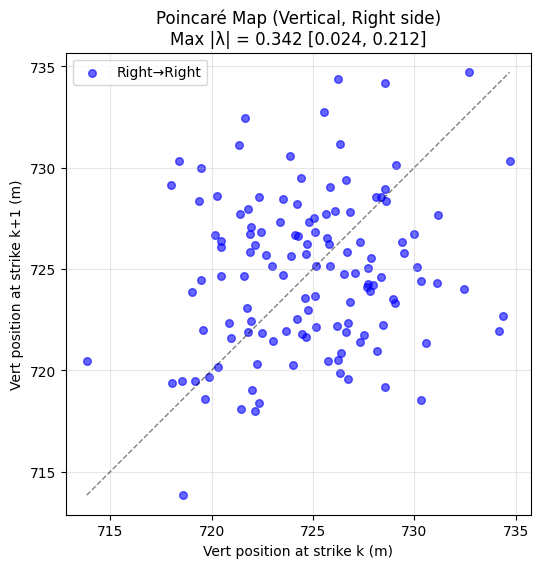


Analyzing Combined 6D state space...
Using Right-to-Right strides: 128 strides


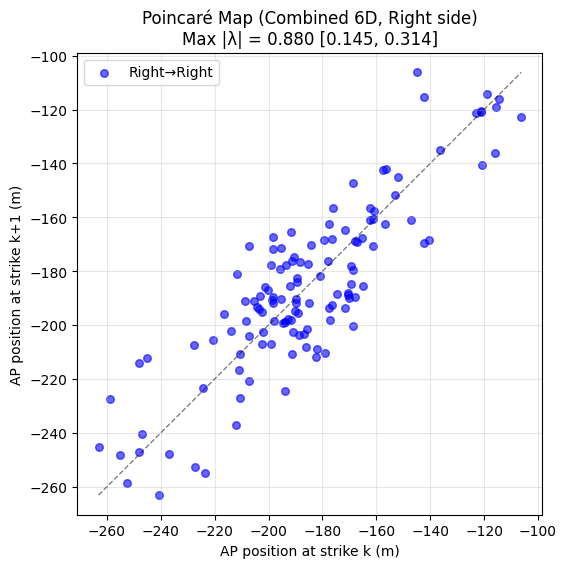


FLOQUET STABILITY SUMMARY (RIGHT FOOT)
Medio-lateral (x):      λ = 0.4445 [0.0219, 0.2332]
Anterior-posterior (y): λ = 0.8016 [0.0305, 0.2132]
Vertical (z):           λ = 0.3418 [0.0239, 0.2120]
Combined (6D):          λ = 0.8802 [0.1447, 0.3140]

Most stable direction:  Vertical (λ = 0.3418)
Least stable direction: Anterior-posterior (λ = 0.8016)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 128 strides


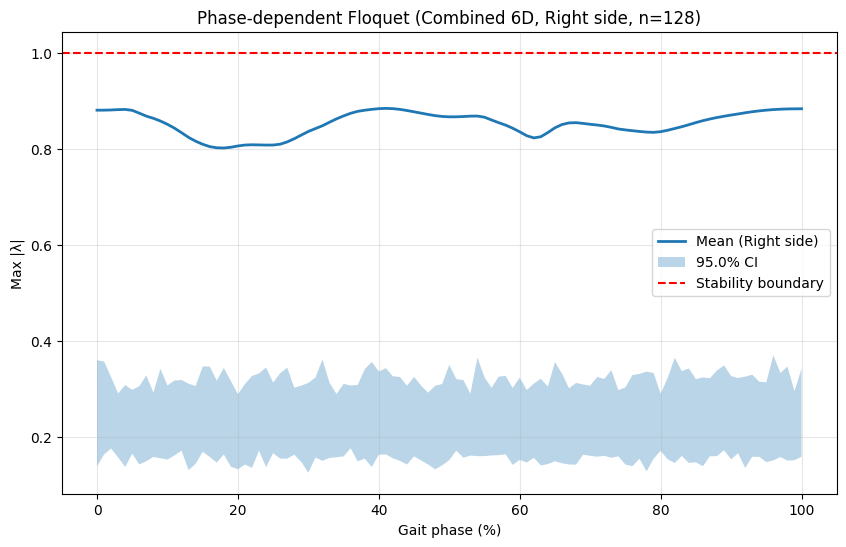

Most stable phase: 18% of gait cycle (λ = 0.8014)
Least stable phase: 41% of gait cycle (λ = 0.8840)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 128 strides


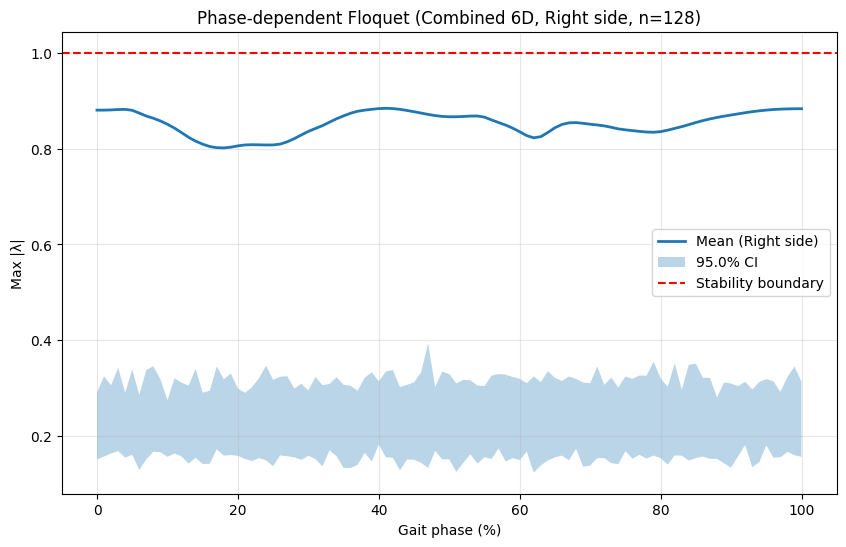

Most stable phase: 18% of gait cycle (λ = 0.8014)
Least stable phase: 41% of gait cycle (λ = 0.8840)

Phase-dependent analysis per axis...

Computing phase-dependent for Medio-lateral axis...
Using Right-to-Right strides: 128 strides


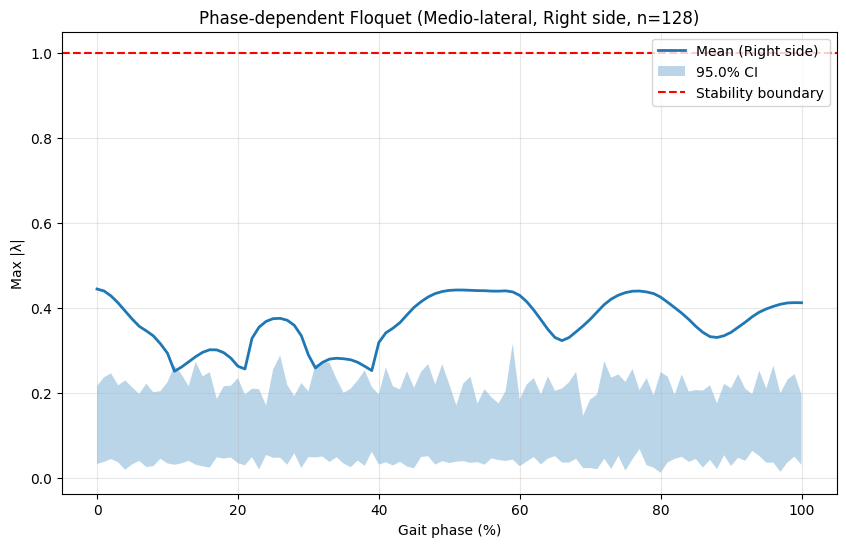

Computing phase-dependent for Anterior-posterior axis...
Using Right-to-Right strides: 128 strides


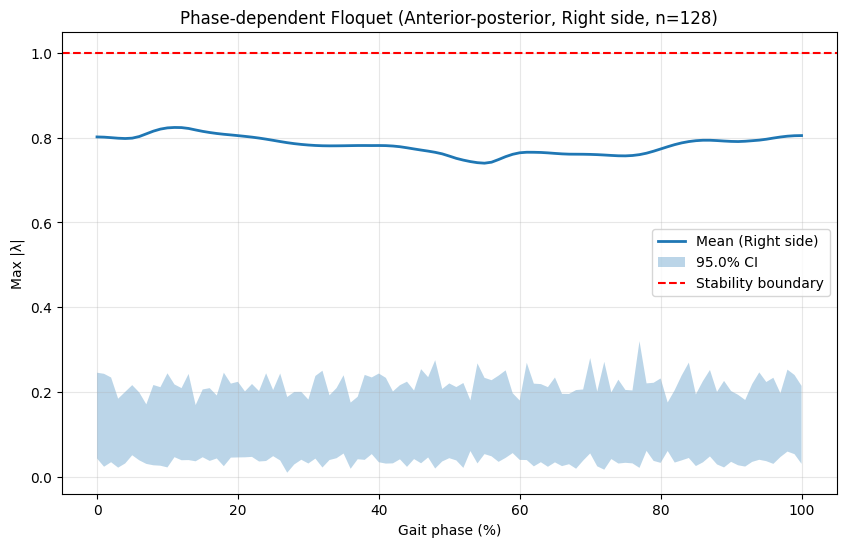

Computing phase-dependent for Vertical axis...
Using Right-to-Right strides: 128 strides


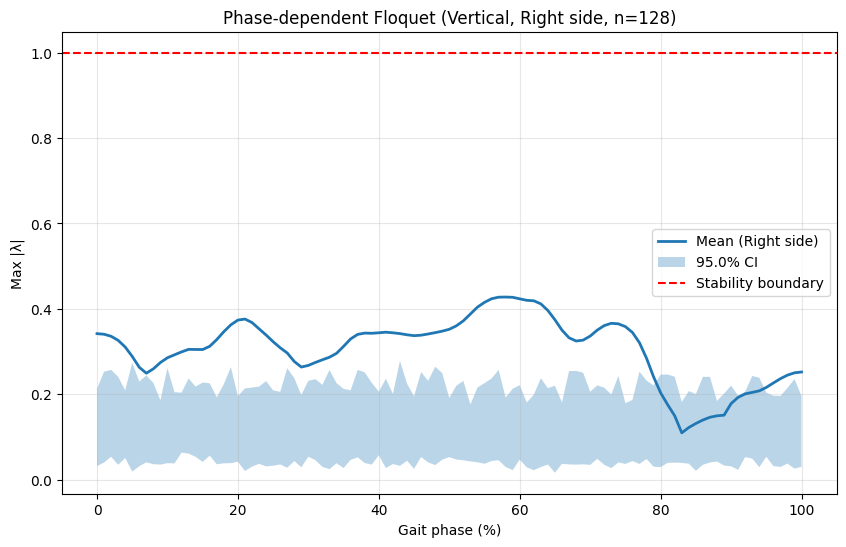

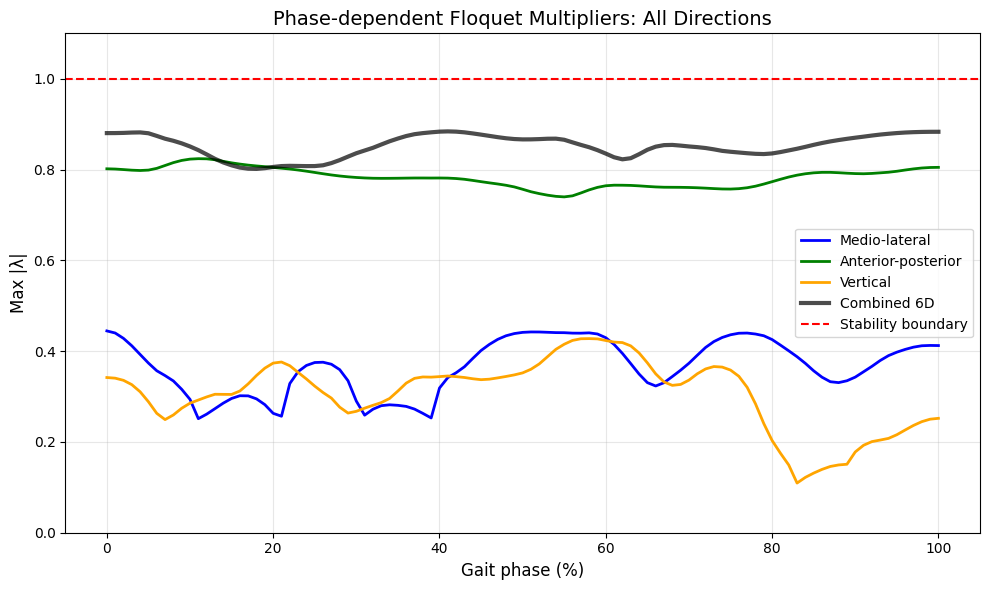


PHASE-SPECIFIC STABILITY SUMMARY
Heel strike (0%): λ = 0.8802
Loading response (10%): λ = 0.8508
Mid-stance (30%): λ = 0.8359
Terminal stance (50%): λ = 0.8664
Pre-swing (60%): λ = 0.8351
Initial swing (73%): λ = 0.8445
Mid-swing (87%): λ = 0.8619
Terminal swing (100%): λ = 0.8832

Extracting normalized trajectories for limit cycle analysis...

Extracting 128 Right-to-Right strides
Extracted data shape: 128 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


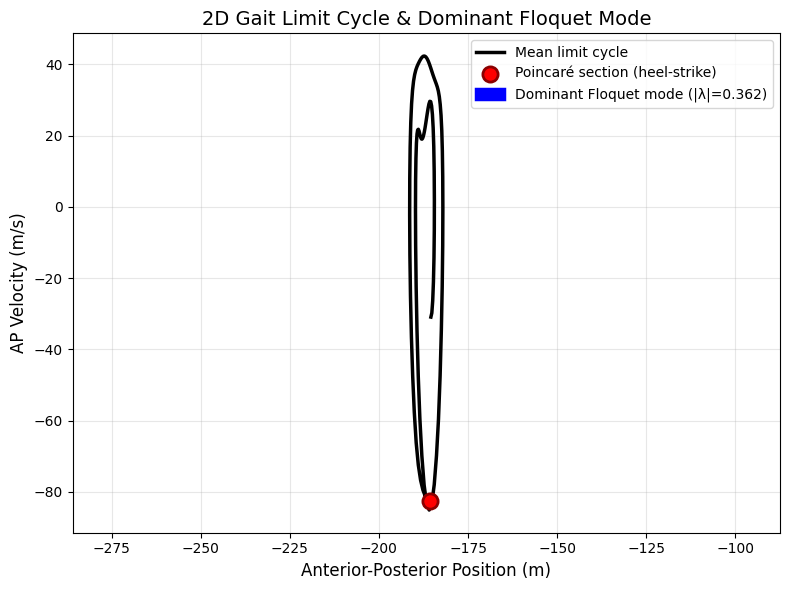


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.3618
- Eigenvector direction in (y, ẏ): [-0.032, 0.095]


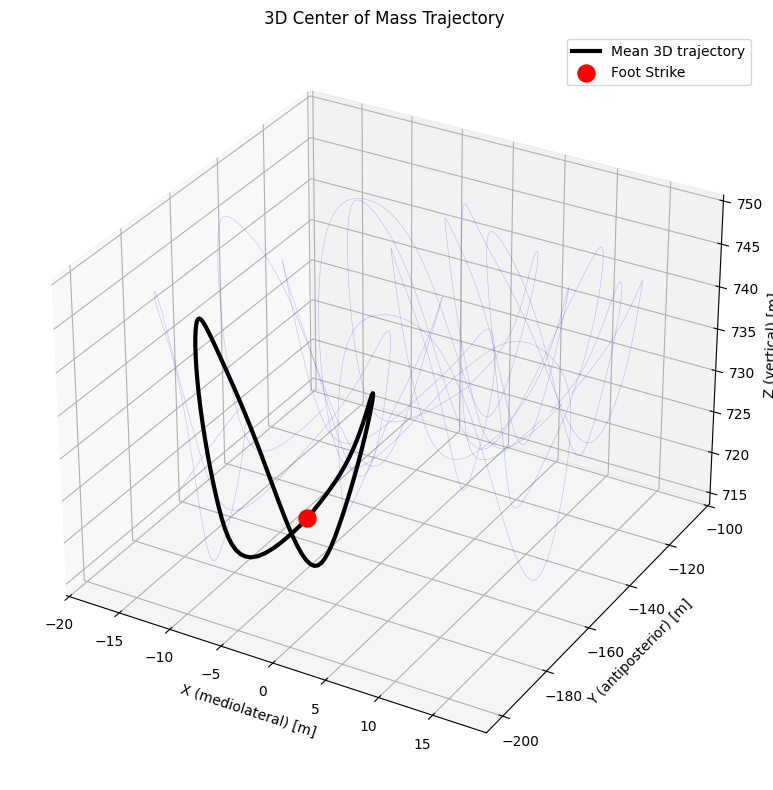

In [29]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events

def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # Load the data
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "09" /  "markers.nc"
    events_path = cwd.parent  / ".." / "data" / "PBT" / "Elderly" / "09" /  "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds = xr.open_dataset(data_path)
    df_all = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time = SKIP_SAMPLES / fs

    # Get foot strike events
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], 120.0
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (all {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 1) First, run a simple combined analysis to check everything works
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running combined 6D analysis first...")
    print("="*60)
    
    combined_result = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=['x', 'y', 'z'],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=100,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    print(f"\nCombined (6D): λ = {combined_result['max_floquet']:.4f} [{combined_result['confidence_interval'][0]:.4f}, {combined_result['confidence_interval'][1]:.4f}]")
    
    # ——————————————————————————————
    # 2) Now compute per-axis if you have the function defined
    # ——————————————————————————————
    if 'compute_floquet_per_axis' in globals():
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS")
        print("="*60)
        
        axis_results = compute_floquet_per_axis(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=False,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=100,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        # Display summary
        print("\n" + "="*60)
        print("FLOQUET STABILITY SUMMARY (RIGHT FOOT)")
        print("="*60)
        print(f"Medio-lateral (x):      λ = {axis_results['x']['max_floquet']:.4f} [{axis_results['x']['confidence_interval'][0]:.4f}, {axis_results['x']['confidence_interval'][1]:.4f}]")
        print(f"Anterior-posterior (y): λ = {axis_results['y']['max_floquet']:.4f} [{axis_results['y']['confidence_interval'][0]:.4f}, {axis_results['y']['confidence_interval'][1]:.4f}]")
        print(f"Vertical (z):           λ = {axis_results['z']['max_floquet']:.4f} [{axis_results['z']['confidence_interval'][0]:.4f}, {axis_results['z']['confidence_interval'][1]:.4f}]")
        print(f"Combined (6D):          λ = {axis_results['combined']['max_floquet']:.4f} [{axis_results['combined']['confidence_interval'][0]:.4f}, {axis_results['combined']['confidence_interval'][1]:.4f}]")
        
        # Identify most/least stable directions
        axis_values = {
            'Medio-lateral': axis_results['x']['max_floquet'],
            'Anterior-posterior': axis_results['y']['max_floquet'],
            'Vertical': axis_results['z']['max_floquet']
        }
        
        most_stable_axis = min(axis_values, key=axis_values.get)
        least_stable_axis = max(axis_values, key=axis_values.get)
        
        print(f"\nMost stable direction:  {most_stable_axis} (λ = {axis_values[most_stable_axis]:.4f})")
        print(f"Least stable direction: {least_stable_axis} (λ = {axis_values[least_stable_axis]:.4f})")
    else:
        # If compute_floquet_per_axis is not defined, compute each axis manually
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS (Manual)")
        print("="*60)
        
        axis_results = {}
        
        # Compute for each axis
        for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
            print(f"\nAnalyzing {name} ({axis}) axis...")
            axis_result = compute_floquet_from_events(
                com_da=com_window,
                events_df=df_window,
                channel="COM",
                axes=[axis],  # Single axis only
                normalization_points=101,
                rcond=1e-6,
                phase_dependent=False,
                plot_spectrum=False,
                use_same_side=True,
                force_side='Right',
                trim_cycles=0,
                bootstrap_n=100,
                bootstrap_ci=95.0,
                lowpass_cutoff=8.0,
                min_cycles_required=150
            )
            axis_results[axis] = axis_result
            print(f"{name}: λ = {axis_result['max_floquet']:.4f} [{axis_result['confidence_interval'][0]:.4f}, {axis_result['confidence_interval'][1]:.4f}]")
        
        axis_results['combined'] = combined_result



    # ——————————————————————————————
    # 4) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,  # Enable phase-dependent
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,  # Fewer iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    # The function automatically plots, but let's also create a custom plot
    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']
    ci_low, ci_high = phase_results['confidence_interval']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 1) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 2) Phase-dependent for each axis separately
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Phase-dependent analysis per axis...")
    print("="*60 + "\n")
    
    axis_phase_results = {}
    
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        print(f"Computing phase-dependent for {name} axis...")
        
        phase_result = compute_floquet_from_events(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            axes=[axis],
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=True,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=30,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        axis_phase_results[axis] = phase_result

    # ——————————————————————————————
    # 3) Create comparison plot of all axes on one graph
    # ——————————————————————————————
    plt.figure(figsize=(10, 6))
    
    # Plot each axis
    colors = {'x': 'blue', 'y': 'green', 'z': 'orange'}
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        plt.plot(phases, axis_phase_results[axis]['max_floquet'], 
                color=colors[axis], linewidth=2, label=name)
    
    # Add combined
    plt.plot(phases, phase_results['max_floquet'], 'k-', 
            linewidth=3, label='Combined 6D', alpha=0.7)
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
    plt.xlabel('Gait phase (%)', fontsize=12)
    plt.ylabel('Max |λ|', fontsize=12)
    plt.title('Phase-dependent Floquet Multipliers: All Directions', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    # ——————————————————————————————
    # 4) Print phase-specific statistics
    # ——————————————————————————————
    print("\n" + "="*60)
    print("PHASE-SPECIFIC STABILITY SUMMARY")
    print("="*60)
    
    # Typical gait events
    gait_events = {
        0: "Heel strike",
        10: "Loading response", 
        30: "Mid-stance",
        50: "Terminal stance",
        60: "Pre-swing",
        73: "Initial swing",
        87: "Mid-swing",
        100: "Terminal swing"
    }
    
    for phase, event in gait_events.items():
        if phase < len(phase_results['max_floquet']):
            print(f"{event} ({phase}%): λ = {phase_results['max_floquet'][phase]:.4f}")

        
    # ——————————————————————————————
    # 3) Extract data for limit cycle visualization
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,
        side_used='Right',
        trim_cycles=0,
        lowpass_cutoff=8.0,
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # Plot the 2D limit cycle
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

## Post

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 160.00s to 243.01s (all 270 R_FS)
Using 191 foot‐strike events for Floquet segmentation

Running combined 6D analysis first...
Using Right-to-Right strides: 95 strides


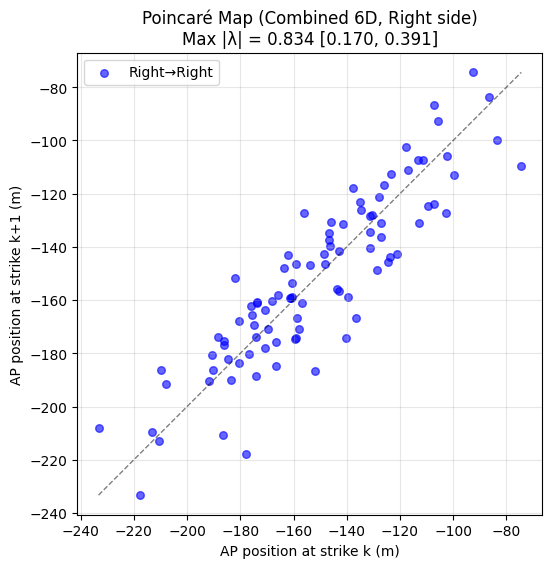


Combined (6D): λ = 0.8337 [0.1703, 0.3911]

ANALYZING STABILITY PER AXIS

COMPUTING PER-AXIS FLOQUET MULTIPLIERS

Analyzing Medio-lateral (x) axis...
Using Right-to-Right strides: 95 strides


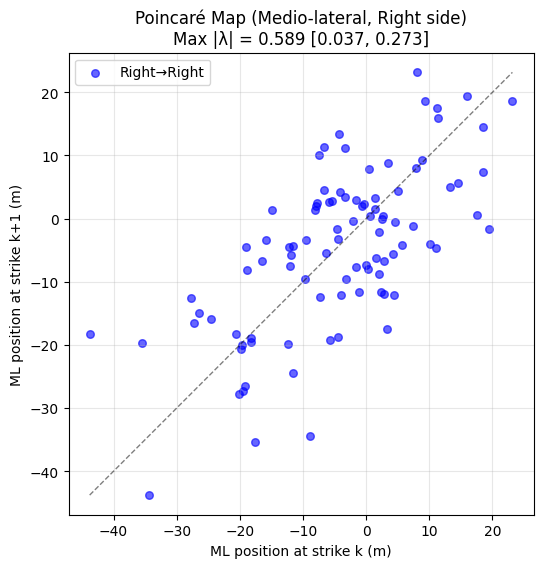


Analyzing Anterior-posterior (y) axis...
Using Right-to-Right strides: 95 strides


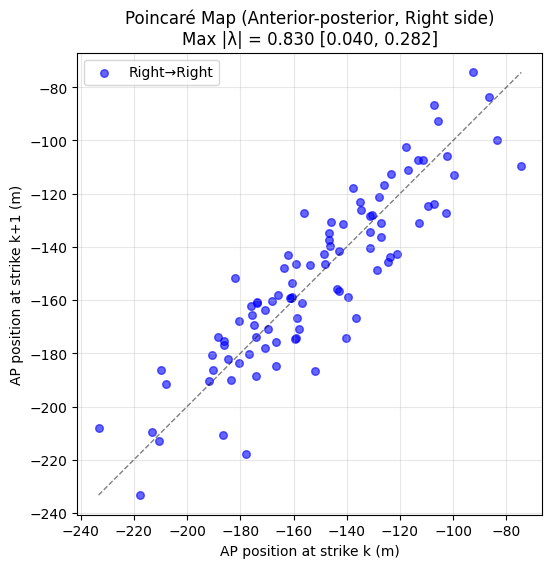


Analyzing Vertical (z) axis...
Using Right-to-Right strides: 95 strides


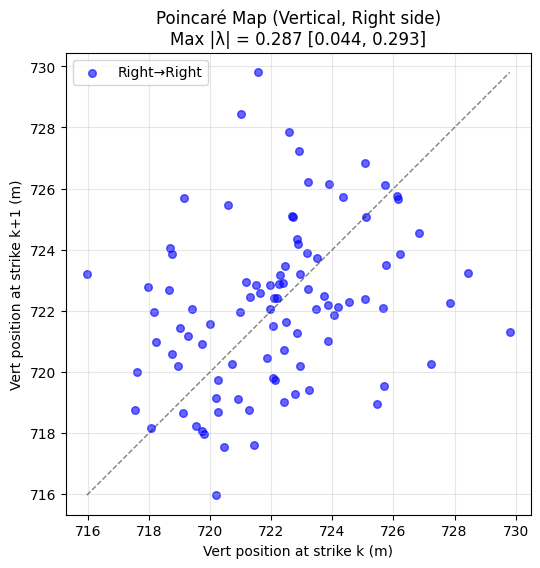


Analyzing Combined 6D state space...
Using Right-to-Right strides: 95 strides


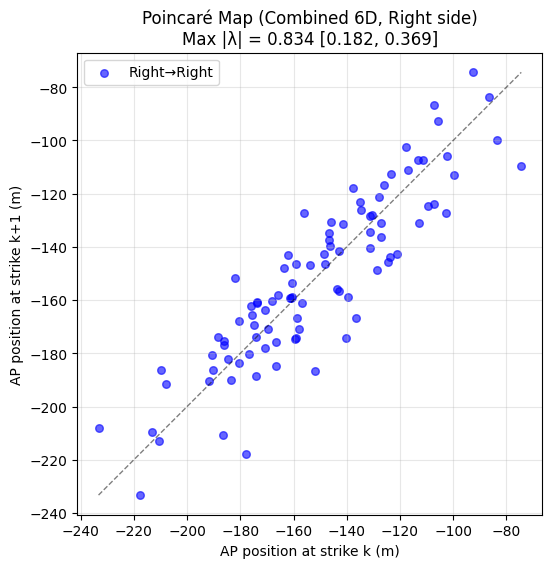


FLOQUET STABILITY SUMMARY (RIGHT FOOT)
Medio-lateral (x):      λ = 0.5886 [0.0369, 0.2726]
Anterior-posterior (y): λ = 0.8300 [0.0404, 0.2817]
Vertical (z):           λ = 0.2870 [0.0436, 0.2929]
Combined (6D):          λ = 0.8337 [0.1823, 0.3692]

Most stable direction:  Vertical (λ = 0.2870)
Least stable direction: Anterior-posterior (λ = 0.8300)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 95 strides


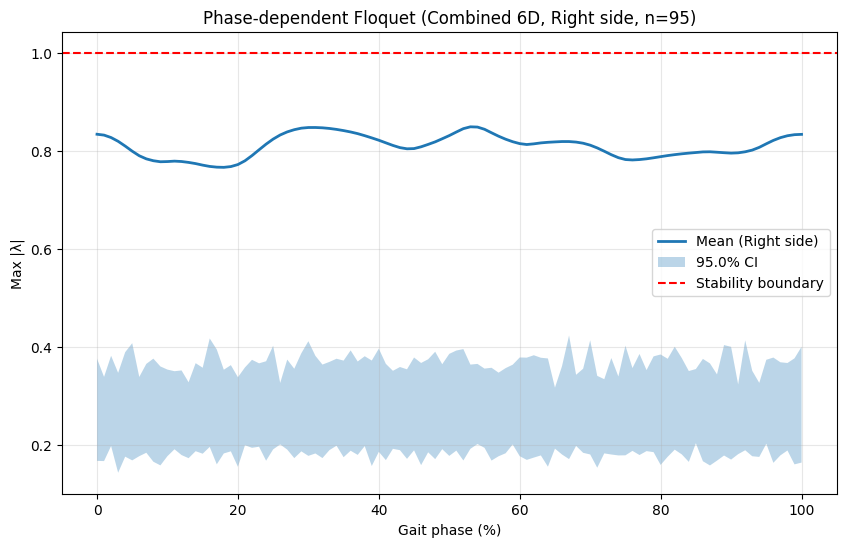

Most stable phase: 18% of gait cycle (λ = 0.7662)
Least stable phase: 53% of gait cycle (λ = 0.8489)

Running phase-dependent Floquet analysis...

Using Right-to-Right strides: 95 strides


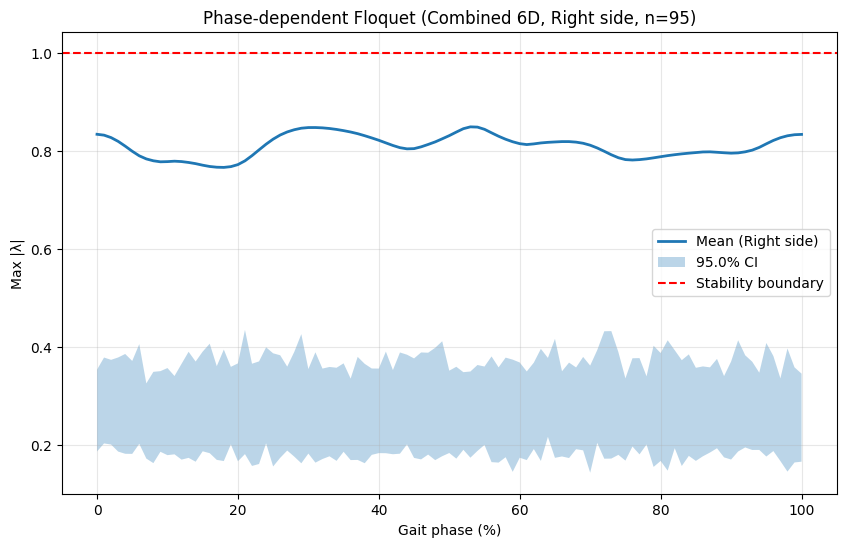

Most stable phase: 18% of gait cycle (λ = 0.7662)
Least stable phase: 53% of gait cycle (λ = 0.8489)

Phase-dependent analysis per axis...

Computing phase-dependent for Medio-lateral axis...
Using Right-to-Right strides: 95 strides


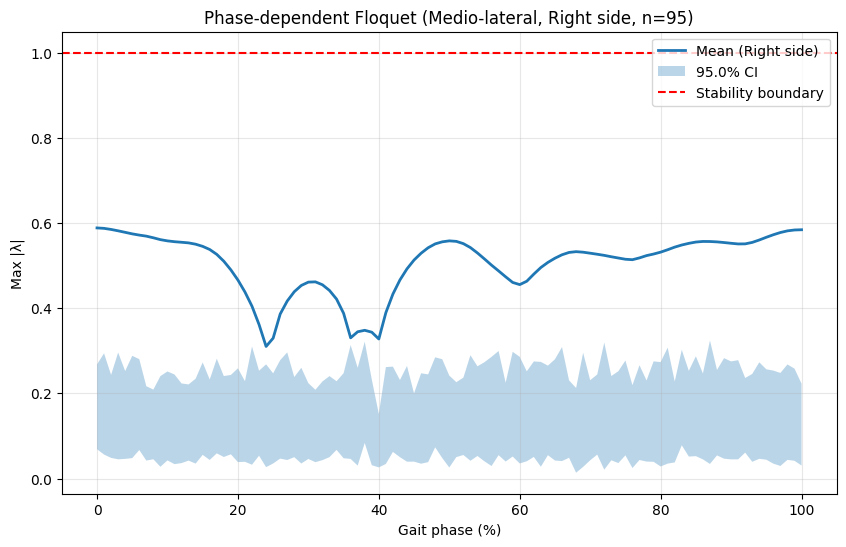

Computing phase-dependent for Anterior-posterior axis...
Using Right-to-Right strides: 95 strides


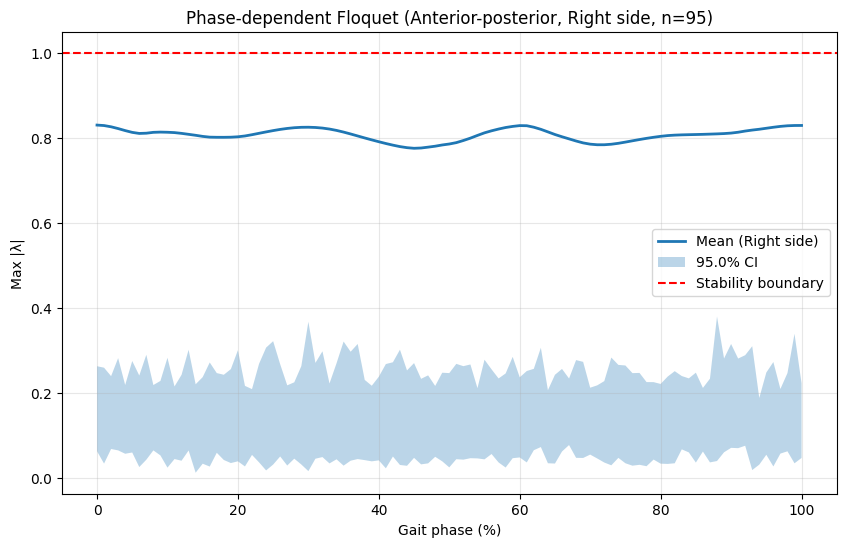

Computing phase-dependent for Vertical axis...
Using Right-to-Right strides: 95 strides


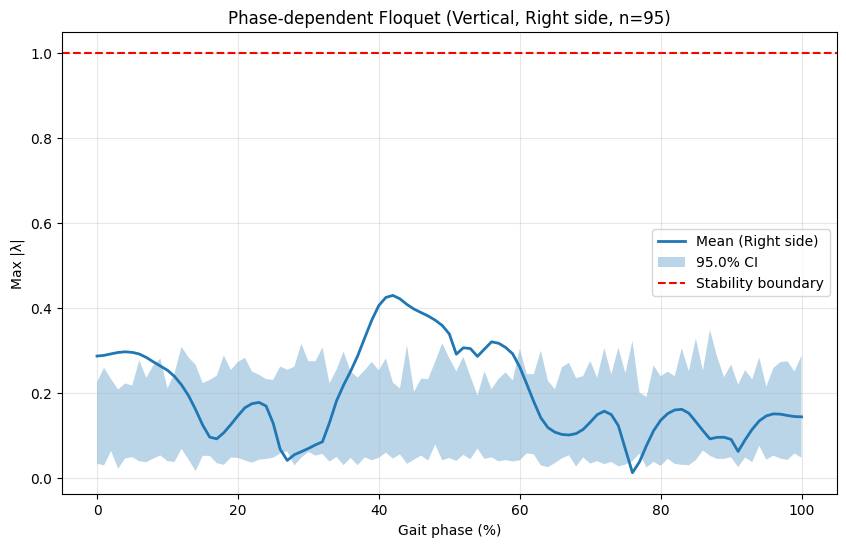

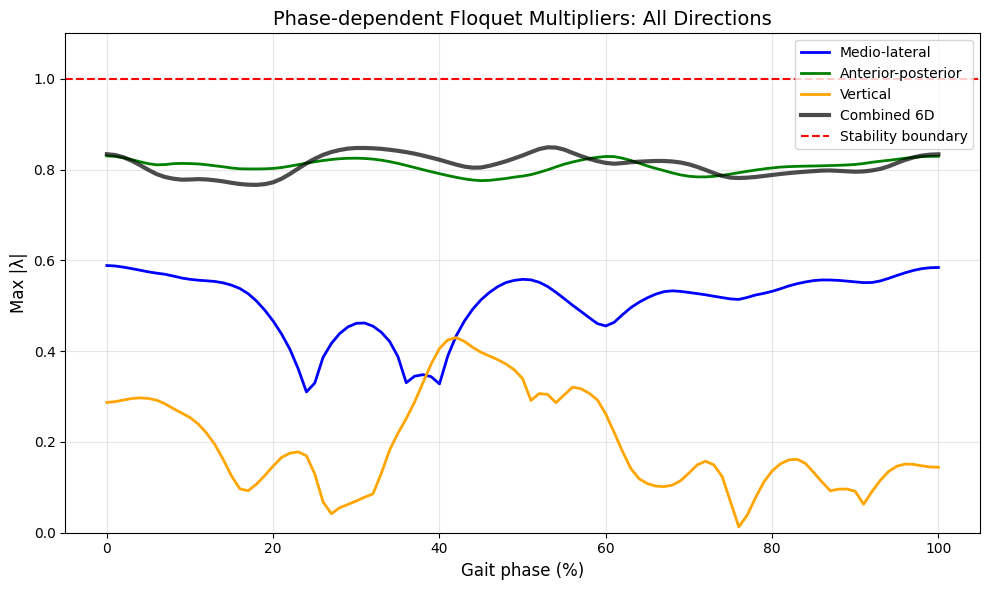


PHASE-SPECIFIC STABILITY SUMMARY
Heel strike (0%): λ = 0.8337
Loading response (10%): λ = 0.7780
Mid-stance (30%): λ = 0.8474
Terminal stance (50%): λ = 0.8310
Pre-swing (60%): λ = 0.8146
Initial swing (73%): λ = 0.7920
Mid-swing (87%): λ = 0.7980
Terminal swing (100%): λ = 0.8335

Extracting normalized trajectories for limit cycle analysis...

Extracting 95 Right-to-Right strides
Extracted data shape: 95 cycles x 101 time points x 3 axes

Plotting 2D limit cycle with dominant Floquet mode...


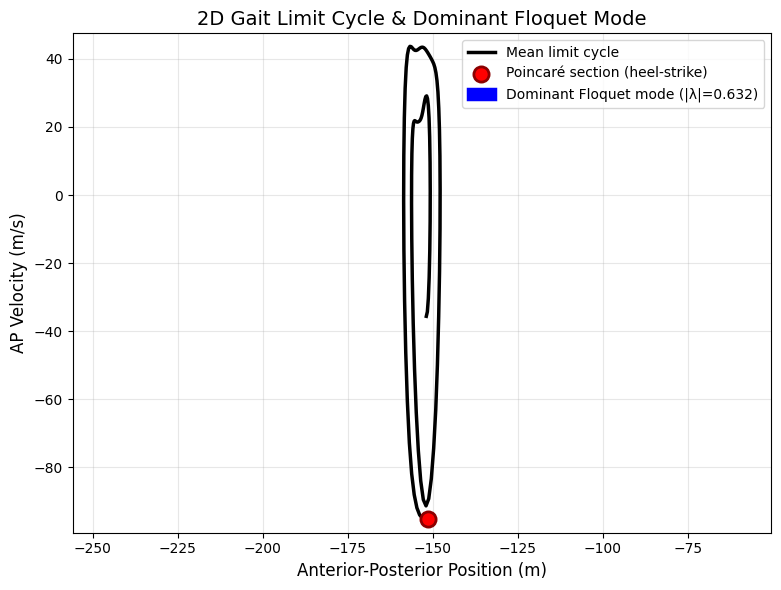


Limit Cycle Analysis:
- Dominant Floquet multiplier: |λ| = 0.6315
- Eigenvector direction in (y, ẏ): [0.063, -0.077]


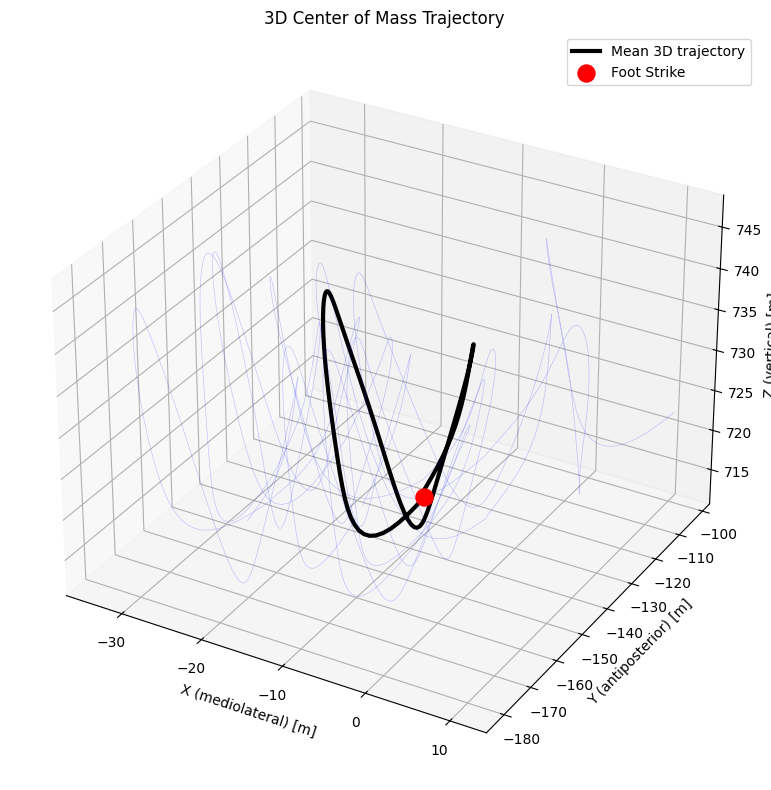

In [30]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.linalg import pinv, eig  # Add this import for plot_limit_cycle_2d

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events

def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # Load the data
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Elderly" / "09" /  "markers.nc"
    events_path = cwd.parent  / ".." / "data" / "PBT" / "Elderly" / "09" /  "events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "16" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "16" / "PWS" / "4" / "PWS.4_events.csv"

    ds = xr.open_dataset(data_path)
    df_all = pd.read_csv(events_path)

    fs = 100.0
    SKIP_SAMPLES = 1000
    skip_time = SKIP_SAMPLES / fs

    # Get foot strike events
    right_fs = df_all.query("context=='Right' and label=='Foot Strike' and time>=@skip_time")
    right_fs = right_fs.sort_values("time")
    N_STRIDES = len(right_fs)

    first_n = right_fs.iloc[:N_STRIDES]
    start_time, end_time = 160.0,first_n.time.iloc[-1]
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (all {N_STRIDES} R_FS)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 1) First, run a simple combined analysis to check everything works
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running combined 6D analysis first...")
    print("="*60)
    
    combined_result = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=['x', 'y', 'z'],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=100,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    print(f"\nCombined (6D): λ = {combined_result['max_floquet']:.4f} [{combined_result['confidence_interval'][0]:.4f}, {combined_result['confidence_interval'][1]:.4f}]")
    
    # ——————————————————————————————
    # 2) Now compute per-axis if you have the function defined
    # ——————————————————————————————
    if 'compute_floquet_per_axis' in globals():
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS")
        print("="*60)
        
        axis_results = compute_floquet_per_axis(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=False,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=100,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        # Display summary
        print("\n" + "="*60)
        print("FLOQUET STABILITY SUMMARY (RIGHT FOOT)")
        print("="*60)
        print(f"Medio-lateral (x):      λ = {axis_results['x']['max_floquet']:.4f} [{axis_results['x']['confidence_interval'][0]:.4f}, {axis_results['x']['confidence_interval'][1]:.4f}]")
        print(f"Anterior-posterior (y): λ = {axis_results['y']['max_floquet']:.4f} [{axis_results['y']['confidence_interval'][0]:.4f}, {axis_results['y']['confidence_interval'][1]:.4f}]")
        print(f"Vertical (z):           λ = {axis_results['z']['max_floquet']:.4f} [{axis_results['z']['confidence_interval'][0]:.4f}, {axis_results['z']['confidence_interval'][1]:.4f}]")
        print(f"Combined (6D):          λ = {axis_results['combined']['max_floquet']:.4f} [{axis_results['combined']['confidence_interval'][0]:.4f}, {axis_results['combined']['confidence_interval'][1]:.4f}]")
        
        # Identify most/least stable directions
        axis_values = {
            'Medio-lateral': axis_results['x']['max_floquet'],
            'Anterior-posterior': axis_results['y']['max_floquet'],
            'Vertical': axis_results['z']['max_floquet']
        }
        
        most_stable_axis = min(axis_values, key=axis_values.get)
        least_stable_axis = max(axis_values, key=axis_values.get)
        
        print(f"\nMost stable direction:  {most_stable_axis} (λ = {axis_values[most_stable_axis]:.4f})")
        print(f"Least stable direction: {least_stable_axis} (λ = {axis_values[least_stable_axis]:.4f})")
    else:
        # If compute_floquet_per_axis is not defined, compute each axis manually
        print("\n" + "="*60)
        print("ANALYZING STABILITY PER AXIS (Manual)")
        print("="*60)
        
        axis_results = {}
        
        # Compute for each axis
        for axis, name in [('x', 'Medio-lateral'), ('y', 'Anterior-posterior'), ('z', 'Vertical')]:
            print(f"\nAnalyzing {name} ({axis}) axis...")
            axis_result = compute_floquet_from_events(
                com_da=com_window,
                events_df=df_window,
                channel="COM",
                axes=[axis],  # Single axis only
                normalization_points=101,
                rcond=1e-6,
                phase_dependent=False,
                plot_spectrum=False,
                use_same_side=True,
                force_side='Right',
                trim_cycles=0,
                bootstrap_n=100,
                bootstrap_ci=95.0,
                lowpass_cutoff=8.0,
                min_cycles_required=150
            )
            axis_results[axis] = axis_result
            print(f"{name}: λ = {axis_result['max_floquet']:.4f} [{axis_result['confidence_interval'][0]:.4f}, {axis_result['confidence_interval'][1]:.4f}]")
        
        axis_results['combined'] = combined_result



    # ——————————————————————————————
    # 4) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,  # Enable phase-dependent
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,  # Fewer iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    # The function automatically plots, but let's also create a custom plot
    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']
    ci_low, ci_high = phase_results['confidence_interval']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 1) Phase-dependent Floquet analysis
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running phase-dependent Floquet analysis...")
    print("="*60 + "\n")

    # Phase-dependent for combined 6D
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,
        plot_spectrum=False,
        use_same_side=True,
        force_side='Right',
        trim_cycles=0,
        bootstrap_n=50,
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )

    phases = np.linspace(0, 100, 101)
    max_floquet_phases = phase_results['max_floquet']

    # Find most/least stable phases
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)

    print(f"Most stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 2) Phase-dependent for each axis separately
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Phase-dependent analysis per axis...")
    print("="*60 + "\n")
    
    axis_phase_results = {}
    
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        print(f"Computing phase-dependent for {name} axis...")
        
        phase_result = compute_floquet_from_events(
            com_da=com_window,
            events_df=df_window,
            channel="COM",
            axes=[axis],
            normalization_points=101,
            rcond=1e-6,
            phase_dependent=True,
            plot_spectrum=False,
            use_same_side=True,
            force_side='Right',
            trim_cycles=0,
            bootstrap_n=30,
            bootstrap_ci=95.0,
            lowpass_cutoff=8.0,
            min_cycles_required=150
        )
        
        axis_phase_results[axis] = phase_result

    # ——————————————————————————————
    # 3) Create comparison plot of all axes on one graph
    # ——————————————————————————————
    plt.figure(figsize=(10, 6))
    
    # Plot each axis
    colors = {'x': 'blue', 'y': 'green', 'z': 'orange'}
    for axis, name in [('x', 'Medio-lateral'), 
                       ('y', 'Anterior-posterior'), 
                       ('z', 'Vertical')]:
        plt.plot(phases, axis_phase_results[axis]['max_floquet'], 
                color=colors[axis], linewidth=2, label=name)
    
    # Add combined
    plt.plot(phases, phase_results['max_floquet'], 'k-', 
            linewidth=3, label='Combined 6D', alpha=0.7)
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
    plt.xlabel('Gait phase (%)', fontsize=12)
    plt.ylabel('Max |λ|', fontsize=12)
    plt.title('Phase-dependent Floquet Multipliers: All Directions', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    # ——————————————————————————————
    # 4) Print phase-specific statistics
    # ——————————————————————————————
    print("\n" + "="*60)
    print("PHASE-SPECIFIC STABILITY SUMMARY")
    print("="*60)
    
    # Typical gait events
    gait_events = {
        0: "Heel strike",
        10: "Loading response", 
        30: "Mid-stance",
        50: "Terminal stance",
        60: "Pre-swing",
        73: "Initial swing",
        87: "Mid-swing",
        100: "Terminal swing"
    }
    
    for phase, event in gait_events.items():
        if phase < len(phase_results['max_floquet']):
            print(f"{event} ({phase}%): λ = {phase_results['max_floquet'][phase]:.4f}")

        
    # ——————————————————————————————
    # 3) Extract data for limit cycle visualization
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Extracting normalized trajectories for limit cycle analysis...")
    print("="*60 + "\n")
    
    com_norm, vel_norm = extract_normalized_data_with_filter(
        com_window=com_window,
        df_window=df_window,
        use_same_side=True,
        side_used='Right',
        trim_cycles=0,
        lowpass_cutoff=8.0,
        normalization_points=101
    )
    
    print(f"Extracted data shape: {com_norm.shape[0]} cycles x {com_norm.shape[1]} time points x {com_norm.shape[2]} axes")
    
    # Plot the 2D limit cycle
    print("\nPlotting 2D limit cycle with dominant Floquet mode...")
    plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


    # ——————————————————————————————
    # 6) Additional 3D visualization (optional)
    # ——————————————————————————————
    if True:  # Set to False to skip 3D plot
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot mean 3D trajectory
        mean_pos = com_norm.mean(axis=0)
        ax.plot(mean_pos[:, 0], mean_pos[:, 1], mean_pos[:, 2], 
                'k-', lw=3, label='Mean 3D trajectory')
        
        # Mark heel-strike
        ax.scatter(mean_pos[0, 0], mean_pos[0, 1], mean_pos[0, 2], 
                  c='red', s=150, label='Foot Strike')
        
        # Plot a few individual cycles for variability visualization
        n_show = min(10, com_norm.shape[0])
        for i in range(n_show):
            ax.plot(com_norm[i, :, 0], com_norm[i, :, 1], com_norm[i, :, 2], 
                   'b-', alpha=0.2, lw=0.5)
        
        ax.set_xlabel('X (mediolateral) [m]')
        ax.set_ylabel('Y (antiposterior) [m]')
        ax.set_zlabel('Z (vertical) [m]')
        ax.set_title('3D Center of Mass Trajectory')
        ax.legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()